In [8]:
# Here are the libraries I utilised.
import itertools
import os
import random
import time
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import spearmanr
def md(text):
    display(Markdown(text))
from matplotlib.patches import Patch

In [9]:
md("""
# BI130 Project: The completed modules for 1 and 2. 
---
## Covering the Graph Centrality, Artist Prestige and Community Detection

The **Dataset:** we will utilise is the cleaned HetRec 2011 Last.fm 2K data produced by module 0 the preparartion stage.

This jupyter notebook completes:

### Module 1 - Graph Centrality and Prestige
1. Data loading and validation
2. User friendship graph construction
3. Artist co-listening graph construction
4. Basic graph analysis
5. User centrality analysis
6. Centrality ranking comparison
7. Artist prestige versus popularity
8. Results and interpretation
9. Exported tables and figures

### Module 2 - Community Detection and Profiling
1. Louvain community detection
2. Modularity and community-size analysis
3. Artist-based community profiles
4. Tag-based community profiles
5. Assessment of whether social communities align with musical taste

The notebook builds on the validated outputs from Module 0 rather than
reloading and cleaning the original source files again.

---

# Module 1 - Graph Centrality and Prestige

## 1. Data Loading and Validation

The following cells configure the project, load the cleaned datasets, and validate row counts, identifiers, missing or invalid references, duplicate records, duplicate friendship edges, and self-loops before graph construction begins.


""")


# BI130 Project: The completed modules for 1 and 2. 
---
## Covering the Graph Centrality, Artist Prestige and Community Detection

The **Dataset:** we will utilise is the cleaned HetRec 2011 Last.fm 2K data produced by module 0 the preparartion stage.

This jupyter notebook completes:

### Module 1 - Graph Centrality and Prestige
1. Data loading and validation
2. User friendship graph construction
3. Artist co-listening graph construction
4. Basic graph analysis
5. User centrality analysis
6. Centrality ranking comparison
7. Artist prestige versus popularity
8. Results and interpretation
9. Exported tables and figures

### Module 2 - Community Detection and Profiling
1. Louvain community detection
2. Modularity and community-size analysis
3. Artist-based community profiles
4. Tag-based community profiles
5. Assessment of whether social communities align with musical taste

The notebook builds on the validated outputs from Module 0 rather than
reloading and cleaning the original source files again.

---

# Module 1 - Graph Centrality and Prestige

## 1. Data Loading and Validation

The following cells configure the project, load the cleaned datasets, and validate row counts, identifiers, missing or invalid references, duplicate records, duplicate friendship edges, and self-loops before graph construction begins.




In [10]:
md("""The below prepares the folders, analysis limits, reliability rules, and display settings before any calculations are performed.""")

# Remember this is using the cleaned dataset contructed in the preparation notebook.
from pathlib import Path

script_dir = Path.cwd()
PROJECT_DIR = script_dir
CLEAN_DIR = PROJECT_DIR / "clean"
OUT_DIR = PROJECT_DIR / "outputs_m12"
OUT_DIR.mkdir(parents=True, exist_ok=True)
TOP_K = 15
TOP_N = 10
N_PROFILE = 5
RANDOM_SEED = 42

# The Community-profile support thresholds are below:
MIN_ARTIST_LISTENERS = 5
MIN_TAG_USERS = 5
EXACT_ARTIST_CLUSTERING = True
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

md(f"""
## Project configuration
- **Project folder:** `{PROJECT_DIR}`
- **Clean-data folder:** `{CLEAN_DIR}`
- **Output folder:** `{OUT_DIR}`
- **Random seed:** `{RANDOM_SEED}`
- **Top-k ranking size:** `{TOP_K}`
- **Communities to profile:** `{N_PROFILE}`
""")
# Yes we will only review the top 15 spots for now.

The below prepares the folders, analysis limits, reliability rules, and display settings before any calculations are performed.

/Users/areso/Documents/git/pers/bi130_coursework



## Project configuration
- **Project folder:** `/Users/areso/Documents/git/pers/bi130_coursework`
- **Clean-data folder:** `/Users/areso/Documents/git/pers/bi130_coursework/clean`
- **Output folder:** `/Users/areso/Documents/git/pers/bi130_coursework/outputs_m12`
- **Random seed:** `42`
- **Top-k ranking size:** `15`
- **Communities to profile:** `5`


In [11]:
# Lets load our cleaned Module 0 exports.
users = pd.read_csv(CLEAN_DIR / "users_clean.csv")
edges = pd.read_csv(CLEAN_DIR / "user_friends_undirected_clean.csv")
user_artists = pd.read_csv(CLEAN_DIR / "user_artists_clean.csv")
artists = pd.read_csv(CLEAN_DIR / "artists_clean.csv")
tags = pd.read_csv(CLEAN_DIR / "tags_clean.csv")
votes = pd.read_csv(
    CLEAN_DIR / "user_taggedartists_clean.csv",
    usecols=[
        "userID",
        "artistID",
        "canonical_key",
        "canonical_tag",
        "semantic_content_eligible",
    ],
).rename(columns={"semantic_content_eligible": "use_for_community_profile"})

artist_name = (artists.set_index("artistID")["source_name_repaired"].to_dict()) # This for when we lookup artist names later.

md("""
## Loading and validating the cleaned tables:

Now that the project directory has been defined, the cleaned tables produced by preparation Module 0 can be loaded and validated.

Remember Modules 1 and 2 use the **cleaned relational exports** rather than reading the original `.dat` files again.

This prevents the graph-analysis notebook from silently reintroducing:

- duplicate or merged artist IDs;
- doubled friendship rows;
- invalid user or artist references;
- duplicate user-artist interactions;
- noisy or unsuitable community-profile tags.

These issues we handled in Module 0 through reproducible cleaning
rules, validation checks and documented human judgement.
""")


# Lets make sure our imported sets didnt miss any rows or datapoints.

checks = pd.DataFrame([
    {"table": "users_clean.csv","actual_rows": len(users),"expected_rows": 1_892,},
    {"table": "user_friends_undirected_clean.csv","actual_rows": len(edges),"expected_rows": 12_717,},
    {"table": "user_artists_clean.csv","actual_rows": len(user_artists),"expected_rows": 92_829,},
    {"table": "artists_clean.csv","actual_rows": len(artists),"expected_rows": 17_619,},
    {"table": "tags_clean.csv","actual_rows": len(tags),"expected_rows": 9_297,},
    {"table": "user_taggedartists_clean.csv","actual_rows": len(votes),"expected_rows": 182_133,},])

checks["passed"] = (checks["actual_rows"]== checks["expected_rows"])
display(checks)

assert checks["passed"].all(), ("At least one Module 0 export does not match the expected row count.")

# Here we ensure to validate.... 

# Key identifiers.
assert users["userID"].is_unique, ("Duplicate user IDs were found.")
assert artists["artistID"].is_unique, ("Duplicate cleaned artist IDs were found.")

# Here we walidate the undirected friendship table.
assert not edges.duplicated(["userID_a", "userID_b"]).any(), ("Duplicate friendship edges were found.")
assert (edges["userID_a"] < edges["userID_b"]).all(), ("Friendship endpoints are not stored in canonical order.")
assert not (edges["userID_a"] == edges["userID_b"]).any(), ("Friendship self-loops were found.")

# User-artist interaction.
assert not user_artists.duplicated(["userID", "artistID"]).any(), ("Duplicate user-artist interactions were found.")
assert (user_artists["weight"] > 0).all(), ("Non-positive listening weights were found.")
assert int(user_artists["weight"].sum()) == 69_183_975, ("The total listening weight was not preserved.")

# Cleaned tag-vote table.
assert not votes.duplicated(["userID","artistID","canonical_key",]).any(), ("Duplicate cleaned tag votes were found.")
assert votes["use_for_community_profile"].notna().all(), ("Some tag votes do not have a completed community-profile decision.")

# Referential integrity.
clean_user_ids = set(users["userID"])
clean_artist_ids = set(artists["artistID"])
assert set(user_artists["userID"]).issubset(clean_user_ids), ("The interaction table contains unknown user IDs.")
assert set(user_artists["artistID"]).issubset(clean_artist_ids), ("The interaction table contains unknown artist IDs.")
assert set(edges["userID_a"]).issubset(clean_user_ids), ("The friendship table contains unknown user IDs.")
assert set(edges["userID_b"]).issubset(clean_user_ids), ("The friendship table contains unknown friend IDs.")
assert set(votes["userID"]).issubset(clean_user_ids), ("The tag-vote table contains unknown user IDs.")
assert set(votes["artistID"]).issubset(clean_artist_ids), ("The tag-vote table contains unknown artist IDs.")

#Summary Table.
validation_summary = pd.DataFrame([
    {"check": "Expected row counts", "passed": checks["passed"].all(),},
    {"check": "User IDs are unique", "passed": users["userID"].is_unique,},
    {"check": "Artist IDs are unique","passed": artists["artistID"].is_unique,},
    {"check": "Friendship edges are unique","passed": not edges.duplicated( ["userID_a", "userID_b"]).any(),},
    {"check": "Friendship endpoints are ordered","passed": (edges["userID_a"]< edges["userID_b"]).all(),},
    {"check": "No friendship self-loops","passed": not (edges["userID_a"]== edges["userID_b"]).any(),},
    {"check": "User-artist pairs are unique","passed": not user_artists.duplicated(["userID", "artistID"]).any(),},
    {"check": "Listening weights are positive","passed": (user_artists["weight"] > 0).all(),},
    {"check": "Total listening weight preserved", "passed": int(user_artists["weight"].sum()) == 69_183_975,},
    {"check": "Cleaned tag votes are unique","passed": not votes.duplicated(["userID","artistID","canonical_key",]).any(),},
    {"check": "Community-profile flags are complete","passed": votes["use_for_community_profile"].notna().all(),},
    {"check": "All user and artist references resolve","passed": True,},])

display(validation_summary)
assert validation_summary["passed"].all(), ("At least one Module 0 handoff validation failed.")

md(f"""
### Module 0 handoff validation passed

The cleaned tables contain:

- **Users:** {len(users):,}
- **Cleaned artists:** {len(artists):,}
- **User-artist interactions:** {len(user_artists):,}
- **Unique undirected friendships:** {len(edges):,}
- **Canonical tags:** {len(tags):,}
- **Cleaned tag votes:** {len(votes):,}
- **Total listening weight:** {int(user_artists["weight"].sum()):,}

The friendship table contains **{len(edges):,} unique undirected
relationships**.

You can find the original source contains **25,434 directional rows** because each
of the **12,717 friendships** was represented in both directions.

All row-count, uniqueness, referential-integrity and
community-profile eligibility checks passed.

We can now begin with Module 1.

---
""") # If you wish to verify the 25434 it is listed within the offical readme of the dataset.

FileNotFoundError: [Errno 2] No such file or directory: '/Users/areso/Documents/git/pers/bi130_coursework/clean/users_clean.csv'

In [ ]:
md("""
## `Module 1` examines two separate graph structures:

### - User friendship graph

- **Node:** one Last.fm user
- **Edge:** one friendship
- **Direction:** undirected
- **Edge weight:** none

### - Artist co-listener graph

- **Node:** one artist
- **Edge:** two artists share at least one listener
- **Edge weight:** number of distinct users who listened to both artists

The artist graph is a projection of the user-artist interaction data.
Please note this is not itself the social friendship graph!
""")


## `Module 1` examines two separate graph structures:

### - User friendship graph

- **Node:** one Last.fm user
- **Edge:** one friendship
- **Direction:** undirected
- **Edge weight:** none

### - Artist co-listener graph

- **Node:** one artist
- **Edge:** two artists share at least one listener
- **Edge weight:** number of distinct users who listened to both artists

The artist graph is a projection of the user-artist interaction data.
Please note this is not itself the social friendship graph!


In [ ]:
md("""
## 2. User Friendship Graph Construction

This graph contains:

- one node for every cleaned Last.fm user;
- one undirected edge for every friendship;
- no friendship weights;
- no duplicate directional relationships.

All users are added before the friendship edges. This ensures that isolated users with no recorded friendships are still retained as a 
node rather than disappearing from the graph entirely.
""")


## 2. User Friendship Graph Construction

This graph contains:

- one node for every cleaned Last.fm user;
- one undirected edge for every friendship;
- no friendship weights;
- no duplicate directional relationships.

All users are added before the friendship edges. This ensures that isolated users with no recorded friendships are still retained as a 
node rather than disappearing from the graph entirely.


In [ ]:
G_user = nx.Graph()
G_user.add_nodes_from(users["userID"].tolist())
G_user.add_edges_from(edges[["userID_a", "userID_b"]].itertuples(index=False,name=None,))

# Lets validate it just incase. (To prevent any error in these initial steps.)
assert isinstance(G_user,nx.Graph,), ("G_user was not created as a NetworkX graph.")
assert not G_user.is_directed(), ("The friendship graph should be undirected.")
assert G_user.number_of_nodes() == 1_892, ("Unexpected user-node count.")
assert G_user.number_of_edges() == 12_717, ("Unexpected friendship-edge count.")
assert nx.number_of_selfloops(G_user) == 0, ("The friendship graph should not contain self-loops.")
assert set(users["userID"]) == set(G_user.nodes()), ("The graph does not contain exactly the cleaned user population.")
assert all(G_user.has_edge(user_a,user_b,)for user_a, user_b in edges[["userID_a", "userID_b"]].itertuples(index=False,name=None,)), ("At least one cleaned friendship edge is missing from the graph.")

In [ ]:
# Visualise the Graph through text.
isolated_user_count = len(list(nx.isolates(G_user)))

md(f"""
### User friendship graph constructed successfully

- **Graph type:** undirected
- **User nodes:** {G_user.number_of_nodes():,}
- **Friendship edges:** {G_user.number_of_edges():,}
- **Self-loops:** {nx.number_of_selfloops(G_user):,}
- **Users with no friendship edges:** {isolated_user_count:,}

Each edge represents one friendship rather than one directional row
from the original source file.

Our graph variable `G_user` is now ready for the later centrality,
component and community-detection calculations. Without worry!
""")


### User friendship graph constructed successfully

- **Graph type:** undirected
- **User nodes:** 1,892
- **Friendship edges:** 12,717
- **Self-loops:** 0
- **Users with no friendship edges:** 0

Each edge represents one friendship rather than one directional row
from the original source file.

Our graph variable `G_user` is now ready for the later centrality,
component and community-detection calculations. Without worry!



### Additional visual representation for the User friendship network.

The complete friendship graph contains 1,892 users and 12,717 edges,
so a readable sample is displayed instead.

In this figure:
- node size represents the number of direct friendships;
- each of the top 10 highest-degree users has a different colour;
- all other sampled users are shown in light grey;
- only the top 10 users are labelled;
- labels use anonymised user IDs because the dataset does not provide
  real user names.

This is an explanatory visual and does not replace the required
degree-distribution plot later in Module 1.


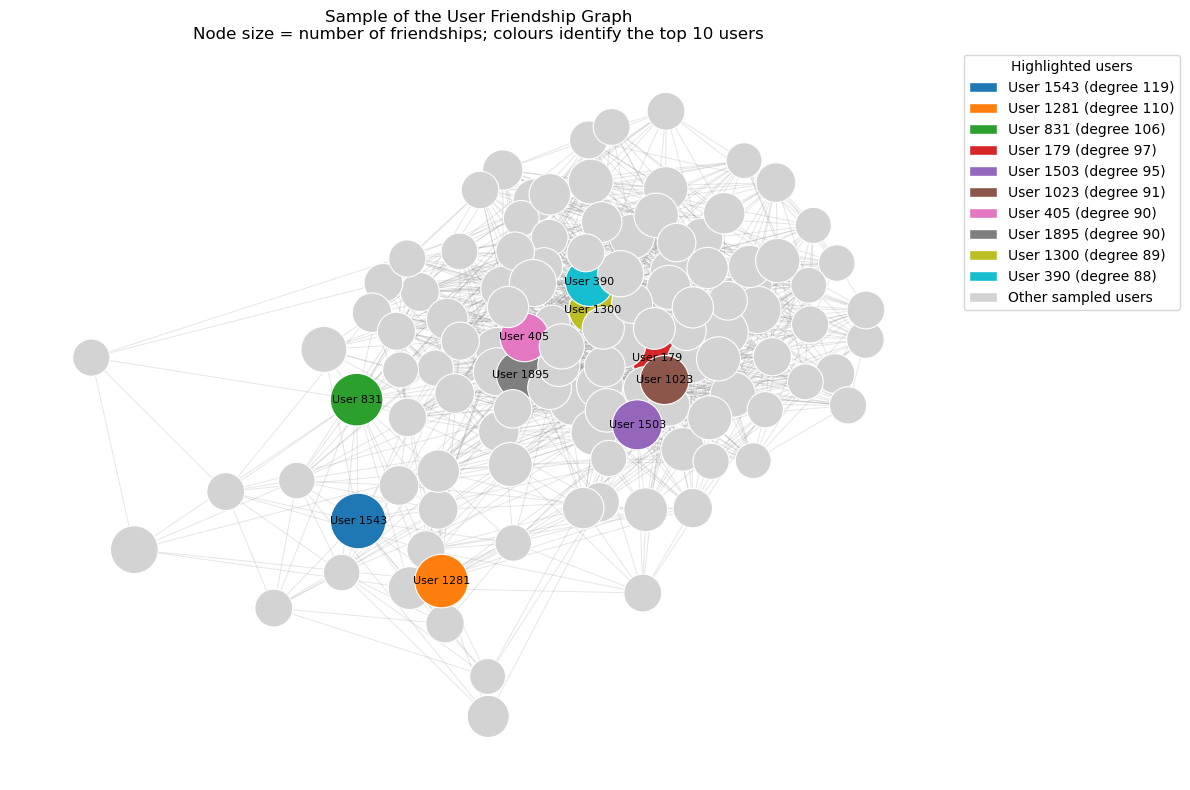


#### A visualised network sample

- **Displayed users:** 120
- **Displayed friendship edges:** 1,407
- **Highlighted users:** User 1543, User 1281, User 831, User 179, User 1503, User 1023, User 405, User 1895, User 1300, User 390

Each highlighted user has a unique colour, and the legend reports their
user ID and degree.


In [ ]:
md("""
### Additional visual representation for the User friendship network.

The complete friendship graph contains 1,892 users and 12,717 edges,
so a readable sample is displayed instead.

In this figure:
- node size represents the number of direct friendships;
- each of the top 10 highest-degree users has a different colour;
- all other sampled users are shown in light grey;
- only the top 10 users are labelled;
- labels use anonymised user IDs because the dataset does not provide
  real user names.

This is an explanatory visual and does not replace the required
degree-distribution plot later in Module 1.
""")

user_degree = dict(G_user.degree())
top10_degree_users = sorted(G_user.nodes(),
    key=lambda user_id: user_degree[user_id],
    reverse=True,)[:10]

sample_user_nodes = set(top10_degree_users)
for user_id in top10_degree_users:
    sample_user_nodes.update(
        G_user.neighbors(user_id))

sample_user_nodes = sorted(sample_user_nodes,
    key=lambda user_id: user_degree[user_id],
    reverse=True,)[:120] #VERY important unless you have a powerful PC, think ofthis as a limiter.

G_user_sample = G_user.subgraph(sample_user_nodes).copy()

sample_degree_values = np.array([user_degree[user_id]for user_id in G_user_sample.nodes()])
sample_node_sizes = (100 + 1_500 * (sample_degree_values / sample_degree_values.max() ))


# Lets colour the top ten differently.
top10_colour_values = plt.cm.tab10(np.linspace(0,1,len(top10_degree_users)))
top10_colour_map = {
    user_id: colour
    for user_id, colour in zip(
        top10_degree_users,
        top10_colour_values)}


# The others will remain grey so as to not clutter the chart.
sample_node_colours = [top10_colour_map[user_id]
    if user_id in top10_colour_map
    else "lightgrey"
    for user_id in G_user_sample.nodes()]

sample_labels = {user_id: f"User {user_id}"
    for user_id in top10_degree_users}


# Now the Seed so we can reproduce this result.
sample_positions = nx.spring_layout( G_user_sample, seed=RANDOM_SEED, k=0.45,)
fig, ax = plt.subplots(figsize=(12, 8))

# Depicting the edges.
nx.draw_networkx_edges(
    G_user_sample,
    sample_positions,
    ax=ax,
    edge_color="grey",
    width=0.7,
    alpha=0.20,)

# Depicting the nodes.
nx.draw_networkx_nodes(
    G_user_sample,
    sample_positions,
    ax=ax,
    node_size=sample_node_sizes,
    node_color=sample_node_colours,
    edgecolors="white",
    linewidths=0.8,)


# Label only the top 10 users.
nx.draw_networkx_labels(
    G_user_sample,
    sample_positions,
    ax=ax,
    labels=sample_labels,
    font_size=8,)

# Create a legend matching each colour to its anonymised user ID (Remember User Names arent given so we need to assign them.).
legend_handles = [Patch(
        facecolor=top10_colour_map[user_id],
        edgecolor="white",
        label=(
            f"User {user_id} "
            f"(degree {user_degree[user_id]})"),)
    for user_id in top10_degree_users]

legend_handles.append(Patch(facecolor="lightgrey", edgecolor="white", label="Other sampled users",))
ax.legend(handles=legend_handles,title="Highlighted users",loc="upper left",bbox_to_anchor=(1.01, 1),)
ax.set_title("Sample of the User Friendship Graph\n""Node size = number of friendships; colours identify the top 10 users")
ax.axis("off")

fig.tight_layout()

fig.savefig(OUT_DIR / "user_friendship_network_top10_coloured.png",dpi=160,bbox_inches="tight",)
plt.show()

md(f"""
#### A visualised network sample

- **Displayed users:** {G_user_sample.number_of_nodes():,}
- **Displayed friendship edges:** {G_user_sample.number_of_edges():,}
- **Highlighted users:** {", ".join(f"User {user_id}" for user_id in top10_degree_users)}

Each highlighted user has a unique colour, and the legend reports their
user ID and degree.
""")

In [ ]:
md("""
## 3. Artist Co-Listening Graph Construction

The second graph required by Module 1 is derived from the cleaned user-artist listening records.

The graph contains:

- one node for every cleaned artist;
- one undirected edge when at least one user listened to both artists;
- an edge weight equal to the number of distinct users who listened
  to both artists.

This graph represents co-listening relationships. It is not the user
friendship graph.
""")


## 3. Artist Co-Listening Graph Construction

The second graph required by Module 1 is derived from the cleaned user-artist listening records.

The graph contains:

- one node for every cleaned artist;
- one undirected edge when at least one user listened to both artists;
- an edge weight equal to the number of distinct users who listened
  to both artists.

This graph represents co-listening relationships. It is not the user
friendship graph.


In [ ]:
# Count how many distinct users listened to each pair of artists.
artist_pair_counts = Counter()
construction_start = time.time()
for user_id, artist_ids in user_artists.groupby("userID")["artistID"]:
    unique_artist_ids = sorted(artist_ids.unique()) # We have uniques and not duplicates!
    for artist_a, artist_b in itertools.combinations(unique_artist_ids,2,):artist_pair_counts[(artist_a, artist_b)] += 1 #Time to add the weightages
pair_count_seconds = (time.time() - construction_start)

md(f"""
### Shared-listener pairs generated

- **Unique artist pairs:** {len(artist_pair_counts):,}
- **Pair-generation time:** {pair_count_seconds:.1f} seconds

Each dictionary value now records the number of distinct users who
listened to both artists in that pair.
""")


### Shared-listener pairs generated

- **Unique artist pairs:** 1,319,800
- **Pair-generation time:** 1.6 seconds

Each dictionary value now records the number of distinct users who
listened to both artists in that pair.


In [ ]:
G_art = nx.Graph()
G_art.add_nodes_from(artists["artistID"].tolist())
G_art.add_weighted_edges_from(
    (artist_a,artist_b,shared_listener_count,)
    for (artist_a,artist_b,), shared_listener_count
    in artist_pair_counts.items()
) # If this works we now must validate the results.

# Confirming that G_art is an undirected NetworkX graph!
assert isinstance(G_art,nx.Graph,), ("G_art was not created as a NetworkX graph.")
assert not G_art.is_directed(), ("The artist graph should be undirected.")
assert G_art.number_of_nodes() == 17_619, ("Unexpected artist-node count.")
assert G_art.number_of_edges() == 1_319_800, ("Unexpected artist-edge count.")
assert set(G_art.nodes()) == set(artists["artistID"]), ("The artist graph does not contain exactly the cleaned artist IDs.")
assert nx.number_of_selfloops( G_art) == 0, ("The artist graph should not contain self-loops.")
assert all(isinstance(edge_data["weight"], (int, np.integer))and edge_data["weight"] > 0 for _, _, edge_data in G_art.edges(data=True)), ("At least one artist edge has an invalid shared-listener weight.")
assert len(artist_pair_counts) == G_art.number_of_edges(), ("The pair-count table and artist graph have different edge counts.")

In [ ]:
# Visualise the Graph through text.
isolated_artist_count = nx.number_of_isolates(G_art)
artist_graph_validation = pd.DataFrame([
    {"check": "Graph is undirected","result": not G_art.is_directed(),"expected": True,"passed": not G_art.is_directed(),},
    {"check": "Artist-node count","result": G_art.number_of_nodes(),"expected": 17_619,"passed": G_art.number_of_nodes() == 17_619,},
    {"check": "Co-listener edge count","result": G_art.number_of_edges(),"expected": 1_319_800,"passed": G_art.number_of_edges() == 1_319_800,},
    {"check": "Self-loop count","result": nx.number_of_selfloops(G_art),"expected": 0,"passed": nx.number_of_selfloops(G_art) == 0,},
    {"check": "All cleaned artists retained","result": len(set(G_art.nodes()) & set(artists["artistID"])),
        "expected": 17_619,"passed": set( G_art.nodes() ) == set(artists["artistID"]),},
    {"check": "All edge weights are positive","result": all(edge_data["weight"] > 0
for _, _, edge_data in G_art.edges(data=True)),
        "expected": True,"passed": all(edge_data["weight"] > 0 for _, _, edge_data in G_art.edges(data=True)),},
])

display(artist_graph_validation)

assert artist_graph_validation["passed"].all(), ("At least one artist-graph construction check failed.")

,check,result,expected,passed
0,Graph is undirected,True,True,True
1,Artist-node count,17619,17619,True
2,Co-listener edge count,1319800,1319800,True
3,Self-loop count,0,0,True
4,All cleaned artists retained,17619,17619,True
5,All edge weights are positive,True,True,True


In [ ]:
md(f"""
### Artist co-listener graph constructed successfully

- **Graph type:** undirected and weighted
- **Artist nodes:** {G_art.number_of_nodes():,}
- **Co-listener edges:** {G_art.number_of_edges():,}
- **Self-loops:** {nx.number_of_selfloops(G_art):,}
- **Isolated artist nodes:** {isolated_artist_count:,}

Each edge weight represents the number of distinct users who listened
to both connected artists.

We now have the graph variable `G_art` ready for the later component,
clustering, degree-distribution and weighted PageRank analyses.
""")


### Artist co-listener graph constructed successfully

- **Graph type:** undirected and weighted
- **Artist nodes:** 17,619
- **Co-listener edges:** 1,319,800
- **Self-loops:** 0
- **Isolated artist nodes:** 6

Each edge weight represents the number of distinct users who listened
to both connected artists.

We now have the graph variable `G_art` ready for the later component,
clustering, degree-distribution and weighted PageRank analyses.


In [ ]:
strongest_artist_edges = pd.DataFrame(
    [{"artistID_a": artist_a,"artist_a": artist_name.get(artist_a,f"Artist {artist_a}",),"artistID_b": artist_b,"artist_b": artist_name.get(artist_b,
                f"Artist {artist_b}",),"shared_listeners": edge_data["weight"],}
        for artist_a, artist_b, edge_data
        in G_art.edges(data=True)])

strongest_artist_edges = (strongest_artist_edges.sort_values(
        ["shared_listeners","artistID_a","artistID_b",],ascending=[False,True,True,],).head(10).reset_index(drop=True))

display(strongest_artist_edges)

md("""
For analysing sakes, we constructed a table that shows the artist pairs with the largest number of shared listeners.

This is a construction check rather than the final artist-prestige analysis. 
For a high shared-listener weight does not automatically mean that an artist will receive the highest PageRank.

---
""")

,artistID_a,artist_a,artistID_b,artist_b,shared_listeners
0,89,Lady Gaga,289,Britney Spears,436
1,89,Lady Gaga,288,Rihanna,414
2,288,Rihanna,289,Britney Spears,413
3,89,Lady Gaga,300,Katy Perry,396
4,289,Britney Spears,300,Katy Perry,380
5,289,Britney Spears,292,Christina Aguilera,360
6,288,Rihanna,300,Katy Perry,358
7,288,Rihanna,292,Christina Aguilera,350
8,288,Rihanna,295,Beyoncé,348
9,89,Lady Gaga,292,Christina Aguilera,345



For analysing sakes, we constructed a table that shows the artist pairs with the largest number of shared listeners.

This is a construction check rather than the final artist-prestige analysis. 
For a high shared-listener weight does not automatically mean that an artist will receive the highest PageRank.

---


In [ ]:
md("""
## 4. Basic Graph Analysis

Here is where we will build the basic report for both the user friendship graph and the artist co-listener graph.

Each of the graphs will tackle the:

- number of nodes;
- number of edges;
- number of connected components;
- size of the largest connected component;
- number of isolated nodes;
- average clustering coefficient;
- degree distribution.

### Now we define whats a `connected component`?

A connected component is a group of nodes that can reach one another
through the graph. Of which the largest connected component is identified as **giant component**.

### Average clustering coefficient?

The clustering coefficient measures how often a node's neighbours are
also connected to one another.

- A  **0** value indicates limited interconnection among neighbours.
- A value near **1** indicates that neighbours form highly connected groups.

### 4.1 User Friendship Graph Summary

The shared graph-report calculation below produces the existing descriptive statistics for both graphs. The user friendship results are reported first.

""")


## 4. Basic Graph Analysis

Here is where we will build the basic report for both the user friendship graph and the artist co-listener graph.

Each of the graphs will tackle the:

- number of nodes;
- number of edges;
- number of connected components;
- size of the largest connected component;
- number of isolated nodes;
- average clustering coefficient;
- degree distribution.

### Now we define whats a `connected component`?

A connected component is a group of nodes that can reach one another
through the graph. Of which the largest connected component is identified as **giant component**.

### Average clustering coefficient?

The clustering coefficient measures how often a node's neighbours are
also connected to one another.

- A  **0** value indicates limited interconnection among neighbours.
- A value near **1** indicates that neighbours form highly connected groups.

### 4.1 User Friendship Graph Summary

The shared graph-report calculation below produces the existing descriptive statistics for both graphs. The user friendship results are reported first.



In [ ]:
#Lets test this on a sample method first.
EXACT_ARTIST_CLUSTERING = True # If we change this as false, it will be an estimate only!
ARTIST_CLUSTERING_TRIALS = 5_000

def calculate_graph_report(graph, graph_name, exact_clustering=True,):
    """Calculate the basic statistics required by the assignment."""
    
    component_sizes = sorted(
        (len(component) for component in nx.connected_components(graph)),
        reverse=True,
    )

    clustering_start = time.time()

    if exact_clustering:
        average_clustering = nx.average_clustering(
            graph,
            weight=None,
        )
        clustering_method = "Exact, unweighted"

    else:
        average_clustering = (
            nx.algorithms.approximation.average_clustering(
                graph,
                trials=ARTIST_CLUSTERING_TRIALS,
                seed=RANDOM_SEED,
            )
        )
        clustering_method = (
            f"Estimated, {ARTIST_CLUSTERING_TRIALS:,} trials"
        )

    clustering_runtime = (time.time() - clustering_start)

    return {
        "graph": graph_name,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "connected_components": len(component_sizes),
        "giant_component_size": component_sizes[0],
        "isolated_nodes": nx.number_of_isolates(graph),
        "average_clustering": average_clustering,
        "clustering_method": clustering_method,
        "runtime_seconds": clustering_runtime,
    }


user_graph_report = calculate_graph_report(G_user,"User friendship graph",exact_clustering=True,)
artist_graph_report = calculate_graph_report(G_art, "Artist co-listener graph", exact_clustering=EXACT_ARTIST_CLUSTERING,)
graph_report = pd.DataFrame([user_graph_report, artist_graph_report,])


# Here is how we display the results:
graph_report_display = graph_report.copy()
graph_report_display["average_clustering"] = (graph_report_display["average_clustering"].round(4))
graph_report_display["runtime_seconds"] = (graph_report_display["runtime_seconds"].round(2))
display(graph_report_display)

# Unless we wish to export the results
graph_report.to_csv(
    OUT_DIR / "graph_basic_report.csv",
    index=False,
)

,graph,nodes,edges,connected_components,giant_component_size,isolated_nodes,average_clustering,clustering_method,runtime_seconds
0,User friendship graph,1892,12717,20,1843,0,0.1865,"Exact, unweighted",0.13
1,Artist co-listener graph,17619,1319800,8,17609,6,0.7950,"Exact, unweighted",190.15


In [ ]:
md("""
### 4.3 Artist Co-Listening Graph Summary

The same existing graph-report output also contains the artist co-listening graph statistics. 
The validation and written summaries below preserve both sets of results.

Now we validate that we used complete data.
""")
assert user_graph_report["nodes"] == 1_892
assert user_graph_report["edges"] == 12_717
assert user_graph_report["connected_components"] == 20
assert user_graph_report["giant_component_size"] == 1_843
assert user_graph_report["isolated_nodes"] == 0
assert artist_graph_report["nodes"] == 17_619
assert artist_graph_report["edges"] == 1_319_800
assert artist_graph_report["connected_components"] == 8
assert artist_graph_report["giant_component_size"] == 17_609
assert artist_graph_report["isolated_nodes"] == 6
assert 0 <= user_graph_report["average_clustering"] <= 1
assert 0 <= artist_graph_report["average_clustering"] <= 1


md(f"""
### Basic graph statistics validated

#### User friendship graph

- **Nodes:** {user_graph_report["nodes"]:,}
- **Edges:** {user_graph_report["edges"]:,}
- **Connected components:** {user_graph_report["connected_components"]:,}
- **Giant component:** {user_graph_report["giant_component_size"]:,}
- **Isolated users:** {user_graph_report["isolated_nodes"]:,}
- **Average clustering:** {user_graph_report["average_clustering"]:.4f}
- **Method:** {user_graph_report["clustering_method"]}

#### Artist co-listener graph

- **Nodes:** {artist_graph_report["nodes"]:,}
- **Edges:** {artist_graph_report["edges"]:,}
- **Connected components:** {artist_graph_report["connected_components"]:,}
- **Giant component:** {artist_graph_report["giant_component_size"]:,}
- **Isolated artists:** {artist_graph_report["isolated_nodes"]:,}
- **Average clustering:** {artist_graph_report["average_clustering"]:.4f}
- **Method:** {artist_graph_report["clustering_method"]}

The user graph contains no isolated users. Although it has 20 connected
components, every user has at least one friendship connection.

The artist graph contains six isolated artists and has a substantially
higher clustering coefficient. This high artist clustering must later
be interpreted partly as a consequence of the co-listener projection.

---
""")


### 4.3 Artist Co-Listening Graph Summary

The same existing graph-report output also contains the artist co-listening graph statistics. 
The validation and written summaries below preserve both sets of results.

Now we validate that we used complete data.



### Basic graph statistics validated

#### User friendship graph

- **Nodes:** 1,892
- **Edges:** 12,717
- **Connected components:** 20
- **Giant component:** 1,843
- **Isolated users:** 0
- **Average clustering:** 0.1865
- **Method:** Exact, unweighted

#### Artist co-listener graph

- **Nodes:** 17,619
- **Edges:** 1,319,800
- **Connected components:** 8
- **Giant component:** 17,609
- **Isolated artists:** 6
- **Average clustering:** 0.7950
- **Method:** Exact, unweighted

The user graph contains no isolated users. Although it has 20 connected
components, every user has at least one friendship connection.

The artist graph contains six isolated artists and has a substantially
higher clustering coefficient. This high artist clustering must later
be interpreted partly as a consequence of the co-listener projection.

---


In [ ]:
 #"""Here we calculate how many nodes have each degree, and what fraction they represent in the complete graph."""
def calculate_degree_distribution(graph,):
    degrees = pd.Series([degree for _, degree in graph.degree()],name="degree", dtype="int64",)
    degree_counts = (degrees.value_counts().sort_index())
    degree_fractions = (degree_counts / graph.number_of_nodes())
    return pd.DataFrame({
        "degree": degree_counts.index,
        "node_count": degree_counts.values,
        "node_fraction": degree_fractions.values,})

  #"""Using logarithmic axes to plot the positive-degree distribution"""
def plot_degree_distribution(graph, title, x_axis_label, node_label, filename,):
    distribution = calculate_degree_distribution(graph,)
    positive_distribution = distribution.loc[distribution["degree"] > 0].copy()

    isolated_count = nx.number_of_isolates(graph,)

    fig, ax = plt.subplots(figsize=(9, 6),)
    ax.scatter(positive_distribution["degree"], positive_distribution["node_fraction"], s=18, alpha=0.70, c = "orange")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title,)
    ax.set_xlabel(x_axis_label,)
    ax.set_ylabel( f"Fraction of {node_label}\n""(proportion having that degree)")
    ax.grid(True, which="both", alpha=0.30,)
    ax.text(0.98, 0.95,(f"Degree-zero {node_label} excluded " f"from log plot: {isolated_count:,}"),
        transform=ax.transAxes,
        horizontalalignment="right",
        verticalalignment="top",)

    fig.tight_layout()
    fig.savefig(
        OUT_DIR / filename,
        dpi=160,
        bbox_inches="tight",)
    plt.show()

    return distribution


### 4.2 User Friendship Graph Degree Distribution

The degree of a user is the number of direct friendship connections that user has.

The plot below shows us:
- **x-axis:** number of direct friendships;
- **y-axis:** fraction of users having that number of friendships.

Do Note that both axes use logarithmic scales so that common low-degree users and rare high-degree users can be shown in the same figure.


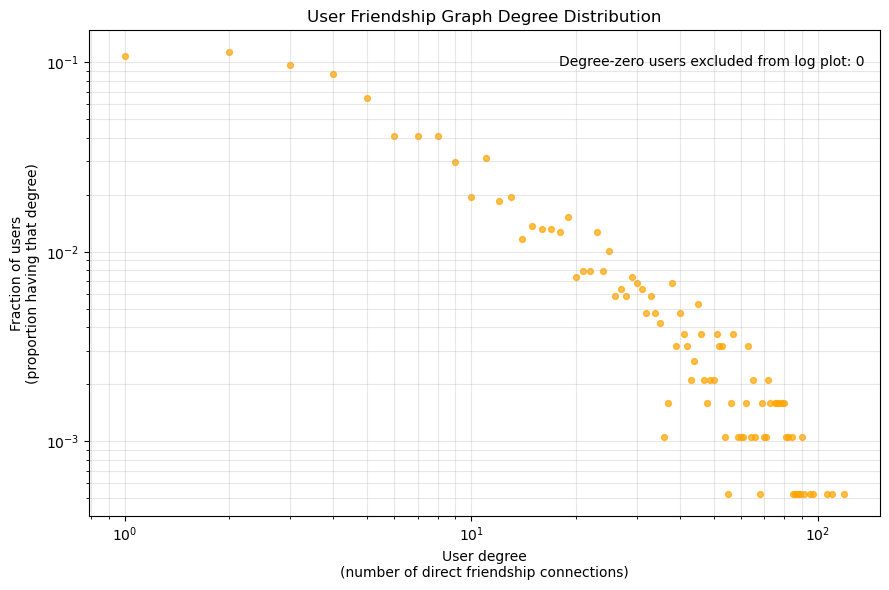

In [ ]:
md("""
### 4.2 User Friendship Graph Degree Distribution

The degree of a user is the number of direct friendship connections that user has.

The plot below shows us:
- **x-axis:** number of direct friendships;
- **y-axis:** fraction of users having that number of friendships.

Do Note that both axes use logarithmic scales so that common low-degree users and rare high-degree users can be shown in the same figure.
""")

user_degree_distribution = plot_degree_distribution(G_user,
    "User Friendship Graph Degree Distribution",
    ("User degree\n" "(number of direct friendship connections)"),
    "users", "user_degree_distribution.png",
)

# If we require an export.
user_degree_distribution.to_csv(
    OUT_DIR / "user_degree_distribution.csv",
    index=False,
)


### 4.4 Artist Co-Listening Graph Degree Distribution

The degree of an artist is the number of other artists connected to it
through shared listeners.

The plot below shows:

- **x-axis:** number of connected artists;
- **y-axis:** fraction of artists having that degree.

The graph uses logarithmic scales because artist degree ranges from
isolated nodes to artists connected with several thousand others.


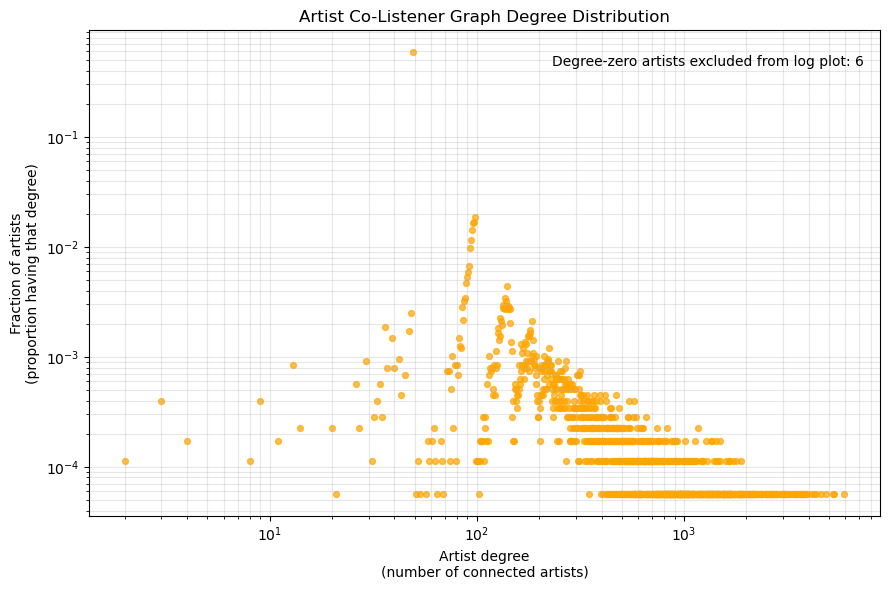

In [ ]:
md("""
### 4.4 Artist Co-Listening Graph Degree Distribution

The degree of an artist is the number of other artists connected to it
through shared listeners.

The plot below shows:

- **x-axis:** number of connected artists;
- **y-axis:** fraction of artists having that degree.

The graph uses logarithmic scales because artist degree ranges from
isolated nodes to artists connected with several thousand others.
""")


artist_degree_distribution = plot_degree_distribution(
    G_art,
    "Artist Co-Listener Graph Degree Distribution",
    "Artist degree\n(number of connected artists)",
    "artists",
    "artist_degree_distribution.png",
)

# If we need to export the results:
artist_degree_distribution.to_csv(
    OUT_DIR / "artist_degree_distribution.csv",
    index=False,
)

In [ ]:
md("""
### 4.4.1 Checking the Top-50 Library Structure

The artist degree distribution above is dominated by a single value. Before
interpreting it, this cell measures how many artists each user library
actually contains.

This matters because the artist graph connects every pair of artists sharing a
listener. If user libraries are capped at a fixed size, that cap sets a floor
on how many connections an artist inherits from a single library, and the
degree distribution reflects the data format rather than any musical pattern.

The dataset documentation reports an average of 49.067 artists most listened
by each user, but states no maximum. This cell measures the maximum directly.
""")

artists_per_user = user_artists.groupby("userID").size()

library_size_summary = pd.DataFrame([
    {"measure": "Maximum artists per user", "value": int(artists_per_user.max())},
    {"measure": "Minimum artists per user", "value": int(artists_per_user.min())},
    {"measure": "Median artists per user", "value": float(artists_per_user.median())},
    {"measure": "Mean artists per user", "value": round(float(artists_per_user.mean()), 3)},
    {"measure": "Users at the maximum", "value": int((artists_per_user == artists_per_user.max()).sum())},
    {"measure": "Users profiled", "value": int(len(artists_per_user))},
])

display(library_size_summary)

library_size_summary.to_csv(
    OUT_DIR / "user_library_size_summary.csv",
    index=False,
)

assert len(artists_per_user) == 1_892, (
    "The listening table does not cover all users."
)
assert artists_per_user.min() >= 1, (
    "A user has no listening records."
)

maximum_library = int(artists_per_user.max())
users_at_maximum = int((artists_per_user == maximum_library).sum())

md(f"""
### Library-Size Results

- **Maximum artists per user:** {maximum_library}
- **Minimum artists per user:** {int(artists_per_user.min())}
- **Mean artists per user:** {artists_per_user.mean():.3f}
- **Users at the maximum:** {users_at_maximum:,} of {len(artists_per_user):,}
  ({users_at_maximum / len(artists_per_user):.1%})

The dataset caps each user library at {maximum_library} artists. The median
library is also {maximum_library}, and only
{len(artists_per_user) - users_at_maximum:,} users hold fewer than the cap, so
a full library is the normal case rather than the exception.

The consequence for the artist graph is direct. Every artist in a full library
is connected to the other {maximum_library - 1} artists in it. An artist that
appears in exactly one full library and nowhere else therefore has exactly
{maximum_library - 1} connections, whoever that artist is and whatever they
sound like. That is the origin of the concentration examined in the next
section, and it is the reason artist importance is measured later using
weighted PageRank on the connection weights rather than any measure that
counts connections.
""")


### 4.4.1 Checking the Top-50 Library Structure

The artist degree distribution above is dominated by a single value. Before
interpreting it, this cell measures how many artists each user library
actually contains.

This matters because the artist graph connects every pair of artists sharing a
listener. If user libraries are capped at a fixed size, that cap sets a floor
on how many connections an artist inherits from a single library, and the
degree distribution reflects the data format rather than any musical pattern.

The dataset documentation reports an average of 49.067 artists most listened
by each user, but states no maximum. This cell measures the maximum directly.


,measure,value
0,Maximum artists per user,50.000
1,Minimum artists per user,1.000
2,Median artists per user,50.000
3,Mean artists per user,49.064
4,Users at the maximum,1825.000
5,Users profiled,1892.000



### Library-Size Results

- **Maximum artists per user:** 50
- **Minimum artists per user:** 1
- **Mean artists per user:** 49.064
- **Users at the maximum:** 1,825 of 1,892
  (96.5%)

The dataset caps each user library at 50 artists. The median
library is also 50, and only
67 users hold fewer than the cap, so
a full library is the normal case rather than the exception.

The consequence for the artist graph is direct. Every artist in a full library
is connected to the other 49 artists in it. An artist that
appears in exactly one full library and nowhere else therefore has exactly
49 connections, whoever that artist is and whatever they
sound like. That is the origin of the concentration examined in the next
section, and it is the reason artist importance is measured later using
weighted PageRank on the connection weights rather than any measure that
counts connections.



## 4.5 Focused View of Artists with 49 Connections

The full logarithmic chart shows all artist connection counts, but the
large group at 49 connections is difficult to identify precisely.

This chart focuses on 0–200 connections and highlights the artists with
exactly 49 connections.


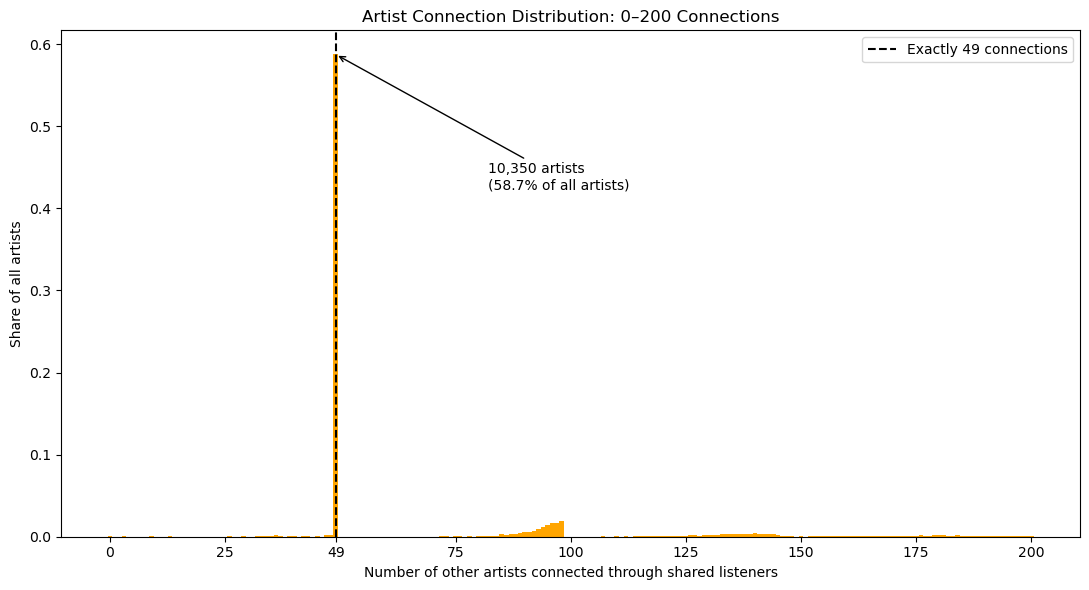


### What the chart shows

- **Artists with exactly 49 connections:** 10,350
- **Share of all artists:** 58.7%

When a user listens to 50 artists, each artist becomes connected to the
other 49 artists in that user's library.

The large group at 49 connections is therefore partly caused by the
method used to create the artist graph.


In [ ]:
md("""
## 4.5 Focused View of Artists with 49 Connections

The full logarithmic chart shows all artist connection counts, but the
large group at 49 connections is difficult to identify precisely.

This chart focuses on 0–200 connections and highlights the artists with
exactly 49 connections.
""")

degree_49 = artist_degree_distribution.set_index("degree").loc[49]
degree_49_count = int(degree_49["node_count"])
degree_49_fraction = float(degree_49["node_fraction"])

assert degree_49_count == 10_350, "Unexpected degree-49 artist count."
assert round(degree_49_fraction, 3) == 0.587, ("Unexpected degree-49 artist percentage.")

focused = artist_degree_distribution.query("degree <= 200")
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(
    focused["degree"],
    focused["node_fraction"],
    width=1,
    color="orange",)
ax.axvline(
    49,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Exactly 49 connections",)
ax.annotate(
    f"{degree_49_count:,} artists\n"
    f"({degree_49_fraction:.1%} of all artists)",
    xy=(49, degree_49_fraction),
    xytext=(82, degree_49_fraction * 0.72),
    arrowprops={"arrowstyle": "->","color": "black",},)

ax.set(
    title="Artist Connection Distribution: 0–200 Connections",
    xlabel="Number of other artists connected through shared listeners",
    ylabel="Share of all artists",
    xticks=[0, 25, 49, 75, 100, 125, 150, 175, 200],)

ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "artist_degree_distribution_focused.png",dpi=160,bbox_inches="tight",)

plt.show()

md(f"""
### What the chart shows

- **Artists with exactly 49 connections:** {degree_49_count:,}
- **Share of all artists:** {degree_49_fraction:.1%}

When a user listens to 50 artists, each artist becomes connected to the
other 49 artists in that user's library.

The large group at 49 connections is therefore partly caused by the
method used to create the artist graph.
""")


## 4.6 Degree "49" Compared with All Other Degrees

Many artists have exactly 49 connections, making smaller groups difficult
to see. The top chart compares these artists with everyone else. The
bottom chart excludes degree 49 only from the display so the remaining
connection counts are easier to inspect.


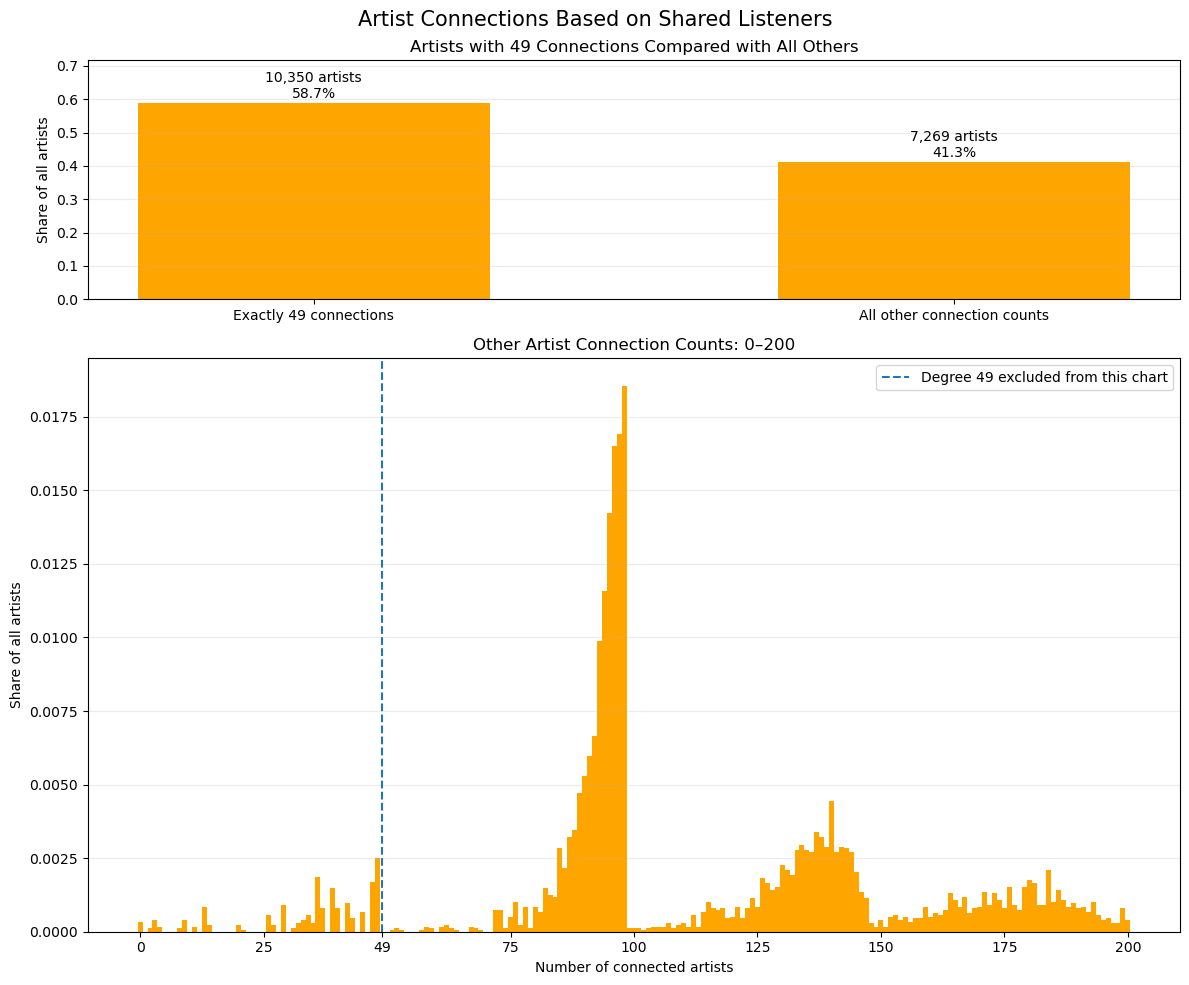


#### What the charts show

- **Exactly 49 connections:** 10,350 artists
  (58.7%)
- **All other connection counts:** 7,269 artists
  (41.3%)

More than half of all artists have exactly 49 connections. Removing this
large group from the lower chart makes the remaining pattern easier to
see: most artists have relatively few connections, while a small number
have many.


In [ ]:
md("""
## 4.6 Degree "49" Compared with All Other Degrees

Many artists have exactly 49 connections, making smaller groups difficult
to see. The top chart compares these artists with everyone else. The
bottom chart excludes degree 49 only from the display so the remaining
connection counts are easier to inspect.
""")

total_artists = G_art.number_of_nodes()
non_49_count = total_artists - degree_49_count
non_49_fraction = 1 - degree_49_fraction

without_49 = artist_degree_distribution.query(
    "degree <= 200 and degree != 49"
)

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(12, 10),
    gridspec_kw={"height_ratios": [1, 2.4]}
)

labels = ["Exactly 49 connections", "All other connection counts"]
fractions = [degree_49_fraction, non_49_fraction]
counts = [degree_49_count, non_49_count]

bars = ax_top.bar(labels, fractions, width=0.55, color="orange")

for bar, count, fraction in zip(bars, counts, fractions):
    ax_top.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{count:,} artists\n{fraction:.1%}",
        ha="center",
    )

ax_top.set(
    title="Artists with 49 Connections Compared with All Others",
    ylabel="Share of all artists",
    ylim=(0, max(fractions) * 1.22),
)
ax_top.grid(axis="y", alpha=0.25)

ax_bottom.bar(
    without_49["degree"],
    without_49["node_fraction"],
    width=1,
    color="orange",
)
ax_bottom.axvline(
    49, linestyle="--", linewidth=1.5,
    label="Degree 49 excluded from this chart"
)
ax_bottom.set(
    title="Other Artist Connection Counts: 0–200",
    xlabel="Number of connected artists",
    ylabel="Share of all artists",
    xticks=[0, 25, 49, 75, 100, 125, 150, 175, 200],
)
ax_bottom.grid(axis="y", alpha=0.25)
ax_bottom.legend()

fig.suptitle("Artist Connections Based on Shared Listeners", fontsize=15)
fig.tight_layout()
fig.savefig(
    OUT_DIR / "artist_degree_49_two_panel.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

md(f"""
#### What the charts show

- **Exactly 49 connections:** {degree_49_count:,} artists
  ({degree_49_fraction:.1%})
- **All other connection counts:** {non_49_count:,} artists
  ({non_49_fraction:.1%})

More than half of all artists have exactly 49 connections. Removing this
large group from the lower chart makes the remaining pattern easier to
see: most artists have relatively few connections, while a small number
have many.
""")


In [ ]:
md(f"""
## 4.7 Interpretation of the Basic Graph Analysis

### User friendship graph

The user friendship graph contains **{user_graph_report["nodes"]:,}
users** and **{user_graph_report["edges"]:,} friendship connections**.

The graph is divided into
**{user_graph_report["connected_components"]} separate groups**.
The largest group contains
**{user_graph_report["giant_component_size"]:,} users**.

There are **{user_graph_report["isolated_nodes"]} isolated users**.
These users have no recorded friendships. Other users may have
friendships but belong to smaller groups that are separate from the
largest part of the network.

Most users have a small number of friends, while a much smaller number
have dozens or more than one hundred connections. This means that the
network contains a small number of highly connected users who act as
social hubs.

The downward pattern in the logarithmic degree-distribution graph does
not prove that the network follows a power-law distribution. Additional
statistical testing would be needed to make that claim.

The average clustering coefficient of the user graph is
**{user_graph_report["average_clustering"]:.4f}**.

This shows that there is some tendency for a user's friends to also be
friends with one another. However, the network is not made up entirely
of tightly connected friendship groups.

### Artist co-listener graph

The artist co-listener graph contains
**{artist_graph_report["nodes"]:,} artists** and
**{artist_graph_report["edges"]:,} co-listening connections**.

Two artists are connected when they have been listened to by at least
one of the same users. The connection weights show how many listeners
the two artists share.

The graph contains
**{artist_graph_report["connected_components"]} separate groups**.
The largest group contains
**{artist_graph_report["giant_component_size"]:,} artists**.

There are **{artist_graph_report["isolated_nodes"]} isolated artists**.
These artists do not share a listener with any other artist in the
dataset.

The artist degree distribution is very different from the user degree
distribution. Its clearest feature is the large group of artists with
exactly 49 connections:

- **{degree_49_count:,} artists** have exactly 49 connections;
- this is **{degree_49_fraction:.1%} of all artists**;
- the remaining **{non_49_count:,} artists** account for
  **{non_49_fraction:.1%}** of the graph.

This means that more than half of all artists have the same number of
connections.

This result is largely caused by the way the artist graph was created.
When a user listens to 50 artists, each artist in that library becomes
connected to the other 49 artists.

Therefore, an artist that appears in only one 50-artist library can
receive exactly 49 connections simply because of the graph-construction
process.

The supporting comparison chart shows how large this group is. The
number of artists with exactly 49 connections is greater than the total
number of artists at all other connection counts combined.

The lower chart temporarily removes degree 49 from the display so that
the smaller groups are easier to see. Degree 49 is still included in
the dataset and in all calculations.

After removing degree 49 from the display, smaller groups can be seen
around approximately 90–100, 130–145 and 170–190 connections.

These groups may contain artists that appear in several overlapping
user libraries. However, the graph alone cannot show whether these
patterns are linked to genre, popularity or listening behaviour. The
artists and listeners involved would need to be examined directly.

The complete logarithmic graph also has a long right-hand tail. This
means that a small number of artists are connected to hundreds or even
thousands of other artists.

These highly connected artists appear across broad areas of the
co-listening network. In contrast, the large degree-49 group is strongly
influenced by the way the graph was constructed.

The average clustering coefficient of the artist graph is
**{artist_graph_report["average_clustering"]:.4f}**. This is much higher
than the user graph value of
**{user_graph_report["average_clustering"]:.4f}**.

This high clustering should be interpreted carefully. Each user's
listening library creates a tightly connected group of artists because
all artists in that library are connected to one another.

The high clustering and repeated degree values are therefore partly
caused by the projection method. They should not automatically be
treated as evidence of natural music communities, artist popularity or
musical importance.

### Overall conclusion

The two graphs represent different types of relationships.

- The **user graph** represents direct friendships. Most users have a
  small number of friends, while a few users act as highly connected
  social hubs.
- The **artist graph** represents shared listening behaviour. It is more
  densely connected and has much higher clustering.

The artist graph is useful for studying shared listening patterns, but
its measurements cannot be interpreted in the same way as those of the
friendship graph.

In particular, the large concentration at degree 49 shows that the
method used to create the graph has a major effect on its structure.

The later centrality analysis should therefore separate artists that are
genuinely important across the network from artists that appear
important mainly because of the graph-construction process.

---
""")


## 4.7 Interpretation of the Basic Graph Analysis

### User friendship graph

The user friendship graph contains **1,892
users** and **12,717 friendship connections**.

The graph is divided into
**20 separate groups**.
The largest group contains
**1,843 users**.

There are **0 isolated users**.
These users have no recorded friendships. Other users may have
friendships but belong to smaller groups that are separate from the
largest part of the network.

Most users have a small number of friends, while a much smaller number
have dozens or more than one hundred connections. This means that the
network contains a small number of highly connected users who act as
social hubs.

The downward pattern in the logarithmic degree-distribution graph does
not prove that the network follows a power-law distribution. Additional
statistical testing would be needed to make that claim.

The average clustering coefficient of the user graph is
**0.1865**.

This shows that there is some tendency for a user's friends to also be
friends with one another. However, the network is not made up entirely
of tightly connected friendship groups.

### Artist co-listener graph

The artist co-listener graph contains
**17,619 artists** and
**1,319,800 co-listening connections**.

Two artists are connected when they have been listened to by at least
one of the same users. The connection weights show how many listeners
the two artists share.

The graph contains
**8 separate groups**.
The largest group contains
**17,609 artists**.

There are **6 isolated artists**.
These artists do not share a listener with any other artist in the
dataset.

The artist degree distribution is very different from the user degree
distribution. Its clearest feature is the large group of artists with
exactly 49 connections:

- **10,350 artists** have exactly 49 connections;
- this is **58.7% of all artists**;
- the remaining **7,269 artists** account for
  **41.3%** of the graph.

This means that more than half of all artists have the same number of
connections.

This result is largely caused by the way the artist graph was created.
When a user listens to 50 artists, each artist in that library becomes
connected to the other 49 artists.

Therefore, an artist that appears in only one 50-artist library can
receive exactly 49 connections simply because of the graph-construction
process.

The supporting comparison chart shows how large this group is. The
number of artists with exactly 49 connections is greater than the total
number of artists at all other connection counts combined.

The lower chart temporarily removes degree 49 from the display so that
the smaller groups are easier to see. Degree 49 is still included in
the dataset and in all calculations.

After removing degree 49 from the display, smaller groups can be seen
around approximately 90–100, 130–145 and 170–190 connections.

These groups may contain artists that appear in several overlapping
user libraries. However, the graph alone cannot show whether these
patterns are linked to genre, popularity or listening behaviour. The
artists and listeners involved would need to be examined directly.

The complete logarithmic graph also has a long right-hand tail. This
means that a small number of artists are connected to hundreds or even
thousands of other artists.

These highly connected artists appear across broad areas of the
co-listening network. In contrast, the large degree-49 group is strongly
influenced by the way the graph was constructed.

The average clustering coefficient of the artist graph is
**0.7950**. This is much higher
than the user graph value of
**0.1865**.

This high clustering should be interpreted carefully. Each user's
listening library creates a tightly connected group of artists because
all artists in that library are connected to one another.

The high clustering and repeated degree values are therefore partly
caused by the projection method. They should not automatically be
treated as evidence of natural music communities, artist popularity or
musical importance.

### Overall conclusion

The two graphs represent different types of relationships.

- The **user graph** represents direct friendships. Most users have a
  small number of friends, while a few users act as highly connected
  social hubs.
- The **artist graph** represents shared listening behaviour. It is more
  densely connected and has much higher clustering.

The artist graph is useful for studying shared listening patterns, but
its measurements cannot be interpreted in the same way as those of the
friendship graph.

In particular, the large concentration at degree 49 shows that the
method used to create the graph has a major effect on its structure.

The later centrality analysis should therefore separate artists that are
genuinely important across the network from artists that appear
important mainly because of the graph-construction process.

---


In [ ]:
md("""

## 5. User Centrality Analysis

This section uses four measures to identify users who hold important positions in the friendship network.

## 5.1 Centrality measures

#### Degree centrality

Degree centrality measures how many users someone is directly connected to compared with the total number of possible connections.
A high score means the user has many direct friendships.

#### Betweenness centrality

Betweenness centrality measures how often a user appears on the shortest routes between other users.
A high score suggests that the user may connect groups that would otherwise be less closely linked.

#### Closeness centrality

Closeness centrality measures how easily a user can reach other users through the friendship network.
A high score means the user can reach others using relatively few friendship steps.
Because the graph contains separate groups, NetworkX adjusts the calculation to account for users who cannot reach every other user.

#### PageRank

PageRank gives higher scores to users who are connected to other important and well-connected users.
This means a user can have a high PageRank score even without having the largest number of direct friendships.
The highest-ranked users are described as **structural tastemaker candidates** because their network positions may give them greater visibility or influence.
However, centrality only shows structural importance. It does not prove that these users caused their friends to listen to particular artists.
""")




## 5. User Centrality Analysis

This section uses four measures to identify users who hold important positions in the friendship network.

## 5.1 Centrality measures

#### Degree centrality

Degree centrality measures how many users someone is directly connected to compared with the total number of possible connections.
A high score means the user has many direct friendships.

#### Betweenness centrality

Betweenness centrality measures how often a user appears on the shortest routes between other users.
A high score suggests that the user may connect groups that would otherwise be less closely linked.

#### Closeness centrality

Closeness centrality measures how easily a user can reach other users through the friendship network.
A high score means the user can reach others using relatively few friendship steps.
Because the graph contains separate groups, NetworkX adjusts the calculation to account for users who cannot reach every other user.

#### PageRank

PageRank gives higher scores to users who are connected to other important and well-connected users.
This means a user can have a high PageRank score even without having the largest number of direct friendships.
The highest-ranked users are described as **structural tastemaker candidates** because their network positions may give them greater visibility or influence.
However, centrality only shows structural importance. It does not prove that these users caused their friends to listen to particular artists.


In [ ]:
md("""
### Calculating user centrality scores

Here we measure how important each user is within the friendship
network in four different ways:

- **Degree centrality:** users with many direct friends;
- **Betweenness centrality:** users who connect different parts of the network;
- **Closeness centrality:** users who can reach others in relatively few steps;
- **PageRank:** users connected to other important users.

The cell also records how long each calculation takes.
""")

centrality_functions = {
    "Degree centrality": lambda: nx.degree_centrality(G_user),
    "Betweenness centrality": lambda: nx.betweenness_centrality(
        G_user,
        normalized=True,
        weight=None,
    ),
    "Closeness centrality": lambda: nx.closeness_centrality(
        G_user,
        wf_improved=True,
    ),
    "PageRank": lambda: nx.pagerank(
        G_user,
        alpha=0.85,
        weight=None,
    ),
}

centrality_results = {}
runtime_rows = []

for measure, calculate in centrality_functions.items():
    start = time.perf_counter()
    centrality_results[measure] = calculate()

    runtime_rows.append({
        "measure": measure,
        "runtime_seconds": round(time.perf_counter() - start, 2),
    })

degree_centrality = centrality_results["Degree centrality"]
betweenness_centrality = centrality_results["Betweenness centrality"]
closeness_centrality = centrality_results["Closeness centrality"]
pagerank_centrality = centrality_results["PageRank"]

centrality_runtime = pd.DataFrame(runtime_rows)

display(centrality_runtime)


### Calculating user centrality scores

Here we measure how important each user is within the friendship
network in four different ways:

- **Degree centrality:** users with many direct friends;
- **Betweenness centrality:** users who connect different parts of the network;
- **Closeness centrality:** users who can reach others in relatively few steps;
- **PageRank:** users connected to other important users.

The cell also records how long each calculation takes.


,measure,runtime_seconds
0,Degree centrality,0.00
1,Betweenness centrality,15.70
2,Closeness centrality,3.26
3,PageRank,0.02


In [ ]:
md("""
### Checking the centrality results

Now we check that the four centrality calculations worked correctly.

It confirms that every user has a score, all scores are valid numbers between 0 and 1, and the PageRank scores add up to approximately 1.
If any check fails, the code stops and displays an error message.
""")

expected_user_ids = set(G_user.nodes())

centrality_dictionaries = {
    "degree": degree_centrality,
    "betweenness": betweenness_centrality,
    "closeness": closeness_centrality,
    "pagerank": pagerank_centrality,
}

for measure, scores in centrality_dictionaries.items():
    assert set(scores) == expected_user_ids, (
        f"{measure} does not contain every user."
    )
    assert all(np.isfinite(score) for score in scores.values()), (
        f"{measure} contains an invalid score."
    )
    assert all(0 <= score <= 1 for score in scores.values()), (
        f"{measure} contains a score outside the range 0–1."
    )

assert np.isclose(sum(pagerank_centrality.values()), 1.0), (
    "PageRank scores do not add up to approximately 1."
)

md(f"""
### Centrality calculations validated

All four centrality measures:

- include all **{G_user.number_of_nodes():,} users**;
- contain valid numerical scores;
- have values between 0 and 1;
- were calculated using the unweighted, undirected friendship graph.

The PageRank scores also add up to approximately 1, as expected.
""")


### Checking the centrality results

Now we check that the four centrality calculations worked correctly.

It confirms that every user has a score, all scores are valid numbers between 0 and 1, and the PageRank scores add up to approximately 1.
If any check fails, the code stops and displays an error message.



### Centrality calculations validated

All four centrality measures:

- include all **1,892 users**;
- contain valid numerical scores;
- have values between 0 and 1;
- were calculated using the unweighted, undirected friendship graph.

The PageRank scores also add up to approximately 1, as expected.


In [ ]:
md("""
### Building and ranking the centrality results

Having understood the above we now create one table containing every user's four centrality
scores. It then ranks users from highest to lowest for each measure.

A rank of 1 means that the user has the highest score for that measure.
The cell checks that all users are included, displays a preview and
saves the full table as a CSV file.
""")

user_centrality = pd.DataFrame({
    "userID": sorted(G_user.nodes())
})

centrality_measure_columns = {
    "Degree": "degree_centrality",
    "Betweenness": "betweenness_centrality",
    "Closeness": "closeness_centrality",
    "PageRank": "pagerank",
}

centrality_scores = {
    "degree_centrality": degree_centrality,
    "betweenness_centrality": betweenness_centrality,
    "closeness_centrality": closeness_centrality,
    "pagerank": pagerank_centrality,
}

for column, scores in centrality_scores.items():
    user_centrality[column] = user_centrality["userID"].map(scores)

for measure, score_column in centrality_measure_columns.items():
    user_centrality[f"rank_{measure.lower()}"] = (
        user_centrality[score_column]
        .rank(ascending=False, method="min")
        .astype(int)
    )

assert len(user_centrality) == G_user.number_of_nodes()
assert user_centrality["userID"].is_unique
assert not user_centrality.isna().any().any()

display(user_centrality.head())

user_centrality.to_csv(
    OUT_DIR / "user_centrality_all.csv",
    index=False,
)


### Building and ranking the centrality results

Having understood the above we now create one table containing every user's four centrality
scores. It then ranks users from highest to lowest for each measure.

A rank of 1 means that the user has the highest score for that measure.
The cell checks that all users are included, displays a preview and
saves the full table as a CSV file.


,userID,degree_centrality,betweenness_centrality,closeness_centrality,pagerank,rank_degree,rank_betweenness,rank_closeness,rank_pagerank
0,2,0.006875,0.001337,0.317289,0.000590,555,418,345,536
1,3,0.003702,0.000100,0.259100,0.000456,856,1126,1342,735
2,4,0.005288,0.000072,0.282340,0.000414,686,1196,962,827
3,5,0.003702,0.000807,0.299945,0.000407,856,578,633,838
4,6,0.002644,0.000282,0.298250,0.000285,1010,868,666,1173


In [ ]:
md("""
### Identifying the highest-ranked users

Now we display the top 15 users for each centrality measure.
Users are sorted from highest to lowest score. When two users have the same score, user ID is used to keep the ordering consistent.
The four top-15 tables are displayed and then combined into one CSV file.
""")

def create_top_centrality_table(measure, score_column):
    """Return the top users for one centrality measure."""

    rank_column = f"rank_{measure.lower()}"

    top_users = (
        user_centrality[
            ["userID", score_column, rank_column]
        ]
        .sort_values(
            [score_column, "userID"],
            ascending=[False, True],
        )
        .head(TOP_K)
        .rename(columns={
            score_column: "score",
            rank_column: "statistical_rank",
        })
        .reset_index(drop=True)
    )

    top_users.insert(
        0,
        "position",
        range(1, len(top_users) + 1),
    )
    top_users.insert(0, "measure", measure)

    return top_users


top15_user_tables = {
    measure: create_top_centrality_table(measure, score_column)
    for measure, score_column in centrality_measure_columns.items()
}

top15_users_long = pd.concat(
    top15_user_tables.values(),
    ignore_index=True,
)

for measure, table in top15_user_tables.items():
    md(f"### Top 15 users by {measure}")
    display(table.style.format({"score": "{:.8f}"}))

top15_users_long.to_csv(
    OUT_DIR / "top15_users_by_centrality.csv",
    index=False,
)

md("""
---
""")


### Identifying the highest-ranked users

Now we display the top 15 users for each centrality measure.
Users are sorted from highest to lowest score. When two users have the same score, user ID is used to keep the ordering consistent.
The four top-15 tables are displayed and then combined into one CSV file.


### Top 15 users by Degree

,measure,position,userID,score,statistical_rank
0,Degree,1,1543,0.06292967,1
1,Degree,2,1281,0.05817028,2
2,Degree,3,831,0.05605500,3
3,Degree,4,179,0.05129561,4
4,Degree,5,1503,0.05023797,5
5,Degree,6,1023,0.04812269,6
6,Degree,7,405,0.04759387,7
7,Degree,8,1895,0.04759387,7
8,Degree,9,1300,0.04706504,9
9,Degree,10,390,0.04653622,10


### Top 15 users by Betweenness

,measure,position,userID,score,statistical_rank
0,Betweenness,1,1543,0.06652736,1
1,Betweenness,2,1281,0.05454858,2
2,Betweenness,3,831,0.04869096,3
3,Betweenness,4,1258,0.04302509,4
4,Betweenness,5,78,0.02933678,5
5,Betweenness,6,1213,0.02416713,6
6,Betweenness,7,1130,0.02379942,7
7,Betweenness,8,1503,0.02319715,8
8,Betweenness,9,298,0.02311287,9
9,Betweenness,10,1597,0.02175259,10


### Top 15 users by Closeness

,measure,position,userID,score,statistical_rank
0,Closeness,1,831,0.40221244,1
1,Closeness,2,1543,0.39669903,2
2,Closeness,3,1281,0.38980441,3
3,Closeness,4,143,0.38094898,4
4,Closeness,5,1895,0.37678910,5
5,Closeness,6,1130,0.37310661,6
6,Closeness,7,1503,0.37302904,7
7,Closeness,8,1879,0.37233237,8
8,Closeness,9,59,0.37179231,9
9,Closeness,10,730,0.36835756,10


### Top 15 users by PageRank

,measure,position,userID,score,statistical_rank
0,PageRank,1,1543,0.00524615,1
1,PageRank,2,78,0.00523768,2
2,PageRank,3,1281,0.00473515,3
3,PageRank,4,1258,0.00423032,4
4,PageRank,5,1210,0.00387002,5
5,PageRank,6,831,0.00378334,6
6,PageRank,7,298,0.00306003,7
7,PageRank,8,1488,0.00294297,8
8,PageRank,9,1213,0.00284888,9
9,PageRank,10,1597,0.00278525,10



---


In [ ]:
md("""
### Checking the top-15 tables

Lets verify that each centrality table contains exactly 15 different users and that their scores are ordered from highest to lowest.
If any table fails these checks, the code stops and displays an error.
""")

top15_validation = pd.DataFrame([
    {
        "measure": measure,
        "rows": len(table),
        "unique_users": table["userID"].nunique(),
        "scores_descending": table["score"].is_monotonic_decreasing,
        "passed": (
            len(table) == TOP_K
            and table["userID"].nunique() == TOP_K
            and table["score"].is_monotonic_decreasing
        ),
    }
    for measure, table in top15_user_tables.items()
])

display(top15_validation)

assert top15_validation["passed"].all(), (
    "At least one top-15 centrality table failed validation."
)


### Checking the top-15 tables

Lets verify that each centrality table contains exactly 15 different users and that their scores are ordered from highest to lowest.
If any table fails these checks, the code stops and displays an error.


,measure,rows,unique_users,scores_descending,passed
0,Degree,15,15,True,True
1,Betweenness,15,15,True,True
2,Closeness,15,15,True,True
3,PageRank,15,15,True,True


In [ ]:
md("""

## 5.2 Initial Interpretation of the User Centrality Results

All four centrality measures were calculated for all **1,892 users**.

Users **1543, 1281, 831 and 1503** appear in the top 15 for every
measure, showing that they hold consistently important positions in the
friendship network.

User **1543** is the strongest overall candidate, ranking:

* **1st** for degree;
* **1st** for betweenness;
* **2nd** for closeness;
* **1st** for PageRank.

User **831** ranks first for closeness, meaning that this user can reach
the wider network through relatively few friendship steps.

Other users have more specialised roles. User **179** ranks highly for
degree only, while user **78** ranks highly for betweenness and PageRank
without appearing in the degree top 15. Users **143** and **1258** also
rank more strongly under some measures than others.

This shows that the measures capture different types of importance:

* **Degree:** many direct friends;
* **Betweenness:** connecting different parts of the network;
* **Closeness:** reaching others efficiently;
* **PageRank:** being connected to important users.

These users are best described as **structural tastemaker candidates**,
not confirmed influencers. Their scores show network importance but do
not prove that they caused others to listen to particular artists.

The next section compares the rankings using correlations, top-15
overlap and differences between individual user ranks.

---
""")




## 5.2 Initial Interpretation of the User Centrality Results

All four centrality measures were calculated for all **1,892 users**.

Users **1543, 1281, 831 and 1503** appear in the top 15 for every
measure, showing that they hold consistently important positions in the
friendship network.

User **1543** is the strongest overall candidate, ranking:

* **1st** for degree;
* **1st** for betweenness;
* **2nd** for closeness;
* **1st** for PageRank.

User **831** ranks first for closeness, meaning that this user can reach
the wider network through relatively few friendship steps.

Other users have more specialised roles. User **179** ranks highly for
degree only, while user **78** ranks highly for betweenness and PageRank
without appearing in the degree top 15. Users **143** and **1258** also
rank more strongly under some measures than others.

This shows that the measures capture different types of importance:

* **Degree:** many direct friends;
* **Betweenness:** connecting different parts of the network;
* **Closeness:** reaching others efficiently;
* **PageRank:** being connected to important users.

These users are best described as **structural tastemaker candidates**,
not confirmed influencers. Their scores show network importance but do
not prove that they caused others to listen to particular artists.

The next section compares the rankings using correlations, top-15
overlap and differences between individual user ranks.

---


In [ ]:
md("""

## 6. Centrality Ranking Comparison

The four centrality measures identify different types of important
users. This section compares the results to show:

* which measures rank users similarly;
* which users appear in more than one top-15 list;
* which users remain important across all measures;
* which users have more specialised network roles.

Two comparisons are used.

### Spearman rank correlation

Spearman correlation compares how all **1,892 users** are ranked.

* A value near **1** means the rankings are very similar.
* A value near **0** means there is little agreement.
* A value near **-1** means the rankings are mostly opposite.

### Top-15 overlap

Top-15 overlap counts how many users appear in both measures' top-15
lists.
This shows whether the measures identify the same leading structural
tastemaker candidates.
""")




## 6. Centrality Ranking Comparison

The four centrality measures identify different types of important
users. This section compares the results to show:

* which measures rank users similarly;
* which users appear in more than one top-15 list;
* which users remain important across all measures;
* which users have more specialised network roles.

Two comparisons are used.

### Spearman rank correlation

Spearman correlation compares how all **1,892 users** are ranked.

* A value near **1** means the rankings are very similar.
* A value near **0** means there is little agreement.
* A value near **-1** means the rankings are mostly opposite.

### Top-15 overlap

Top-15 overlap counts how many users appear in both measures' top-15
lists.
This shows whether the measures identify the same leading structural
tastemaker candidates.


In [ ]:
md("""
### Comparing the centrality rankings

How similarly the four centrality measures rank all users.
A correlation close to 1 means that two measures rank users in a similar order. A value close to 0 means that their rankings differ.
The results are displayed, saved as a CSV file and checked for validity.

""")

centrality_score_columns = {
    "Degree": "degree_centrality",
    "Betweenness": "betweenness_centrality",
    "Closeness": "closeness_centrality",
    "PageRank": "pagerank",
}

centrality_spearman = (
    user_centrality[list(centrality_score_columns.values())]
    .rename(columns={
        column: measure
        for measure, column in centrality_score_columns.items()
    })
    .corr(method="spearman")
)

display(centrality_spearman.round(3))

centrality_spearman.to_csv(
    OUT_DIR / "centrality_spearman_correlation.csv"
)

assert centrality_spearman.shape == (4, 4)
assert np.allclose(np.diag(centrality_spearman), 1.0)
assert centrality_spearman.to_numpy().min() >= -1
assert centrality_spearman.to_numpy().max() <= 1


### Comparing the centrality rankings

How similarly the four centrality measures rank all users.
A correlation close to 1 means that two measures rank users in a similar order. A value close to 0 means that their rankings differ.
The results are displayed, saved as a CSV file and checked for validity.



,Degree,Betweenness,Closeness,PageRank
Degree,1.000,0.825,0.904,0.895
Betweenness,0.825,1.000,0.794,0.838
Closeness,0.904,0.794,1.000,0.741
PageRank,0.895,0.838,0.741,1.000



### Spearman correlation heatmap

This heatmap shows how closely the four centrality methods rank users.
Values closer to **1** mean that two methods produce similar rankings. Lower values mean that the methods identify users differently.


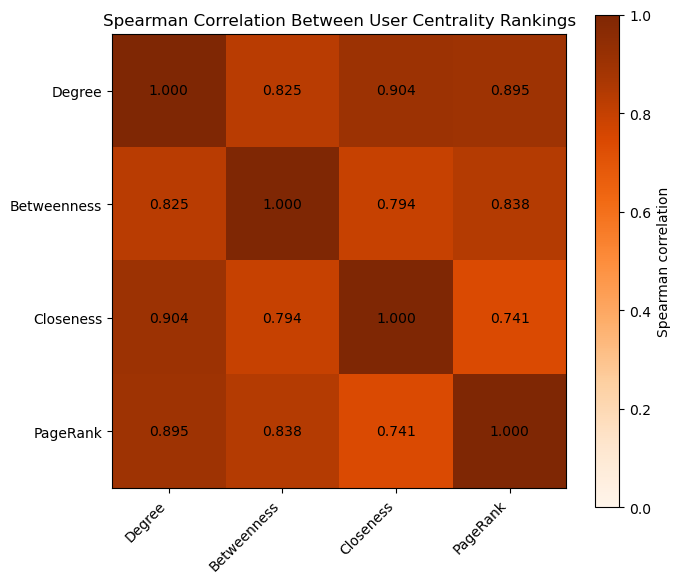

In [ ]:
md("""
### Spearman correlation heatmap

This heatmap shows how closely the four centrality methods rank users.
Values closer to **1** mean that two methods produce similar rankings. Lower values mean that the methods identify users differently.
""")

fig, ax = plt.subplots(figsize=(7, 6))

heatmap = ax.imshow(
    centrality_spearman,
    vmin=0,
    vmax=1,
    cmap="Oranges",)

labels = centrality_spearman.columns
positions = range(len(labels))

ax.set(
    title="Spearman Correlation Between User Centrality Rankings",
    xticks=positions,
    yticks=positions,
    xticklabels=labels,
    yticklabels=labels,)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for row, column in np.ndindex(centrality_spearman.shape):
    ax.text(
        column,
        row,
        f"{centrality_spearman.iloc[row, column]:.3f}",
        ha="center",
        va="center",)

fig.colorbar(
    heatmap,
    ax=ax,
    label="Spearman correlation",)

fig.tight_layout()
fig.savefig(
    OUT_DIR / "centrality_spearman_heatmap.png",
    dpi=160,
    bbox_inches="tight",)

plt.show()

In [ ]:
md("""
### Comparing the top-15 user lists

This cell checks how many users appear in the top 15 for more than one centrality measure.

A higher number means that two measures identify many of the same important users. A lower number means that they highlight different users or network roles.
""")

top15_user_sets = {measure: set(table["userID"]) for measure, table in top15_user_tables.items()}
centrality_labels = list(top15_user_sets)
top15_overlap = pd.DataFrame(
    [[len(top15_user_sets[measure_a] & top15_user_sets[measure_b]) for measure_b in centrality_labels]
        for measure_a in centrality_labels],
    index=centrality_labels,
    columns=centrality_labels,
    dtype="int64",)

display(top15_overlap)

top15_overlap.to_csv(OUT_DIR / "centrality_top15_overlap.csv")
#assert (np.diag(top15_overlap) == TOP_K).all()


### Comparing the top-15 user lists

This cell checks how many users appear in the top 15 for more than one centrality measure.

A higher number means that two measures identify many of the same important users. A lower number means that they highlight different users or network roles.


,Degree,Betweenness,Closeness,PageRank
Degree,15,5,5,6
Betweenness,5,15,10,11
Closeness,5,10,15,8
PageRank,6,11,8,15



### Top-15 overlap heatmap

This heatmap shows how many users appear in both top-15 lists for each pair of centrality measures.
Higher values mean the two measures identify more of the same leading users. Lower values mean they highlight different users or network roles.


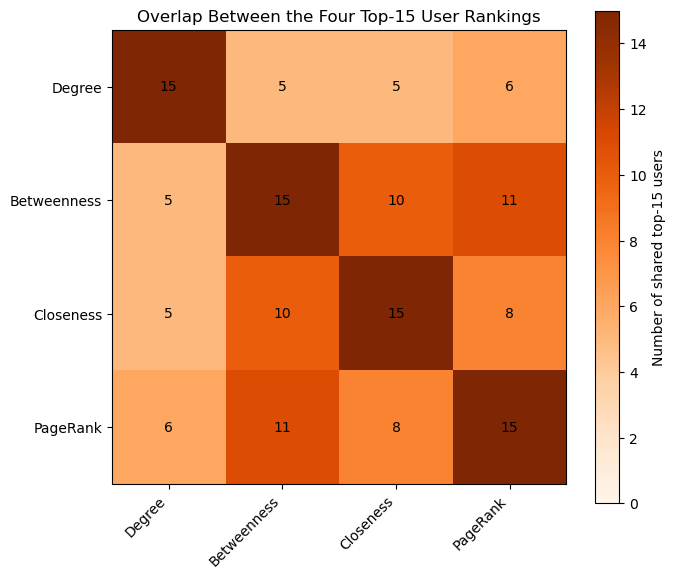

In [ ]:
md("""
### Top-15 overlap heatmap

This heatmap shows how many users appear in both top-15 lists for each pair of centrality measures.
Higher values mean the two measures identify more of the same leading users. Lower values mean they highlight different users or network roles.
""")

fig, ax = plt.subplots(figsize=(7, 6))

overlap_image = ax.imshow(
    top15_overlap,
    vmin=0,
    vmax=TOP_K,
    cmap="Oranges",)

labels = top15_overlap.columns
positions = range(len(labels))

ax.set(
    title="Overlap Between the Four Top-15 User Rankings",
    xticks=positions,
    yticks=positions,
    xticklabels=labels,
    yticklabels=labels,)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for row, column in np.ndindex(top15_overlap.shape):
    ax.text(
        column,
        row,
        str(top15_overlap.iloc[row, column]),
        ha="center",
        va="center",)

fig.colorbar(
    overlap_image,
    ax=ax,
    label="Number of shared top-15 users",)

fig.tight_layout()
fig.savefig(
    OUT_DIR / "centrality_top15_overlap_heatmap.png",
    dpi=160,
    bbox_inches="tight",)
plt.show()


### 6.4 Combined View of the Two Centrality Comparisons

The two comparisons above answer different questions, and the point of interest
is that they disagree. This figure places them side by side.

- **Left:** how similarly each pair of measures ranks all 1,892 users.
- **Right:** how many users each pair shares in its top 15.

Darker cells mean stronger agreement. A pair can be dark on the left and pale
on the right, which means the two measures order the population similarly but
identify a different leading group.


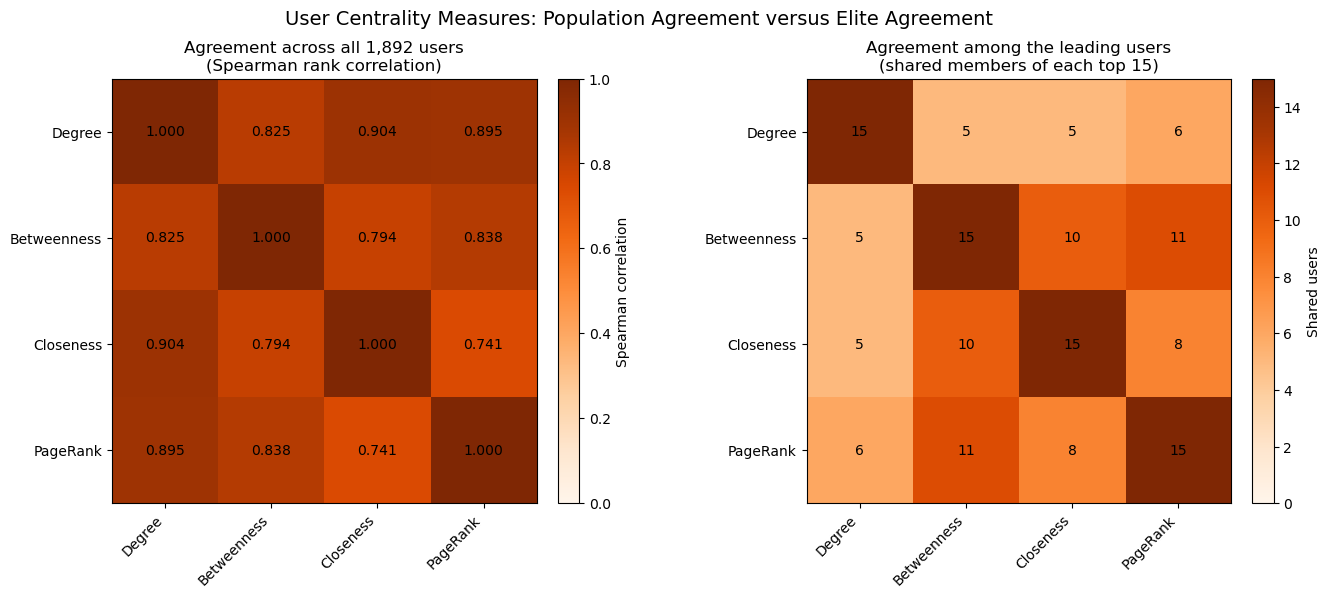


#### What the combined figure shows

- **Strongest population agreement:** degree and closeness at
  **0.904**.
- **Weakest population agreement:** closeness and PageRank at
  **0.741**.
- **Largest top-15 overlap:** betweenness and PageRank, sharing
  **11 users**.
- **Degree's top-15 overlap** is
  **5** with betweenness,
  **5** with closeness and
  **6** with PageRank, despite
  correlating at
  **0.825** or higher with
  every other measure.

Degree therefore behaves like the other measures across the population but
selects a different set of leading users.


In [ ]:
md("""
### 6.4 Combined View of the Two Centrality Comparisons

The two comparisons above answer different questions, and the point of interest
is that they disagree. This figure places them side by side.

- **Left:** how similarly each pair of measures ranks all 1,892 users.
- **Right:** how many users each pair shares in its top 15.

Darker cells mean stronger agreement. A pair can be dark on the left and pale
on the right, which means the two measures order the population similarly but
identify a different leading group.
""")

fig, (ax_correlation, ax_overlap) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

labels = list(centrality_spearman.columns)
positions = range(len(labels))

correlation_image = ax_correlation.imshow(
    centrality_spearman,
    vmin=0,
    vmax=1,
    cmap="Oranges",
)

ax_correlation.set(
    title="Agreement across all 1,892 users\n(Spearman rank correlation)",
    xticks=positions,
    yticks=positions,
    xticklabels=labels,
    yticklabels=labels,
)

for row, column in np.ndindex(centrality_spearman.shape):
    ax_correlation.text(
        column,
        row,
        f"{centrality_spearman.iloc[row, column]:.3f}",
        ha="center",
        va="center",
        fontsize=10,
    )

fig.colorbar(
    correlation_image,
    ax=ax_correlation,
    fraction=0.046,
    pad=0.04,
    label="Spearman correlation",
)

overlap_image = ax_overlap.imshow(
    top15_overlap,
    vmin=0,
    vmax=TOP_K,
    cmap="Oranges",
)

ax_overlap.set(
    title=f"Agreement among the leading users\n(shared members of each top {TOP_K})",
    xticks=positions,
    yticks=positions,
    xticklabels=labels,
    yticklabels=labels,
)

for row, column in np.ndindex(top15_overlap.shape):
    ax_overlap.text(
        column,
        row,
        f"{int(top15_overlap.iloc[row, column])}",
        ha="center",
        va="center",
        fontsize=10,
    )

fig.colorbar(
    overlap_image,
    ax=ax_overlap,
    fraction=0.046,
    pad=0.04,
    label="Shared users",
)

for axis in (ax_correlation, ax_overlap):
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right")

fig.suptitle(
    "User Centrality Measures: Population Agreement versus Elite Agreement",
    fontsize=14,
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "centrality_comparison_combined.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

md(f"""
#### What the combined figure shows

- **Strongest population agreement:** degree and closeness at
  **{centrality_spearman.loc["Degree", "Closeness"]:.3f}**.
- **Weakest population agreement:** closeness and PageRank at
  **{centrality_spearman.loc["Closeness", "PageRank"]:.3f}**.
- **Largest top-15 overlap:** betweenness and PageRank, sharing
  **{int(top15_overlap.loc["Betweenness", "PageRank"])} users**.
- **Degree's top-15 overlap** is
  **{int(top15_overlap.loc["Degree", "Betweenness"])}** with betweenness,
  **{int(top15_overlap.loc["Degree", "Closeness"])}** with closeness and
  **{int(top15_overlap.loc["Degree", "PageRank"])}** with PageRank, despite
  correlating at
  **{centrality_spearman.loc["Degree", "Betweenness"]:.3f}** or higher with
  every other measure.

Degree therefore behaves like the other measures across the population but
selects a different set of leading users.
""")

In [ ]:
md("""
### Finding users who rank highly in every measure

This cell identifies users who appear in the top 15 for all four centrality measures.

These users are important under several different definitions of network importance, making them the strongest overall structural tastemaker candidates.
""")

consensus_user_ids = sorted(set.intersection(*top15_user_sets.values()))

assert consensus_user_ids == [831, 1281, 1503, 1543], ("The expected four-way consensus users were not reproduced.")

score_columns = ["userID","degree_centrality","rank_degree","betweenness_centrality","rank_betweenness","closeness_centrality","rank_closeness","pagerank","rank_pagerank",]

consensus_user_table = (
    user_centrality
    .loc[user_centrality["userID"].isin(consensus_user_ids), score_columns]
    .sort_values("rank_pagerank")
    .reset_index(drop=True))

display(
    consensus_user_table.style.format({
        "degree_centrality": "{:.6f}",
        "betweenness_centrality": "{:.6f}",
        "closeness_centrality": "{:.6f}",
        "pagerank": "{:.6f}",}))

consensus_user_table.to_csv(OUT_DIR / "centrality_consensus_users.csv", index=False,)

md(f"""
### Users appearing in all four top-15 lists

The following users appear in every top-15 ranking:

**{", ".join(map(str, consensus_user_ids))}**

These users form the most consistent group of structural tastemaker candidates because they rank highly under every centrality measure.
""")


### Finding users who rank highly in every measure

This cell identifies users who appear in the top 15 for all four centrality measures.

These users are important under several different definitions of network importance, making them the strongest overall structural tastemaker candidates.


,userID,degree_centrality,rank_degree,betweenness_centrality,rank_betweenness,closeness_centrality,rank_closeness,pagerank,rank_pagerank
0,1543,0.062930,1,0.066527,1,0.396699,2,0.005246,1
1,1281,0.058170,2,0.054549,2,0.389804,3,0.004735,3
2,831,0.056055,3,0.048691,3,0.402212,1,0.003783,6
3,1503,0.050238,5,0.023197,8,0.373029,7,0.002652,11



### Users appearing in all four top-15 lists

The following users appear in every top-15 ranking:

**831, 1281, 1503, 1543**

These users form the most consistent group of structural tastemaker candidates because they rank highly under every centrality measure.


In [ ]:
md("""
### Finding users whose rankings differ most

Comparisons of the four ranks for every user who appears in at least
one top-15 list.

It records each user's best and worst rank and calculates the difference
between them. A large difference suggests that the user is important
under one centrality measure but less important under another.
""")

top15_union_users = set.union(*top15_user_sets.values())

centrality_rank_columns = {"Degree": "rank_degree","Betweenness": "rank_betweenness","Closeness": "rank_closeness","PageRank": "rank_pagerank",}

rank_columns = list(centrality_rank_columns.values())
rank_labels = {
    column: measure
    for measure, column in centrality_rank_columns.items()}

centrality_rank_divergence = (
    user_centrality.loc[
        user_centrality["userID"].isin(top15_union_users),
        ["userID", *rank_columns],].copy())

centrality_rank_divergence["best_rank"] = (centrality_rank_divergence[rank_columns].min(axis=1))
centrality_rank_divergence["worst_rank"] = (centrality_rank_divergence[rank_columns].max(axis=1))
centrality_rank_divergence["rank_range"] = (centrality_rank_divergence["worst_rank"]- centrality_rank_divergence["best_rank"])
centrality_rank_divergence["best_measure"] = (centrality_rank_divergence[rank_columns].idxmin(axis=1).map(rank_labels))
centrality_rank_divergence["worst_measure"] = (centrality_rank_divergence[rank_columns].idxmax(axis=1).map(rank_labels))
centrality_rank_divergence = (centrality_rank_divergence.sort_values(["rank_range", "best_rank", "userID"],ascending=[False, True, True],).reset_index(drop=True))

display(centrality_rank_divergence.head(20))
# Export if needed.
centrality_rank_divergence.to_csv(OUT_DIR / "centrality_rank_divergence.csv",index=False,)


### Finding users whose rankings differ most

Comparisons of the four ranks for every user who appears in at least
one top-15 list.

It records each user's best and worst rank and calculates the difference
between them. A large difference suggests that the user is important
under one centrality measure but less important under another.


,userID,rank_degree,rank_betweenness,rank_closeness,rank_pagerank,best_rank,worst_rank,rank_range,best_measure,worst_measure
0,1801,146,36,521,13,13,521,508,PageRank,Closeness
1,78,18,5,409,2,2,409,407,PageRank,Closeness
2,1210,29,13,412,5,5,412,407,PageRank,Closeness
3,655,159,18,12,83,12,159,147,Closeness,Degree
4,46,14,124,143,36,14,143,129,Degree,Closeness
5,1568,13,78,136,29,13,136,123,Degree,Closeness
6,1879,116,21,8,61,8,116,108,Closeness,Degree
7,59,116,20,9,50,9,116,107,Closeness,Degree
8,1249,98,11,19,19,11,98,87,Betweenness,Degree
9,232,11,89,44,32,11,89,78,Degree,Betweenness


In [ ]:
md("""
### Comparing the four top-15 rankings side by side

Each row represents a ranking position, making it easier to see which
users appear repeatedly and where their positions differ between the
centrality measures.
""")

ranking_comparison = pd.DataFrame({
    measure: table.set_index("position")["userID"]
    for measure, table in top15_user_tables.items()
})

ranking_comparison.index.name = "position"

display(ranking_comparison)

ranking_comparison.to_csv(
    OUT_DIR / "centrality_top15_side_by_side.csv"
)


### Comparing the four top-15 rankings side by side

Each row represents a ranking position, making it easier to see which
users appear repeatedly and where their positions differ between the
centrality measures.


,Degree,Betweenness,Closeness,PageRank
position,,,,
1,1543,1543,831,1543
2,1281,1281,1543,78
3,831,831,1281,1281
4,179,1258,143,1258
5,1503,78,1895,1210
6,1023,1213,1130,831
7,405,1130,1503,298
8,1895,1503,1879,1488
9,1300,298,59,1213


In [ ]:
md("""

## 6.5 Interpretation of the Centrality Ranking Comparison

The four centrality measures generally agree, but they do not identify exactly the same leading users.

### Overall agreement

The strongest relationship is between **degree and closeness** (**0.904**), followed by **degree and PageRank** (**0.895**). This means
that users with many friends are often easy to reach and connected to other important users.

The weakest relationship is between **closeness and PageRank** (**0.741**). This shows that being easy to reach and being connected to
important users are different forms of network importance.

### Top-15 overlap

Betweenness and PageRank have the most similar top-15 lists, sharing **11 users**. Degree has less overlap with the other measures:

* **Degree and betweenness:** 5 users
* **Degree and closeness:** 5 users
* **Degree and PageRank:** 6 users

Degree therefore agrees with the other measures across the full network but identifies a more distinct group among the highest-ranked users.

### Users important under every measure

Four users appear in all four top-15 lists:

**831, 1281, 1503 and 1543**

These are the strongest overall structural tastemaker candidates.

User **1543** ranks first for degree, betweenness and PageRank and second for closeness. User **831** ranks first for closeness and remains within
the top six for every other measure.

### Specialised network roles

Some users rank highly under only certain measures.

Users **78, 1210 and 1801** rank strongly for PageRank or betweenness but poorly for closeness. Their importance comes mainly from prestigious or
bridging connections rather than easy access to the full network.

Users **655, 1130 and 143** rank strongly for closeness despite having lower degree rankings. They can reach the network efficiently without
having the largest number of direct friends.

Users **46 and 1568** rank highly for degree but much lower under other measures, suggesting that their importance mainly comes from having many
direct friendships.

### Conclusion

Each measure identifies a different type of importance:

* **Degree:** users with many direct friends;
* **Betweenness:** users who connect different parts of the network;
* **Closeness:** users who can reach others efficiently;
* **PageRank:** users connected to other important users.

No single measure provides a complete picture. The four consensus users are the strongest overall candidates, but their centrality shows network
importance rather than proof that they influenced their friends' listening choices.

---
""")




## 6.5 Interpretation of the Centrality Ranking Comparison

The four centrality measures generally agree, but they do not identify exactly the same leading users.

### Overall agreement

The strongest relationship is between **degree and closeness** (**0.904**), followed by **degree and PageRank** (**0.895**). This means
that users with many friends are often easy to reach and connected to other important users.

The weakest relationship is between **closeness and PageRank** (**0.741**). This shows that being easy to reach and being connected to
important users are different forms of network importance.

### Top-15 overlap

Betweenness and PageRank have the most similar top-15 lists, sharing **11 users**. Degree has less overlap with the other measures:

* **Degree and betweenness:** 5 users
* **Degree and closeness:** 5 users
* **Degree and PageRank:** 6 users

Degree therefore agrees with the other measures across the full network but identifies a more distinct group among the highest-ranked users.

### Users important under every measure

Four users appear in all four top-15 lists:

**831, 1281, 1503 and 1543**

These are the strongest overall structural tastemaker candidates.

User **1543** ranks first for degree, betweenness and PageRank and second for closeness. User **831** ranks first for closeness and remains within
the top six for every other measure.

### Specialised network roles

Some users rank highly under only certain measures.

Users **78, 1210 and 1801** rank strongly for PageRank or betweenness but poorly for closeness. Their importance comes mainly from prestigious or
bridging connections rather than easy access to the full network.

Users **655, 1130 and 143** rank strongly for closeness despite having lower degree rankings. They can reach the network efficiently without
having the largest number of direct friends.

Users **46 and 1568** rank highly for degree but much lower under other measures, suggesting that their importance mainly comes from having many
direct friendships.

### Conclusion

Each measure identifies a different type of importance:

* **Degree:** users with many direct friends;
* **Betweenness:** users who connect different parts of the network;
* **Closeness:** users who can reach others efficiently;
* **PageRank:** users connected to other important users.

No single measure provides a complete picture. The four consensus users are the strongest overall candidates, but their centrality shows network
importance rather than proof that they influenced their friends' listening choices.

---


In [ ]:
md("""

## 7. Artist Prestige versus Popularity

This section compares two ways of measuring artist importance.

### 7.1 Raw popularity

Raw popularity is based on each artist's total listening activity. Artists with more listening weight receive a higher ranking. This
measure looks only at listening volume and does not consider the artist's position in the network.

### 7.2 Structural prestige

Structural prestige is measured using weighted PageRank on the artist co-listener graph. An artist receives a higher score when they share listeners with other
important artists, especially when those connections are strong.

The number of different listeners is included as extra information, but raw popularity is ranked using total listening weight.

Together, these measures show the difference between being listened to frequently and holding an important position in the co-listening
network.

#### Why only PageRank is used on the artist graph

The user friendship graph is measured with all four centrality measures.
The artist co-listener graph is measured with weighted PageRank only. There
are three reasons for this.

**Cost.** Betweenness and closeness both depend on shortest paths between
pairs of nodes. The artist graph contains 17,619 artists and 1,319,800
connections, so an exact calculation of either measure is not practical here,
and an approximate one would weaken the prestige result rather than support
it. For comparison, exact betweenness on the much smaller user graph took
15.4 seconds, and the exact clustering coefficient of the artist graph alone
took 189.7 seconds.

**Requirement.** The artist-graph task asks for prestige measured by PageRank
and contrasted with raw listening popularity. No artist-graph deliverable
requires a path-based measure.

**Validity.** Section 4 showed that 10,350 artists, or 58.7% of the catalogue,
have exactly 49 connections. Section 4.4.1 measured the cause directly: user
libraries are capped at 50 artists and 96.5% of users sit at that cap, so every
artist in a full library is connected to the other 49 artists in it. Any measure built on counting an
artist's connections is therefore distorted by the way the graph was
constructed. The connection weights, meaning the number of distinct shared
listeners, are not affected by this, and the weights are what weighted
PageRank propagates. This is the main reason for the choice: the artist graph
supports a weight-based measure of importance but not a degree-based one.

None of these three points applies to the user friendship graph, which is why
all four measures are reported there.
""")



## 7. Artist Prestige versus Popularity

This section compares two ways of measuring artist importance.

### 7.1 Raw popularity

Raw popularity is based on each artist's total listening activity. Artists with more listening weight receive a higher ranking. This
measure looks only at listening volume and does not consider the artist's position in the network.

### 7.2 Structural prestige

Structural prestige is measured using weighted PageRank on the artist co-listener graph. An artist receives a higher score when they share listeners with other
important artists, especially when those connections are strong.

The number of different listeners is included as extra information, but raw popularity is ranked using total listening weight.

Together, these measures show the difference between being listened to frequently and holding an important position in the co-listening
network.

#### Why only PageRank is used on the artist graph

The user friendship graph is measured with all four centrality measures.
The artist co-listener graph is measured with weighted PageRank only. There
are three reasons for this.

**Cost.** Betweenness and closeness both depend on shortest paths between
pairs of nodes. The artist graph contains 17,619 artists and 1,319,800
connections, so an exact calculation of either measure is not practical here,
and an approximate one would weaken the prestige result rather than support
it. For comparison, exact betweenness on the much smaller user graph took
15.4 seconds, and the exact clustering coefficient of the artist graph alone
took 189.7 seconds.

**Requirement.** The artist-graph task asks for prestige measured by PageRank
and contrasted with raw listening popularity. No artist-graph deliverable
requires a path-based measure.

**Validity.** Section 4 showed that 10,350 artists, or 58.7% of the catalogue,
have exactly 49 connections. Section 4.4.1 measured the cause directly: user
libraries are capped at 50 artists and 96.5% of users sit at that cap, so every
artist in a full library is connected to the other 49 artists in it. Any measure built on counting an
artist's connections is therefore distorted by the way the graph was
constructed. The connection weights, meaning the number of distinct shared
listeners, are not affected by this, and the weights are what weighted
PageRank propagates. This is the main reason for the choice: the artist graph
supports a weight-based measure of importance but not a degree-based one.

None of these three points applies to the user friendship graph, which is why
all four measures are reported there.


In [ ]:
md("""
### Calculating raw artist popularity

Add up the listening activity for each artist and count how many different users listened to them.
Artists are ranked by their total listening weight. The listener count is kept as additional information.
""")

artist_popularity = (
    user_artists
    .groupby("artistID")
    .agg(
        total_listens=("weight", "sum"),
        n_listeners=("userID", "nunique"),))

assert len(artist_popularity) == 17_619, ("The popularity table does not contain every cleaned artist.")
assert (artist_popularity["total_listens"] > 0).all(), ("At least one artist has a non-positive listening total.")
assert (artist_popularity["n_listeners"] > 0).all(), ("At least one artist has no listeners.")
display(artist_popularity.head())


### Calculating raw artist popularity

Add up the listening activity for each artist and count how many different users listened to them.
Artists are ranked by their total listening weight. The listener count is kept as additional information.


,total_listens,n_listeners
artistID,,
1,771,3
2,8012,12
3,775,3
4,563,2
5,913,2


In [ ]:
md("""
### Calculating weighted artist PageRank

Here we measure how important each artist is within the co-listening network.

Artists receive higher scores when they share listeners with other important artists. Connections supported by more shared listeners have
a greater effect on the calculation. The cell also checks that every artist has a valid score and records how long the calculation takes.
""")

start = time.perf_counter()

artist_pagerank = nx.pagerank(
    G_art,
    alpha=0.85,
    weight="weight",
)

artist_pagerank_runtime = time.perf_counter() - start

assert set(artist_pagerank) == set(G_art.nodes()), (
    "Artist PageRank does not contain every artist."
)
assert all(np.isfinite(score) for score in artist_pagerank.values()), (
    "Artist PageRank contains an invalid score."
)
assert all(score >= 0 for score in artist_pagerank.values()), (
    "Artist PageRank contains a negative score."
)
assert np.isclose(sum(artist_pagerank.values()), 1.0), (
    "Artist PageRank scores do not add up to approximately 1."
)

md(f"""
### Artist PageRank validated

- **Artists scored:** {len(artist_pagerank):,}
- **PageRank total:** {sum(artist_pagerank.values()):.6f}
- **Calculation time:** {artist_pagerank_runtime:.2f} seconds
""")


### Calculating weighted artist PageRank

Here we measure how important each artist is within the co-listening network.

Artists receive higher scores when they share listeners with other important artists. Connections supported by more shared listeners have
a greater effect on the calculation. The cell also checks that every artist has a valid score and records how long the calculation takes.



### Artist PageRank validated

- **Artists scored:** 17,619
- **PageRank total:** 1.000000
- **Calculation time:** 4.73 seconds


In [ ]:
md("""
### Building the artist comparison table

Now we combine each artist's listening popularity and PageRank score into one table.

It ranks artists under both measures. A rank of 1 is the highest.
The rank gap shows whether an artist performs better by PageRank or by raw listening popularity.
""")

artist_scores = artist_popularity.copy()
artist_scores["pagerank"] = pd.Series(artist_pagerank)
artist_scores["name"] = artist_scores.index.map(artist_name)

artist_scores["rank_popularity"] = (
    artist_scores["total_listens"]
    .rank(ascending=False, method="min")
    .astype(int)
)

artist_scores["rank_pagerank"] = (
    artist_scores["pagerank"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Positive: PageRank ranks the artist higher.
# Negative: raw popularity ranks the artist higher.
artist_scores["rank_gap"] = (
    artist_scores["rank_popularity"]
    - artist_scores["rank_pagerank"]
)

artist_scores.index.name = "artistID"

assert len(artist_scores) == len(G_art)
assert not artist_scores.isna().any().any()

display(artist_scores.head())

#Unless you need the exports
artist_scores.to_csv(
    OUT_DIR / "artist_prestige_popularity_all.csv"
)


### Building the artist comparison table

Now we combine each artist's listening popularity and PageRank score into one table.

It ranks artists under both measures. A rank of 1 is the highest.
The rank gap shows whether an artist performs better by PageRank or by raw listening popularity.


,total_listens,n_listeners,pagerank,name,rank_popularity,rank_pagerank,rank_gap
artistID,,,,,,,
1,771,3,0.000037,MALICE MIZER,5839,5141,698
2,8012,12,0.000133,Diary of Dreams,1136,1118,18
3,775,3,0.000048,Carpathian Forest,5824,3512,2312
4,563,2,0.000029,Moi dix Mois,6970,7136,-166
5,913,2,0.000027,Bella Morte,5303,7535,-2232


In [ ]:
md("""
### Comparing the leading artists

- artists with the highest total listening activity;
- artists with the highest PageRank in the co-listening network.

The tables also show listener counts and each artist's position under
both ranking methods. Both tables are displayed and saved as CSV files.
""")

artist_display_columns = ["name","total_listens","n_listeners","pagerank","rank_popularity","rank_pagerank",]

top15_artist_popularity = (
    artist_scores
    .sort_values(
        ["total_listens", "pagerank"],
        ascending=False,
    )
    .head(TOP_K)[artist_display_columns])

top15_artist_pagerank = (
    artist_scores
    .sort_values(
        ["pagerank", "total_listens"],
        ascending=False,
    )
    .head(TOP_K)[artist_display_columns])

table_format = {"total_listens": "{:,.0f}","n_listeners": "{:,.0f}","pagerank": "{:.6f}",}

md("""
### Top 15 artists by raw popularity

These artists have the highest total listening activity.
""")
display(top15_artist_popularity.style.format(table_format))

md("""
### Top 15 artists by PageRank prestige

These artists hold the strongest positions in the co-listening network.
""")
display(top15_artist_pagerank.style.format(table_format))


# Unless we need the exports
top15_artist_popularity.to_csv(OUT_DIR / "top15_artists_by_popularity.csv")
top15_artist_pagerank.to_csv(OUT_DIR / "top15_artists_by_pagerank.csv")


### Comparing the leading artists

- artists with the highest total listening activity;
- artists with the highest PageRank in the co-listening network.

The tables also show listener counts and each artist's position under
both ranking methods. Both tables are displayed and saved as CSV files.



### Top 15 artists by raw popularity

These artists have the highest total listening activity.


,name,total_listens,n_listeners,pagerank,rank_popularity,rank_pagerank
artistID,,,,,,
289,Britney Spears,"2,393,140",522,0.003592,1,3
72,Depeche Mode,"1,301,308",282,0.002529,2,14
89,Lady Gaga,"1,291,387",611,0.004347,3,1
292,Christina Aguilera,"1,058,405",407,0.002701,4,13
498,Paramore,"963,449",399,0.002887,5,10
67,Madonna,"921,198",429,0.003107,6,8
288,Rihanna,"905,423",484,0.003256,7,5
701,Shakira,"688,529",319,0.002134,8,20
227,The Beatles,"662,116",480,0.004114,9,2



### Top 15 artists by PageRank prestige

These artists hold the strongest positions in the co-listening network.


,name,total_listens,n_listeners,pagerank,rank_popularity,rank_pagerank
artistID,,,,,,
89,Lady Gaga,"1,291,387",611,0.004347,3,1
227,The Beatles,"662,116",480,0.004114,9,2
289,Britney Spears,"2,393,140",522,0.003592,1,3
154,Radiohead,"385,306",393,0.003501,22,4
288,Rihanna,"905,423",484,0.003256,7,5
190,Muse,"485,076",400,0.003238,19,6
300,Katy Perry,"532,545",473,0.003213,10,7
67,Madonna,"921,198",429,0.003107,6,8
65,Coldplay,"330,757",369,0.002964,29,9


In [ ]:
md("""
### Comparing artist popularity and PageRank

Do artists with high listening totals also tend to hold important positions in the co-listening network?
We compare the rankings of all artists and counts how many artists appear in both top-15 lists.
""")

artist_spearman = spearmanr(artist_scores["total_listens"],artist_scores["pagerank"],).statistic

popularity_top15_ids = set(top15_artist_popularity.index)
pagerank_top15_ids = set(top15_artist_pagerank.index)

artist_top15_overlap = (popularity_top15_ids & pagerank_top15_ids)

md(f"""
### Artist-ranking agreement

- **Correlation across all artists:** {artist_spearman:.3f}
- **Artists appearing in both top-15 lists:** {len(artist_top15_overlap)}
- **Shared artist IDs:** {", ".join(map(str, sorted(artist_top15_overlap)))}

A positive correlation means that popular artists generally receive
higher PageRank scores. However, a value below 1 shows that listening
popularity and network importance are not exactly the same.
""")


### Comparing artist popularity and PageRank

Do artists with high listening totals also tend to hold important positions in the co-listening network?
We compare the rankings of all artists and counts how many artists appear in both top-15 lists.



### Artist-ranking agreement

- **Correlation across all artists:** 0.538
- **Artists appearing in both top-15 lists:** 11
- **Shared artist IDs:** 67, 72, 89, 227, 288, 289, 292, 295, 300, 333, 498

A positive correlation means that popular artists generally receive
higher PageRank scores. However, a value below 1 shows that listening
popularity and network importance are not exactly the same.


In [ ]:
md("""
### Finding where popularity and network importance differ

Every artist appearing in either top-15 list.
Herein we compare each artist's popularity rank with their PageRank position.
A large rank gap shows that the artist performs much better under one
measure than the other.
""")

artist_top15_union = popularity_top15_ids | pagerank_top15_ids

artist_divergence = (
    artist_scores
    .loc[
        sorted(artist_top15_union),
        [*artist_display_columns, "rank_gap"],
    ]
    .sort_values(
        ["rank_gap", "rank_popularity"],
        ascending=[True, True],
    )
)

display(artist_divergence.style.format({"total_listens": "{:,.0f}","n_listeners": "{:,.0f}","pagerank": "{:.6f}",}))

#Export Code
artist_divergence.to_csv(OUT_DIR / "artist_prestige_popularity_divergence.csv")


### Finding where popularity and network importance differ

Every artist appearing in either top-15 list.
Herein we compare each artist's popularity rank with their PageRank position.
A large rank gap shows that the artist performs much better under one
measure than the other.


,name,total_listens,n_listeners,pagerank,rank_popularity,rank_pagerank,rank_gap
artistID,,,,,,,
344,Taylor Swift,"525,292",247,0.001680,12,40,-28
679,Glee Cast,"506,453",249,0.001703,14,39,-25
378,Evanescence,"513,476",226,0.001733,13,35,-22
72,Depeche Mode,"1,301,308",282,0.002529,2,14,-12
701,Shakira,"688,529",319,0.002134,8,20,-12
292,Christina Aguilera,"1,058,405",407,0.002701,4,13,-9
498,Paramore,"963,449",399,0.002887,5,10,-5
289,Britney Spears,"2,393,140",522,0.003592,1,3,-2
67,Madonna,"921,198",429,0.003107,6,8,-2


In [ ]:
md("""
### Showing which ranking favours each artist

Separate artists whose positions differ most between the two ranking methods.

- A **negative rank gap** means the artist ranks better by total
  listening popularity.
- A **positive rank gap** means the artist ranks better by PageRank,
  showing a stronger position in the co-listening network.
""")

popularity_favoured_artists = (artist_divergence.nsmallest(10, "rank_gap"))
pagerank_favoured_artists = (artist_divergence.nlargest(10, "rank_gap"))
table_format = {"total_listens": "{:,.0f}","n_listeners": "{:,.0f}","pagerank": "{:.6f}",}

md("""
### Artists favoured by raw popularity

These artists rank more highly by total listening activity than byPageRank.
""")

display(popularity_favoured_artists.style.format(table_format))

md("""
### Artists favoured by PageRank prestige

These artists rank more highly because of their position in theco-listening network than because of total listening activity.
""")

display(pagerank_favoured_artists.style.format(table_format))


### Showing which ranking favours each artist

Separate artists whose positions differ most between the two ranking methods.

- A **negative rank gap** means the artist ranks better by total
  listening popularity.
- A **positive rank gap** means the artist ranks better by PageRank,
  showing a stronger position in the co-listening network.



### Artists favoured by raw popularity

These artists rank more highly by total listening activity than byPageRank.


,name,total_listens,n_listeners,pagerank,rank_popularity,rank_pagerank,rank_gap
artistID,,,,,,,
344,Taylor Swift,"525,292",247,0.001680,12,40,-28
679,Glee Cast,"506,453",249,0.001703,14,39,-25
378,Evanescence,"513,476",226,0.001733,13,35,-22
72,Depeche Mode,"1,301,308",282,0.002529,2,14,-12
701,Shakira,"688,529",319,0.002134,8,20,-12
292,Christina Aguilera,"1,058,405",407,0.002701,4,13,-9
498,Paramore,"963,449",399,0.002887,5,10,-5
289,Britney Spears,"2,393,140",522,0.003592,1,3,-2
67,Madonna,"921,198",429,0.003107,6,8,-2



### Artists favoured by PageRank prestige

These artists rank more highly because of their position in theco-listening network than because of total listening activity.


,name,total_listens,n_listeners,pagerank,rank_popularity,rank_pagerank,rank_gap
artistID,,,,,,,
65,Coldplay,"330,757",369,0.002964,29,9,20
154,Radiohead,"385,306",393,0.003501,22,4,18
190,Muse,"485,076",400,0.003238,19,6,13
466,Ke$ha,"384,405",362,0.002411,23,15,8
227,The Beatles,"662,116",480,0.004114,9,2,7
300,Katy Perry,"532,545",473,0.003213,10,7,3
295,Beyoncé,"499,318",397,0.002710,15,12,3
89,Lady Gaga,"1,291,387",611,0.004347,3,1,2
288,Rihanna,"905,423",484,0.003256,7,5,2


In [ ]:
md("""
### Comparing the top-15 artist rankings

Placing the popularity and PageRank rankings side by side.

Each row shows the artist in the same ranking position, making it easier to see where the two methods agree and where they identify different leading artists.
""")

artist_ranking_comparison = pd.DataFrame({
    "Popularity": top15_artist_popularity["name"].reset_index(drop=True),
    "PageRank": top15_artist_pagerank["name"].reset_index(drop=True),})

artist_ranking_comparison.index = range(1, TOP_K + 1)
artist_ranking_comparison.index.name = "position"

display(artist_ranking_comparison)
#Export code.
artist_ranking_comparison.to_csv(OUT_DIR / "artist_top15_side_by_side.csv")


### Comparing the top-15 artist rankings

Placing the popularity and PageRank rankings side by side.

Each row shows the artist in the same ranking position, making it easier to see where the two methods agree and where they identify different leading artists.


,Popularity,PageRank
position,,
1,Britney Spears,Lady Gaga
2,Depeche Mode,The Beatles
3,Lady Gaga,Britney Spears
4,Christina Aguilera,Radiohead
5,Paramore,Rihanna
6,Madonna,Muse
7,Rihanna,Katy Perry
8,Shakira,Madonna
9,The Beatles,Coldplay



### 7.2.1 Visual Comparison of Prestige and Popularity

The tables above give the exact positions. This figure shows the relationship
in two ways.

**Left panel.** Every one of the 17,619 artists, plotted by popularity rank
against PageRank rank. Both axes are logarithmic, and rank 1 is at the top
left corner. The dashed line marks equal rank. Points above the line rank
better by PageRank; points below it rank better by raw listening volume. A
tight band along the line would mean the two measures agree.

**Right panel.** The artists appearing in either top 15, drawn as a slope
chart. Popularity rank is on the left axis, PageRank rank on the right, and
each line connects one artist's two positions. Crossing lines are the finding.


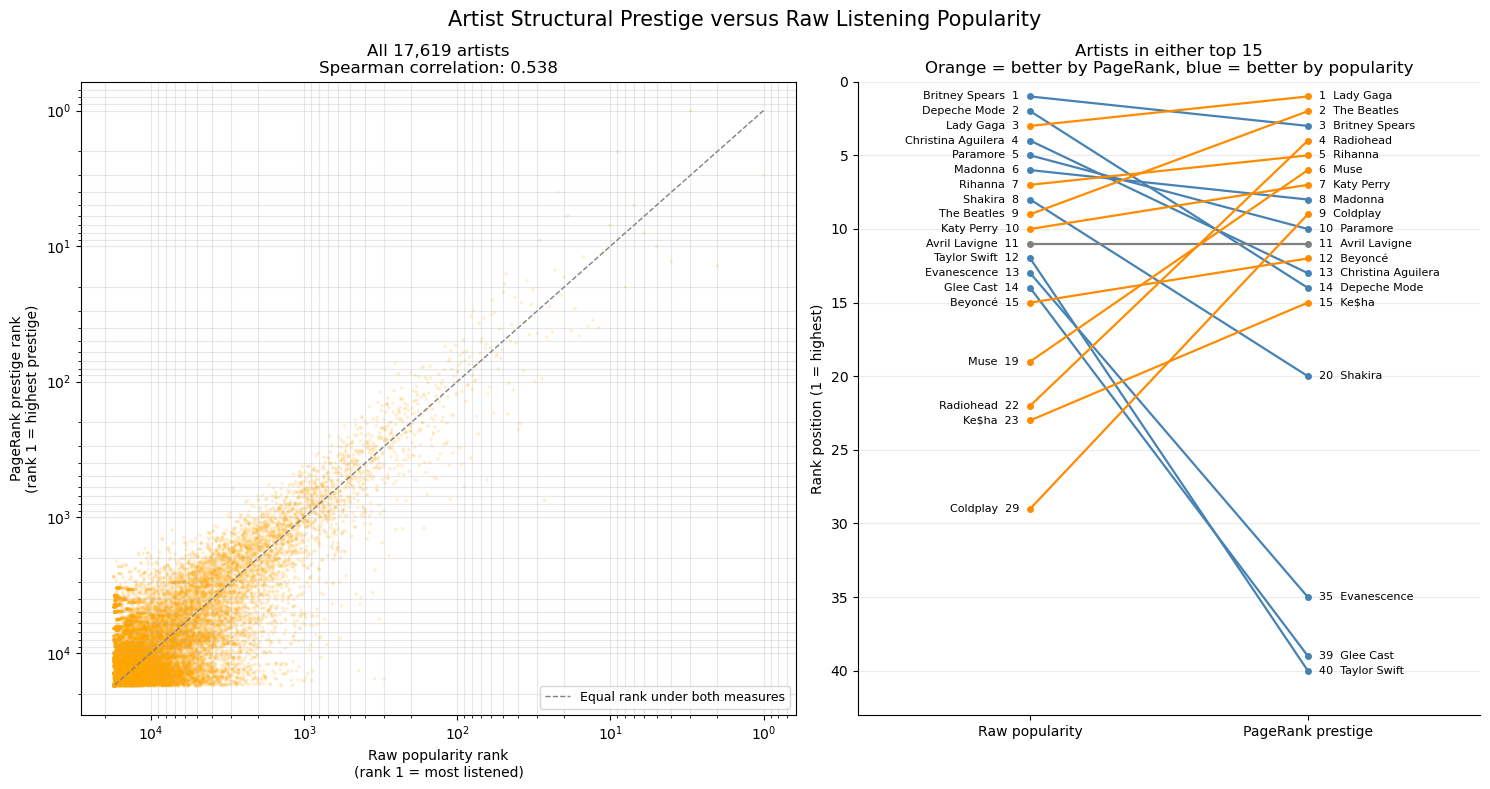


#### What the figure shows

- The scatter is broadly diagonal, which matches the Spearman correlation of
  **0.538**, but the spread around the line is wide. The two
  measures are related without being interchangeable.
- **Coldplay** gains the most from the network measure, moving
  from popularity rank **29** to PageRank
  rank **9**.
- **Taylor Swift** loses the most, moving from popularity rank
  **12** to PageRank rank
  **40**.
- **9** of the
  **19** artists shown rank better by PageRank and
  **9** rank better by raw
  popularity.


In [ ]:
md("""
### 7.2.1 Visual Comparison of Prestige and Popularity

The tables above give the exact positions. This figure shows the relationship
in two ways.

**Left panel.** Every one of the 17,619 artists, plotted by popularity rank
against PageRank rank. Both axes are logarithmic, and rank 1 is at the top
left corner. The dashed line marks equal rank. Points above the line rank
better by PageRank; points below it rank better by raw listening volume. A
tight band along the line would mean the two measures agree.

**Right panel.** The artists appearing in either top 15, drawn as a slope
chart. Popularity rank is on the left axis, PageRank rank on the right, and
each line connects one artist's two positions. Crossing lines are the finding.
""")

fig, (ax_scatter, ax_slope) = plt.subplots(
    1,
    2,
    figsize=(15, 8),
    gridspec_kw={"width_ratios": [1.15, 1]},
)

# ------------------------------------------------ left panel: all artists
ax_scatter.scatter(
    artist_scores["rank_popularity"],
    artist_scores["rank_pagerank"],
    s=6,
    alpha=0.18,
    c="orange",
    edgecolors="none",
)

rank_limit = len(artist_scores)

ax_scatter.plot(
    [1, rank_limit],
    [1, rank_limit],
    linestyle="--",
    linewidth=1.0,
    color="grey",
    label="Equal rank under both measures",
)

ax_scatter.set_xscale("log")
ax_scatter.set_yscale("log")
ax_scatter.invert_xaxis()
ax_scatter.invert_yaxis()

ax_scatter.set(
    title=(
        f"All {rank_limit:,} artists\n"
        f"Spearman correlation: {artist_spearman:.3f}"
    ),
    xlabel="Raw popularity rank\n(rank 1 = most listened)",
    ylabel="PageRank prestige rank\n(rank 1 = highest prestige)",
)

ax_scatter.grid(True, which="both", alpha=0.30)
ax_scatter.legend(loc="lower right", fontsize=9)

# ------------------------------------------------ right panel: slope chart
slope_artists = artist_divergence.sort_values("rank_popularity")

for artist_id, row in slope_artists.iterrows():
    favours_pagerank = row["rank_gap"] > 0
    favours_popularity = row["rank_gap"] < 0

    if favours_pagerank:
        line_colour = "darkorange"
    elif favours_popularity:
        line_colour = "steelblue"
    else:
        line_colour = "grey"

    ax_slope.plot(
        [0, 1],
        [row["rank_popularity"], row["rank_pagerank"]],
        color=line_colour,
        linewidth=1.6,
        marker="o",
        markersize=4,
    )

    ax_slope.annotate(
        f'{row["name"]}  {int(row["rank_popularity"])}',
        xy=(0, row["rank_popularity"]),
        xytext=(-8, 0),
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=8,
    )

    ax_slope.annotate(
        f'{int(row["rank_pagerank"])}  {row["name"]}',
        xy=(1, row["rank_pagerank"]),
        xytext=(8, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

slope_maximum = max(
    slope_artists["rank_popularity"].max(),
    slope_artists["rank_pagerank"].max(),
)

ax_slope.set_xlim(-0.62, 1.62)
ax_slope.set_ylim(slope_maximum + 3, 0)
ax_slope.set_xticks([0, 1])
ax_slope.set_xticklabels(["Raw popularity", "PageRank prestige"])
ax_slope.set_ylabel("Rank position (1 = highest)")
ax_slope.set_title(
    "Artists in either top 15\n"
    "Orange = better by PageRank, blue = better by popularity"
)
ax_slope.grid(axis="y", alpha=0.25)

for spine in ("top", "right"):
    ax_slope.spines[spine].set_visible(False)

fig.suptitle(
    "Artist Structural Prestige versus Raw Listening Popularity",
    fontsize=15,
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "artist_prestige_versus_popularity.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

gained_most = artist_divergence.nlargest(1, "rank_gap").iloc[0]
lost_most = artist_divergence.nsmallest(1, "rank_gap").iloc[0]

md(f"""
#### What the figure shows

- The scatter is broadly diagonal, which matches the Spearman correlation of
  **{artist_spearman:.3f}**, but the spread around the line is wide. The two
  measures are related without being interchangeable.
- **{gained_most["name"]}** gains the most from the network measure, moving
  from popularity rank **{int(gained_most["rank_popularity"])}** to PageRank
  rank **{int(gained_most["rank_pagerank"])}**.
- **{lost_most["name"]}** loses the most, moving from popularity rank
  **{int(lost_most["rank_popularity"])}** to PageRank rank
  **{int(lost_most["rank_pagerank"])}**.
- **{(artist_divergence["rank_gap"] > 0).sum()}** of the
  **{len(artist_divergence)}** artists shown rank better by PageRank and
  **{(artist_divergence["rank_gap"] < 0).sum()}** rank better by raw
  popularity.
""")

In [ ]:
md(f"""

## 7.3 Interpretation of Artist Prestige versus Popularity

Raw popularity and weighted PageRank have a Spearman correlation of
**{artist_spearman:.3f}** across all **{len(artist_scores):,} artists**.

This means the rankings are positively related: popular artists often
also hold important positions in the co-listening network. However, the
two methods do not produce identical results.

The top-15 lists share **{len(artist_top15_overlap)} artists**, including
Lady Gaga, The Beatles, Britney Spears, Rihanna, Katy Perry, Madonna,
Paramore, Avril Lavigne, Beyoncé, Christina Aguilera and Depeche Mode.

Lady Gaga ranks **3rd for popularity** and **1st for PageRank**.
Britney Spears ranks **1st for popularity** and **3rd for PageRank**,
while The Beatles rise from **9th to 2nd**.

Some artists perform better under raw popularity. Taylor Swift ranks
**12th for popularity** but **40th for PageRank**. Glee Cast ranks
**14th and 39th**, while Evanescence ranks **13th and 35th**.
Depeche Mode falls from **2nd for popularity** to **14th for PageRank**.

These artists have high listening totals, but their positions in the
wider co-listening network are less prominent.

Other artists perform better under PageRank. Coldplay rises from
**29th for popularity** to **9th for PageRank**, Radiohead rises from
**22nd to 4th**, and Muse rises from **19th to 6th**.

These artists may have lower total listening activity, but they share
listeners with a broad or important group of other artists.

The two measures therefore capture different ideas:

* **Raw popularity** measures total listening activity.
* **PageRank prestige** measures the artist's position and connections
  within the co-listening network.

Weighted PageRank provides information that is not available from
listening totals alone. However, this does not prove that PageRank
creates better recommendations. Its value must be tested later through
the hybrid recommender evaluation.

---
""")




## 7.3 Interpretation of Artist Prestige versus Popularity

Raw popularity and weighted PageRank have a Spearman correlation of
**0.538** across all **17,619 artists**.

This means the rankings are positively related: popular artists often
also hold important positions in the co-listening network. However, the
two methods do not produce identical results.

The top-15 lists share **11 artists**, including
Lady Gaga, The Beatles, Britney Spears, Rihanna, Katy Perry, Madonna,
Paramore, Avril Lavigne, Beyoncé, Christina Aguilera and Depeche Mode.

Lady Gaga ranks **3rd for popularity** and **1st for PageRank**.
Britney Spears ranks **1st for popularity** and **3rd for PageRank**,
while The Beatles rise from **9th to 2nd**.

Some artists perform better under raw popularity. Taylor Swift ranks
**12th for popularity** but **40th for PageRank**. Glee Cast ranks
**14th and 39th**, while Evanescence ranks **13th and 35th**.
Depeche Mode falls from **2nd for popularity** to **14th for PageRank**.

These artists have high listening totals, but their positions in the
wider co-listening network are less prominent.

Other artists perform better under PageRank. Coldplay rises from
**29th for popularity** to **9th for PageRank**, Radiohead rises from
**22nd to 4th**, and Muse rises from **19th to 6th**.

These artists may have lower total listening activity, but they share
listeners with a broad or important group of other artists.

The two measures therefore capture different ideas:

* **Raw popularity** measures total listening activity.
* **PageRank prestige** measures the artist's position and connections
  within the co-listening network.

Weighted PageRank provides information that is not available from
listening totals alone. However, this does not prove that PageRank
creates better recommendations. Its value must be tested later through
the hybrid recommender evaluation.

---


In [ ]:
md("""

## 8. Module 1 Results and Interpretation

This section brings together the main findings from Module 1, including:

the user friendship network;
the artist co-listening network;
the basic graph results;
the user centrality rankings;
the comparison of centrality measures;
the comparison of artist popularity and PageRank.

No new calculations are performed here. The purpose is to summarise what the results show and explain what cannot be concluded from the available data.
""")



## 8. Module 1 Results and Interpretation

This section brings together the main findings from Module 1, including:

the user friendship network;
the artist co-listening network;
the basic graph results;
the user centrality rankings;
the comparison of centrality measures;
the comparison of artist popularity and PageRank.

No new calculations are performed here. The purpose is to summarise what the results show and explain what cannot be concluded from the available data.


In [ ]:
md("""
### Summarising the Module 1 results

This cell creates a short table containing the main results from the user and artist network analyses.

It includes graph size, connectivity, clustering, key centrality findings and the comparison between artist popularity and PageRank.
The table is displayed and saved as a CSV file.
""")

user_giant_share = (user_graph_report["giant_component_size"]/ user_graph_report["nodes"])
artist_giant_share = (artist_graph_report["giant_component_size"]/ artist_graph_report["nodes"])
module_1_summary = pd.DataFrame([
    {"analysis": "User friendship graph","result": (f'{user_graph_report["nodes"]:,} nodes; 'f'{user_graph_report["edges"]:,} edges'),},
    {"analysis": "User connected structure","result": (f'{user_graph_report["connected_components"]} components; 'f'{user_giant_share:.1%} in largest component'),},
    {"analysis": "User average clustering","result": f'{user_graph_report["average_clustering"]:.4f}',},
    {"analysis": "Artist co-listener graph","result": (f'{artist_graph_report["nodes"]:,} nodes; 'f'{artist_graph_report["edges"]:,} edges'),},
    {"analysis": "Artist connected structure","result": (f'{artist_graph_report["connected_components"]} components; 'f'{artist_giant_share:.1%} in largest component'),},
    {"analysis": "Artist average clustering","result": f'{artist_graph_report["average_clustering"]:.4f}',},
    {"analysis": "Artists with exactly 49 connections","result": (f'{degree_49_count:,} artists; 'f'{degree_49_fraction:.1%} of all artists'),},
    {"analysis": "Strongest centrality agreement","result": ("Degree–closeness: "f'{centrality_spearman.loc["Degree", "Closeness"]:.3f}'),},
    {"analysis": "Largest top-15 centrality overlap","result": ("Betweenness–PageRank: "f'{top15_overlap.loc["Betweenness", "PageRank"]} users'),},
    {"analysis": "Consensus user candidates","result": ", ".join(map(str, consensus_user_ids)),},
    {"analysis": "Artist popularity–PageRank agreement","result": f"Spearman correlation: {artist_spearman:.3f}",},
    {"analysis": "Artist top-15 overlap","result": f"{len(artist_top15_overlap)} shared artists",},])

display(module_1_summary)
#Export Code
module_1_summary.to_csv(OUT_DIR / "module_1_summary.csv",index=False,)


### Summarising the Module 1 results

This cell creates a short table containing the main results from the user and artist network analyses.

It includes graph size, connectivity, clustering, key centrality findings and the comparison between artist popularity and PageRank.
The table is displayed and saved as a CSV file.


,analysis,result
0,User friendship graph,"1,892 nodes; 12,717 edges"
1,User connected structure,20 components; 97.4% in largest component
2,User average clustering,0.1865
3,Artist co-listener graph,"17,619 nodes; 1,319,800 edges"
4,Artist connected structure,8 components; 99.9% in largest component
5,Artist average clustering,0.7950
6,Artists with exactly 49 connections,"10,350 artists; 58.7% of all artists"
7,Strongest centrality agreement,Degree–closeness: 0.904
8,Largest top-15 centrality overlap,Betweenness–PageRank: 11 users
9,Consensus user candidates,"831, 1281, 1503, 1543"


In [ ]:
md(f"""

## 8.1 Final Module 1 Interpretation

### Graph structure

The user friendship graph contains
**{user_graph_report["nodes"]:,} users** and
**{user_graph_report["edges"]:,} friendship connections**.

It has **{user_graph_report["connected_components"]} separate groups**,
but the largest contains
**{user_graph_report["giant_component_size"]:,} users**
(**{user_giant_share:.1%} of all users**). The graph contains
**{user_graph_report["isolated_nodes"]} isolated users**.

Most users have relatively few friends, while a small number have many
connections and act as social hubs. The average clustering coefficient
is **{user_graph_report["average_clustering"]:.4f}**, showing some
tendency for a user's friends to also be friends with one another.

The artist co-listener graph contains
**{artist_graph_report["nodes"]:,} artists** and
**{artist_graph_report["edges"]:,} weighted connections**. Its largest
group contains **{artist_graph_report["giant_component_size"]:,}
artists** (**{artist_giant_share:.1%} of the graph**), with
**{artist_graph_report["isolated_nodes"]} isolated artists**.

Its average clustering coefficient is
**{artist_graph_report["average_clustering"]:.4f}**, much higher than
that of the user graph. However, this is partly caused by the way the
artist graph was created: every user's listening library connects all
artists in that library to one another.

This construction also explains the large concentration at degree 49.
Exactly **{degree_49_count:,} artists**
(**{degree_49_fraction:.1%} of all artists**) have 49 connections.
A library of 50 artists connects each artist to the other 49.

### User centrality

The four centrality measures generally agree, but they identify
different types of important users.

The strongest agreement is between degree and closeness
(**{centrality_spearman.loc["Degree", "Closeness"]:.3f}**), followed by
degree and PageRank
(**{centrality_spearman.loc["Degree", "PageRank"]:.3f}**).

However, degree differs more at the top of the rankings. It shares only
**{top15_overlap.loc["Degree", "Betweenness"]} users** with the
betweenness top 15 and
**{top15_overlap.loc["Degree", "Closeness"]} users** with the closeness
top 15.

Betweenness and PageRank have the greatest overlap, sharing
**{top15_overlap.loc["Betweenness", "PageRank"]} users**.

Four users appear in every top-15 list:

**{", ".join(map(str, consensus_user_ids))}**

These are the strongest structural tastemaker candidates. User
**1543** is the leading overall candidate, ranking first for degree,
betweenness and PageRank and second for closeness.

The differences between the rankings show that having many friends is
not the same as acting as a bridge, reaching others efficiently or
being connected to important users.

### Artist prestige versus popularity

Raw artist popularity and weighted PageRank have a Spearman correlation
of **{artist_spearman:.3f}**.

Their top-15 lists share **{len(artist_top15_overlap)} artists**. This
shows that popular artists often also hold important positions in the
co-listening network, although the rankings are not identical.

Taylor Swift, Glee Cast and Evanescence rank better by total listening
activity. Coldplay, Radiohead and Muse rank better by PageRank.

The measures therefore capture different ideas:

* **Popularity:** total listening activity.
* **Structural prestige:** importance within the co-listening network.

### Limits of the results

Centrality identifies important network positions, but it does not prove
that users influenced their friends' listening choices.

The artist graph is also strongly affected by the projection method.
Its clustering and degree patterns should not automatically be treated
as evidence of natural music communities or artist popularity.

Finally, PageRank provides information beyond raw listening totals, but
this does not prove that it improves recommendations. That must be tested
through a separate recommendation evaluation.

### Module 1 conclusion

Module 1 shows that graph analysis reveals patterns that raw counts do
not capture.

The user graph identifies direct hubs, bridge users, efficiently placed
users and users connected to other important people. The artist graph
separates listening popularity from structural co-listening prestige.

However, all results must be interpreted in relation to how the graphs
were constructed, especially the strong structural effects created by
the artist projection.

---
""")




## 8.1 Final Module 1 Interpretation

### Graph structure

The user friendship graph contains
**1,892 users** and
**12,717 friendship connections**.

It has **20 separate groups**,
but the largest contains
**1,843 users**
(**97.4% of all users**). The graph contains
**0 isolated users**.

Most users have relatively few friends, while a small number have many
connections and act as social hubs. The average clustering coefficient
is **0.1865**, showing some
tendency for a user's friends to also be friends with one another.

The artist co-listener graph contains
**17,619 artists** and
**1,319,800 weighted connections**. Its largest
group contains **17,609
artists** (**99.9% of the graph**), with
**6 isolated artists**.

Its average clustering coefficient is
**0.7950**, much higher than
that of the user graph. However, this is partly caused by the way the
artist graph was created: every user's listening library connects all
artists in that library to one another.

This construction also explains the large concentration at degree 49.
Exactly **10,350 artists**
(**58.7% of all artists**) have 49 connections.
A library of 50 artists connects each artist to the other 49.

### User centrality

The four centrality measures generally agree, but they identify
different types of important users.

The strongest agreement is between degree and closeness
(**0.904**), followed by
degree and PageRank
(**0.895**).

However, degree differs more at the top of the rankings. It shares only
**5 users** with the
betweenness top 15 and
**5 users** with the closeness
top 15.

Betweenness and PageRank have the greatest overlap, sharing
**11 users**.

Four users appear in every top-15 list:

**831, 1281, 1503, 1543**

These are the strongest structural tastemaker candidates. User
**1543** is the leading overall candidate, ranking first for degree,
betweenness and PageRank and second for closeness.

The differences between the rankings show that having many friends is
not the same as acting as a bridge, reaching others efficiently or
being connected to important users.

### Artist prestige versus popularity

Raw artist popularity and weighted PageRank have a Spearman correlation
of **0.538**.

Their top-15 lists share **11 artists**. This
shows that popular artists often also hold important positions in the
co-listening network, although the rankings are not identical.

Taylor Swift, Glee Cast and Evanescence rank better by total listening
activity. Coldplay, Radiohead and Muse rank better by PageRank.

The measures therefore capture different ideas:

* **Popularity:** total listening activity.
* **Structural prestige:** importance within the co-listening network.

### Limits of the results

Centrality identifies important network positions, but it does not prove
that users influenced their friends' listening choices.

The artist graph is also strongly affected by the projection method.
Its clustering and degree patterns should not automatically be treated
as evidence of natural music communities or artist popularity.

Finally, PageRank provides information beyond raw listening totals, but
this does not prove that it improves recommendations. That must be tested
through a separate recommendation evaluation.

### Module 1 conclusion

Module 1 shows that graph analysis reveals patterns that raw counts do
not capture.

The user graph identifies direct hubs, bridge users, efficiently placed
users and users connected to other important people. The artist graph
separates listening popularity from structural co-listening prestige.

However, all results must be interpreted in relation to how the graphs
were constructed, especially the strong structural effects created by
the artist projection.

---


In [ ]:
md("""

# Module 2 - Community Detection and Profiling

## 1. Louvain Community Detection

Louvain community detection is applied to the cleaned, undirected user friendship graph.
The aim is to find groups of users who have many friendships within their group and fewer friendships with users outside it.

Only friendship data is used to detect the communities. Listening and tag data will be added later to examine whether the social groups also
share similar musical preferences.

### 1.1 Method, reproducibility and selection rule

Louvain can produce different community results depending on the random seed used.

The algorithm is therefore tested with seeds 0–24 and 42. The partition with the highest modularity score is selected for the later
community-profile analysis. This rule is applied before examining artist or tag data, so musical preferences do not influence which partition is chosen.
The selected partition is a reproducible Louvain result, but it should not be treated as the only correct way to divide the friendship network.

The analysis uses:

* the unweighted user friendship graph;
* an undirected network;
* a Louvain resolution of **1.0**;
* NetworkX's `louvain_communities` function.
  """)




# Module 2 - Community Detection and Profiling

## 1. Louvain Community Detection

Louvain community detection is applied to the cleaned, undirected user friendship graph.
The aim is to find groups of users who have many friendships within their group and fewer friendships with users outside it.

Only friendship data is used to detect the communities. Listening and tag data will be added later to examine whether the social groups also
share similar musical preferences.

### 1.1 Method, reproducibility and selection rule

Louvain can produce different community results depending on the random seed used.

The algorithm is therefore tested with seeds 0–24 and 42. The partition with the highest modularity score is selected for the later
community-profile analysis. This rule is applied before examining artist or tag data, so musical preferences do not influence which partition is chosen.
The selected partition is a reproducible Louvain result, but it should not be treated as the only correct way to divide the friendship network.

The analysis uses:

* the unweighted user friendship graph;
* an undirected network;
* a Louvain resolution of **1.0**;
* NetworkX's `louvain_communities` function.
  

In [ ]:
md("""
### Setting up the Louvain analysis

This cell defines the Louvain settings and checks that the correct user friendship graph is being used.
The algorithm will test seeds 0–24 and 42. After all runs are complete, the partition with the highest modularity score will be selected.

The software version and settings are recorded to make the analysis easier to reproduce.
""")

LOUVAIN_RESOLUTION = 1.0
LOUVAIN_SEEDS = sorted(set(range(25)) | {RANDOM_SEED})

# Confirm that the correct graph is being analysed.
assert isinstance(G_user, nx.Graph), ("G_user is not a NetworkX graph.")
assert not G_user.is_directed(), ("Louvain requires the undirected user graph.")
assert G_user.number_of_nodes() == 1_892, ("Unexpected user count.")
assert G_user.number_of_edges() == 12_717, ("Unexpected friendship count.")

louvain_environment = pd.DataFrame({
    "setting": ["NetworkX version","Algorithm","Graph","Graph weighting","Graph direction","Resolution","Seeds tested","Selection rule",],
    "value": [nx.__version__,"networkx.community.louvain_communities","G_user","Unweighted","Undirected",LOUVAIN_RESOLUTION,len(LOUVAIN_SEEDS),"Highest modularity among tested seeds",],
})

display(louvain_environment)

md(f"""
### Louvain configuration validated

- **Users:** {G_user.number_of_nodes():,}
- **Friendship connections:** {G_user.number_of_edges():,}
- **Graph type:** unweighted and undirected
- **Resolution:** {LOUVAIN_RESOLUTION}
- **Seeds tested:** {len(LOUVAIN_SEEDS)}
- **Selection rule:** highest modularity among tested seeds
- **NetworkX version:** `{nx.__version__}`

The final community partition will be selected after all predefined seeds have been tested.
""")


### Setting up the Louvain analysis

This cell defines the Louvain settings and checks that the correct user friendship graph is being used.
The algorithm will test seeds 0–24 and 42. After all runs are complete, the partition with the highest modularity score will be selected.

The software version and settings are recorded to make the analysis easier to reproduce.


,setting,value
0,NetworkX version,3.4.2
1,Algorithm,networkx.community.louvain_communities
2,Graph,G_user
3,Graph weighting,Unweighted
4,Graph direction,Undirected
5,Resolution,1.0
6,Seeds tested,26
7,Selection rule,Highest modularity among tested seeds



### Louvain configuration validated

- **Users:** 1,892
- **Friendship connections:** 12,717
- **Graph type:** unweighted and undirected
- **Resolution:** 1.0
- **Seeds tested:** 26
- **Selection rule:** highest modularity among tested seeds
- **NetworkX version:** `3.4.2`

The final community partition will be selected after all predefined seeds have been tested.


In [ ]:
md("""
## 1.2 Testing Louvain Across Random Seeds

Louvain may divide the friendship network differently depending on its random starting point.
This cell runs the algorithm with 26 seeds and records the modularity, number and sizes of communities, and calculation time for each run.

Similar results suggest that the overall community structure is stable.
Differences show that the exact grouping of users depends partly on theselected seed.
""")

louvain_partitions = {}
result_rows = []
expected_users = set(G_user.nodes())

for seed in LOUVAIN_SEEDS:
    start = time.perf_counter()
    partition = nx.community.louvain_communities(G_user,weight=None,resolution=LOUVAIN_RESOLUTION,seed=seed,)
    modularity = nx.community.modularity(G_user,partition,weight=None,resolution=LOUVAIN_RESOLUTION,)
    sizes = sorted(map(len, partition), reverse=True)
    assert set().union(*partition) == expected_users, (f"Seed {seed} did not assign every user.")
    assert sum(sizes) == G_user.number_of_nodes(), (f"Seed {seed} produced invalid community sizes.")
    assert all(sizes), (f"Seed {seed} produced an empty community.")
    assert np.isfinite(modularity), (f"Seed {seed} produced an invalid modularity score.")

    louvain_partitions[seed] = partition

    result_rows.append({
        "seed": seed,
        "modularity": modularity,
        "community_count": len(partition),
        "largest_community": sizes[0],
        "second_largest": sizes[1],
        "third_largest": sizes[2],
        "fourth_largest": sizes[3],
        "fifth_largest": sizes[4],
        "runtime_seconds": time.perf_counter() - start,})

louvain_seed_results = pd.DataFrame(result_rows)

assert set(louvain_seed_results["seed"]) == set(LOUVAIN_SEEDS), ("Not every intended seed was tested.")
assert len(louvain_seed_results) == len(LOUVAIN_SEEDS), ("An unexpected number of runs was recorded.")

display(louvain_seed_results.sort_values(["modularity", "seed"], ascending=[False, True]).style.format({"modularity": "{:.4f}","runtime_seconds": "{:.2f}",}))


## 1.2 Testing Louvain Across Random Seeds

Louvain may divide the friendship network differently depending on its random starting point.
This cell runs the algorithm with 26 seeds and records the modularity, number and sizes of communities, and calculation time for each run.

Similar results suggest that the overall community structure is stable.
Differences show that the exact grouping of users depends partly on theselected seed.


,seed,modularity,community_count,largest_community,second_largest,third_largest,fourth_largest,fifth_largest,runtime_seconds
11,11,0.4640,31,437,386,323,280,280,0.21
2,2,0.4625,34,605,298,276,266,200,0.22
16,16,0.4621,30,373,305,279,277,274,0.19
23,23,0.4615,30,643,283,282,253,222,0.23
22,22,0.4607,30,463,399,317,290,287,0.23
9,9,0.4607,33,470,381,291,284,251,0.20
3,3,0.4603,34,581,277,270,237,203,0.27
18,18,0.4593,31,519,369,316,292,276,0.20
20,20,0.4580,29,434,287,283,278,265,0.21
10,10,0.4569,33,516,374,309,290,248,0.20


In [ ]:
md("""
### 1.2.1 Summary of the Seed-Sensitivity Test

Here we compare the Louvain results across all tested random seeds.

It checks whether the runs produce similar modularity scores and whether the number and size of communities remain consistent. Similar modularity
does not necessarily mean that users are placed in the same communities.
""")

best_result = louvain_seed_results.loc[louvain_seed_results["modularity"].idxmax()]
lowest_result = louvain_seed_results.loc[louvain_seed_results["modularity"].idxmin()]
best_seed = int(best_result["seed"])
best_modularity = float(best_result["modularity"])
lowest_seed = int(lowest_result["seed"])
lowest_modularity = float(lowest_result["modularity"])
modularity_range = best_modularity - lowest_modularity
minimum_community_count = int(louvain_seed_results["community_count"].min())
maximum_community_count = int(louvain_seed_results["community_count"].max())
minimum_largest_community = int(louvain_seed_results["largest_community"].min())
maximum_largest_community = int(louvain_seed_results["largest_community"].max())
largest_community_spread = (maximum_largest_community - minimum_largest_community)

sensitivity_summary = pd.DataFrame([
    ["Lowest modularity", f"{lowest_modularity:.4f}"],
    ["Seed with lowest modularity", lowest_seed],
    ["Highest modularity", f"{best_modularity:.4f}"],
    ["Seed with highest modularity", best_seed],
    ["Modularity range", f"{modularity_range:.4f}"],
    ["Community-count range",f"{minimum_community_count}–{maximum_community_count}",],
    ["Largest-community range",f"{minimum_largest_community:,}–{maximum_largest_community:,}",],
    ["Largest-community spread", f"{largest_community_spread:,}"],], columns=["measure", "result"])

display(sensitivity_summary)

# A double check here.
assert best_seed == 11, "Unexpected highest-modularity seed."
assert lowest_seed == 7, "Unexpected lowest-modularity seed."
assert round(best_modularity, 4) == 0.4640
assert round(lowest_modularity, 4) == 0.4423
assert round(modularity_range, 4) == 0.0217
assert (minimum_community_count,maximum_community_count,) == (29, 34)
assert (minimum_largest_community,maximum_largest_community,) == (373, 733)

md(f"""
### Interpretation of Seed Sensitivity

Across the **{len(louvain_seed_results)} tested seeds**, modularity
ranged from **{lowest_modularity:.4f}** to
**{best_modularity:.4f}**, a difference of only
**{modularity_range:.4f}**.

This suggests that the runs produced communities of similar overall
quality.

However, the number of communities ranged from
**{minimum_community_count} to {maximum_community_count}**, and the
largest community ranged from **{minimum_largest_community:,} to
{maximum_largest_community:,} users**.

The network therefore has a clear community structure, but the exact grouping of users changes with the random seed.

Seed **{best_seed}** produced the highest tested modularity score of
**{best_modularity:.4f}** and will be used for the remaining analysis.

This is the best result among the tested seeds, but it is not guaranteed to be the only correct or globally best community structure.
""")


### 1.2.1 Summary of the Seed-Sensitivity Test

Here we compare the Louvain results across all tested random seeds.

It checks whether the runs produce similar modularity scores and whether the number and size of communities remain consistent. Similar modularity
does not necessarily mean that users are placed in the same communities.


,measure,result
0,Lowest modularity,0.4423
1,Seed with lowest modularity,7
2,Highest modularity,0.4640
3,Seed with highest modularity,11
4,Modularity range,0.0217
5,Community-count range,29–34
6,Largest-community range,373–733
7,Largest-community spread,360



### Interpretation of Seed Sensitivity

Across the **26 tested seeds**, modularity
ranged from **0.4423** to
**0.4640**, a difference of only
**0.0217**.

This suggests that the runs produced communities of similar overall
quality.

However, the number of communities ranged from
**29 to 34**, and the
largest community ranged from **373 to
733 users**.

The network therefore has a clear community structure, but the exact grouping of users changes with the random seed.

Seed **11** produced the highest tested modularity score of
**0.4640** and will be used for the remaining analysis.

This is the best result among the tested seeds, but it is not guaranteed to be the only correct or globally best community structure.


In [ ]:
md("""
### 1.3 Selecting the Final Louvain Partition

We select the community result with the highest modularity among the tested seeds.
The choice is based only on the friendship network. Artist and tag data have not been examined yet.

Communities are numbered from largest to smallest. If two communities have the same size, the smallest user ID is used to determine their
order. The selected result is the best among the tested seeds, but it is not necessarily the only correct community structure.
""")

SELECTED_LOUVAIN_SEED = best_seed
selected_partition = louvain_partitions[SELECTED_LOUVAIN_SEED]

communities = sorted(selected_partition,key=lambda community: (-len(community), min(community)),)# Order communities by size
modularity_score = nx.community.modularity(G_user,communities,weight=None,resolution=LOUVAIN_RESOLUTION,)
community_count = len(communities)
selected_community_sizes = list(map(len, communities))

# Even more double checking!
assert SELECTED_LOUVAIN_SEED == 11, ("Unexpected highest-modularity seed.")
assert np.isclose(modularity_score, best_modularity), ("The selected partition does not have the highest tested modularity.")
assert round(modularity_score, 4) == 0.4640, ("Unexpected modularity score.")
assert community_count == 31, ("Unexpected number of communities.")
assert selected_community_sizes[:5] == [437, 386, 323, 280, 280], ("Unexpected sizes for the five largest communities.")

md(f"""
### Selected Louvain Result

- **Selected seed:** {SELECTED_LOUVAIN_SEED}
- **Selection rule:** highest modularity among tested seeds
- **Modularity:** {modularity_score:.4f}
- **Communities found:** {community_count}
- **Five largest community sizes:** {", ".join(
    map(str, selected_community_sizes[:5])
)}

Seed **{SELECTED_LOUVAIN_SEED}** produced the highest modularity among
the **{len(LOUVAIN_SEEDS)} tested seeds**.

The result can be reproduced using the recorded settings, but it remains one possible way of dividing the friendship network.
""")


### 1.3 Selecting the Final Louvain Partition

We select the community result with the highest modularity among the tested seeds.
The choice is based only on the friendship network. Artist and tag data have not been examined yet.

Communities are numbered from largest to smallest. If two communities have the same size, the smallest user ID is used to determine their
order. The selected result is the best among the tested seeds, but it is not necessarily the only correct community structure.



### Selected Louvain Result

- **Selected seed:** 11
- **Selection rule:** highest modularity among tested seeds
- **Modularity:** 0.4640
- **Communities found:** 31
- **Five largest community sizes:** 437, 386, 323, 280, 280

Seed **11** produced the highest modularity among
the **26 tested seeds**.

The result can be reproduced using the recorded settings, but it remains one possible way of dividing the friendship network.


In [ ]:
md("""
### 1.3.1 Validating the Selected Louvain Partition

Confirm that every user belongs to exactly one non-empty community and that the selected partition has the highest modularity among the tested seeds.
""")

expected_users = set(G_user.nodes())
assigned_users = set().union(*communities)
community_size_total = sum(selected_community_sizes)

all_users_assigned = assigned_users == expected_users
unique_assignments = community_size_total == len(assigned_users)
sizes_match_user_count = community_size_total == G_user.number_of_nodes()
communities_non_empty = all(map(len, communities))
valid_modularity = np.isfinite(modularity_score)
highest_modularity_selected = np.isclose(modularity_score,best_modularity,)

selected_partition_validation = pd.DataFrame([
    {"check": "Highest-modularity seed selected","result": SELECTED_LOUVAIN_SEED,"expected": best_seed,"passed": SELECTED_LOUVAIN_SEED == best_seed,},
    {"check": "All users assigned","result": len(assigned_users),"expected": G_user.number_of_nodes(),"passed": all_users_assigned,},
    {"check": "Each user assigned once","result": unique_assignments,"expected": True,"passed": unique_assignments,},
    {"check": "Community sizes match user count","result": community_size_total,"expected": G_user.number_of_nodes(),"passed": sizes_match_user_count,},
    {"check": "Communities are non-empty","result": communities_non_empty,"expected": True,"passed": communities_non_empty,},
    {"check": "Modularity is valid","result": round(modularity_score, 4),"expected": "Finite numerical value","passed": valid_modularity,},
    {"check": "Highest tested modularity retained","result": round(modularity_score, 4),"expected": round(best_modularity, 4),"passed": highest_modularity_selected,},
])

display(selected_partition_validation)

assert selected_partition_validation["passed"].all(), ("The selected Louvain partition failed validation.")

md(f"""
### Selected Partition Validated

All **{G_user.number_of_nodes():,} users** belong to exactly one non-empty community. The selected partition also retains the highest
modularity found among the predefined tested seeds.
""")


### 1.3.1 Validating the Selected Louvain Partition

Confirm that every user belongs to exactly one non-empty community and that the selected partition has the highest modularity among the tested seeds.


,check,result,expected,passed
0,Highest-modularity seed selected,11,11,True
1,All users assigned,1892,1892,True
2,Each user assigned once,True,True,True
3,Community sizes match user count,1892,1892,True
4,Communities are non-empty,True,True,True
5,Modularity is valid,0.464,Finite numerical value,True
6,Highest tested modularity retained,0.464,0.464,True



### Selected Partition Validated

All **1,892 users** belong to exactly one non-empty community. The selected partition also retains the highest
modularity found among the predefined tested seeds.


In [ ]:
md("""
### 1.4 Creating the User-Community Membership Table

Convert the selected Louvain communities into a table where each user
has one community ID. Community 0 is the largest community.
""")

membership = pd.DataFrame([{"userID": user_id, "community": community_id}for community_id, members in enumerate(communities)for user_id in sorted(members)])

assert len(membership) == G_user.number_of_nodes(), ("The membership table does not contain every user.")
assert membership["userID"].is_unique, ("A user was assigned to more than one community.")
assert set(membership["userID"]) == set(G_user.nodes()), ("The membership table contains missing or unexpected users.")
assert membership["community"].nunique() == community_count, ("Not every selected community is represented.")
assert membership["community"].min() == 0, ("Community numbering should begin at zero.")
assert membership["community"].max() == community_count - 1, ("Community numbering is not consecutive.")

display(membership.head(10))

#Export Code
membership.to_csv(OUT_DIR / "user_community_membership.csv",index=False,)

md(f"""
### User-Community Membership Created

- **Users assigned:** {len(membership):,}
- **Communities:** {membership["community"].nunique()}
- **Duplicate assignments:** {membership["userID"].duplicated().sum()}
- **Community ID range:** {membership["community"].min()}–{membership["community"].max()}
- **Selected seed:** {SELECTED_LOUVAIN_SEED}
- **Modularity:** {modularity_score:.4f}

Every user now has exactly one Louvain community ID.

Saved to: `{OUT_DIR / "user_community_membership.csv"}`

---
""")


### 1.4 Creating the User-Community Membership Table

Convert the selected Louvain communities into a table where each user
has one community ID. Community 0 is the largest community.


,userID,community
0,3,0
1,5,0
2,6,0
3,14,0
4,23,0
5,37,0
6,41,0
7,50,0
8,60,0
9,63,0



### User-Community Membership Created

- **Users assigned:** 1,892
- **Communities:** 31
- **Duplicate assignments:** 0
- **Community ID range:** 0–30
- **Selected seed:** 11
- **Modularity:** 0.4640

Every user now has exactly one Louvain community ID.

Saved to: `C:\Users\keno_\Downloads\BIDA\outputs_m12\user_community_membership.csv`

---


In [ ]:
md("""
## 2. Modularity and Community-Size Analysis

### 2.1 Calculating the Selected Community Sizes

Calculate how many users belong to each community, their share of all users, and the cumulative share covered by the largest communities.
""")

community_sizes = (membership.groupby("community", as_index=False).agg(users=("userID", "nunique")).sort_values(["users", "community"], ascending=[False, True]).reset_index(drop=True))
total_users = G_user.number_of_nodes()
community_sizes["user_share"] = (community_sizes["users"] / total_users)
community_sizes["cumulative_users"] = (community_sizes["users"].cumsum())
community_sizes["cumulative_share"] = (community_sizes["cumulative_users"] / total_users)
community_sizes.insert(0,"size_rank",range(1, len(community_sizes) + 1),)

assert len(community_sizes) == community_count, ("Not every community is included.")
assert community_sizes["users"].sum() == total_users, ("Community sizes do not match the total user count.")
assert community_sizes["users"].is_monotonic_decreasing, ("Communities are not ordered from largest to smallest.")
assert community_sizes.iloc[0]["community"] == 0, ("Community 0 should be the largest community.")
assert community_sizes["community"].is_unique, ("A community is missing or duplicated.")
assert np.isclose(community_sizes["user_share"].sum(), 1.0), ("Community shares do not add up to approximately 100%.")

display(community_sizes.style.format({"user_share": "{:.2%}","cumulative_share": "{:.2%}",}))
#Export Code
community_sizes.to_csv(OUT_DIR / "selected_community_sizes.csv",index=False,)

md(f"""
### Selected Community Sizes Calculated

- **Communities:** {len(community_sizes)}
- **Users represented:** {community_sizes["users"].sum():,}
- **Largest community:** {community_sizes.iloc[0]["users"]:,} users
- **Smallest community:** {community_sizes.iloc[-1]["users"]:,} users
- **Largest-community share:** {community_sizes.iloc[0]["user_share"]:.1%}
- **Five-largest-community share:** {community_sizes.head(5)["user_share"].sum():.1%}

Saved to: `{OUT_DIR / "selected_community_sizes.csv"}`
""")


## 2. Modularity and Community-Size Analysis

### 2.1 Calculating the Selected Community Sizes

Calculate how many users belong to each community, their share of all users, and the cumulative share covered by the largest communities.


,size_rank,community,users,user_share,cumulative_users,cumulative_share
0,1,0,437,23.10%,437,23.10%
1,2,1,386,20.40%,823,43.50%
2,3,2,323,17.07%,1146,60.57%
3,4,3,280,14.80%,1426,75.37%
4,5,4,280,14.80%,1706,90.17%
5,6,5,38,2.01%,1744,92.18%
6,7,6,31,1.64%,1775,93.82%
7,8,7,22,1.16%,1797,94.98%
8,9,8,21,1.11%,1818,96.09%
9,10,9,18,0.95%,1836,97.04%



### Selected Community Sizes Calculated

- **Communities:** 31
- **Users represented:** 1,892
- **Largest community:** 437.0 users
- **Smallest community:** 2.0 users
- **Largest-community share:** 23.1%
- **Five-largest-community share:** 90.2%

Saved to: `C:\Users\keno_\Downloads\BIDA\outputs_m12\selected_community_sizes.csv`



### 2.2 Visualising the Community-Size Distribution

Show the number of users in each community from largest to smallest.
A logarithmic scale is used so both the largest and smallest communities remain visible. The five largest communities are labelled.


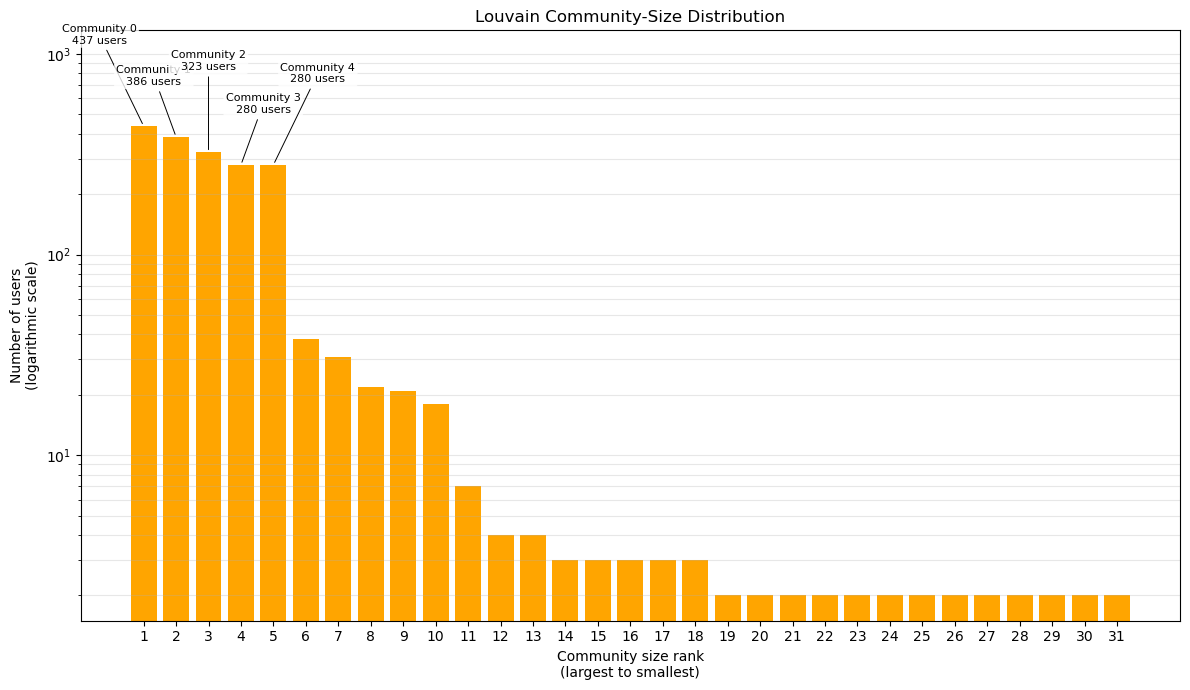

In [ ]:
md("""
### 2.2 Visualising the Community-Size Distribution

Show the number of users in each community from largest to smallest.
A logarithmic scale is used so both the largest and smallest communities remain visible. The five largest communities are labelled.
""")

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(
    community_sizes["size_rank"],
    community_sizes["users"],
    color="orange",
)

ax.set_yscale("log")
ax.set_title("Louvain Community-Size Distribution")
ax.set_xlabel("Community size rank\n(largest to smallest)")
ax.set_ylabel("Number of users\n(logarithmic scale)")
ax.set_xticks(community_sizes["size_rank"])
ax.grid(
    axis="y",
    which="both",
    alpha=0.30,
)
ax.set_ylim(1.5,community_sizes["users"].max() * 3,)
label_offsets = [
    (-32, 58),
    (-16, 36),
    (0, 58),
    (16, 36),
    (32, 58),
]

for ((_, row), (horizontal_offset, vertical_offset)) in zip(
    community_sizes.head(5).iterrows(),
    label_offsets,
):
    ax.annotate(
        f'Community {int(row["community"])}\n'
        f'{int(row["users"]):,} users',
        xy=(row["size_rank"], row["users"]),
        xytext=(horizontal_offset, vertical_offset),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        arrowprops={
            "arrowstyle": "-",
            "linewidth": 0.7,
        },
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
        },
    )

fig.tight_layout()

fig.savefig(
    OUT_DIR / "community_size_distribution.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()


### Supporting View: Cumulative Share of Users

Show how quickly the largest communities account for the full user population.
The dashed lines mark the five largest communities and 90% of users.


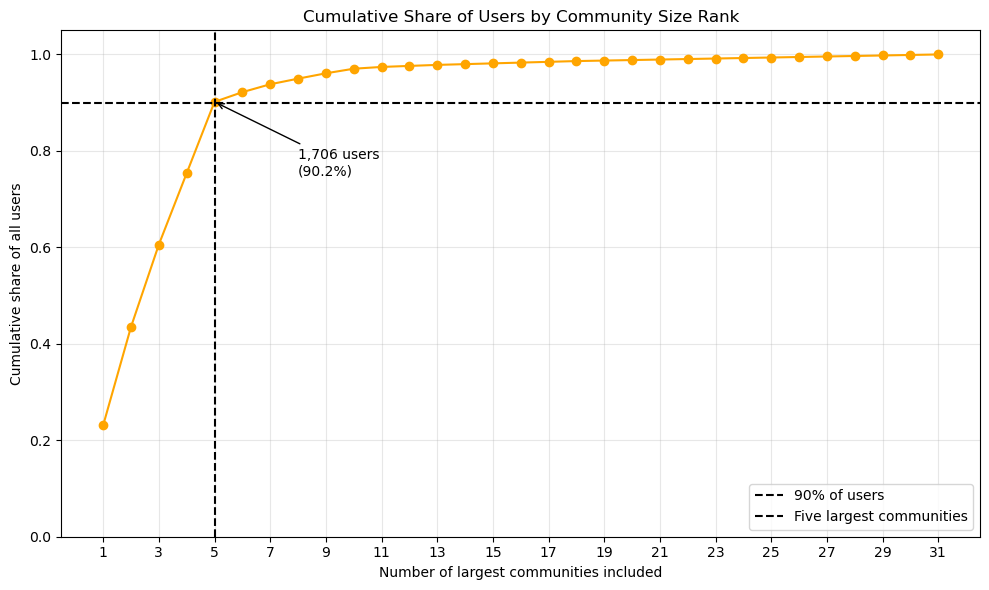

In [ ]:
md("""
### Supporting View: Cumulative Share of Users

Show how quickly the largest communities account for the full user population.
The dashed lines mark the five largest communities and 90% of users.
""")

top_five_users = community_sizes.head(5)["users"].sum()
top_five_share = community_sizes.head(5)["user_share"].sum()
rank_five_share = community_sizes.loc[community_sizes["size_rank"] == 5,"cumulative_share",].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    community_sizes["size_rank"],
    community_sizes["cumulative_share"],
    marker="o",
    color="orange",
)

ax.axhline(
    0.90,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="90% of users",
)

ax.axvline(
    5,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Five largest communities",
)

ax.annotate(
    f"{top_five_users:,} users\n({top_five_share:.1%})",
    xy=(5, rank_five_share),
    xytext=(8, 0.75),
    arrowprops={
        "arrowstyle": "->",
        "color": "black",
    },
)

ax.set(
    title="Cumulative Share of Users by Community Size Rank",
    xlabel="Number of largest communities included",
    ylabel="Cumulative share of all users",
    ylim=(0, 1.05),
    xticks=range(1, len(community_sizes) + 1, 2),
)

ax.grid(alpha=0.30)
ax.legend()
fig.tight_layout()
#Export Code
fig.savefig(OUT_DIR / "community_size_cumulative_share.png",dpi=160,bbox_inches="tight",)
plt.show()


### 2.2.1 Supporting Node-and-Edge View of the Communities

This chart shows how users and friendships are arranged across the detected communities.

- Each **dot** is one user.
- Each **line** is one friendship.
- Users with the same **colour** belong to the same community.
- Larger dots represent users with more direct friends.

The five largest communities are labelled. The dot positions are chosen only to make the network easier to see; they do not represent importance or a real-world location.


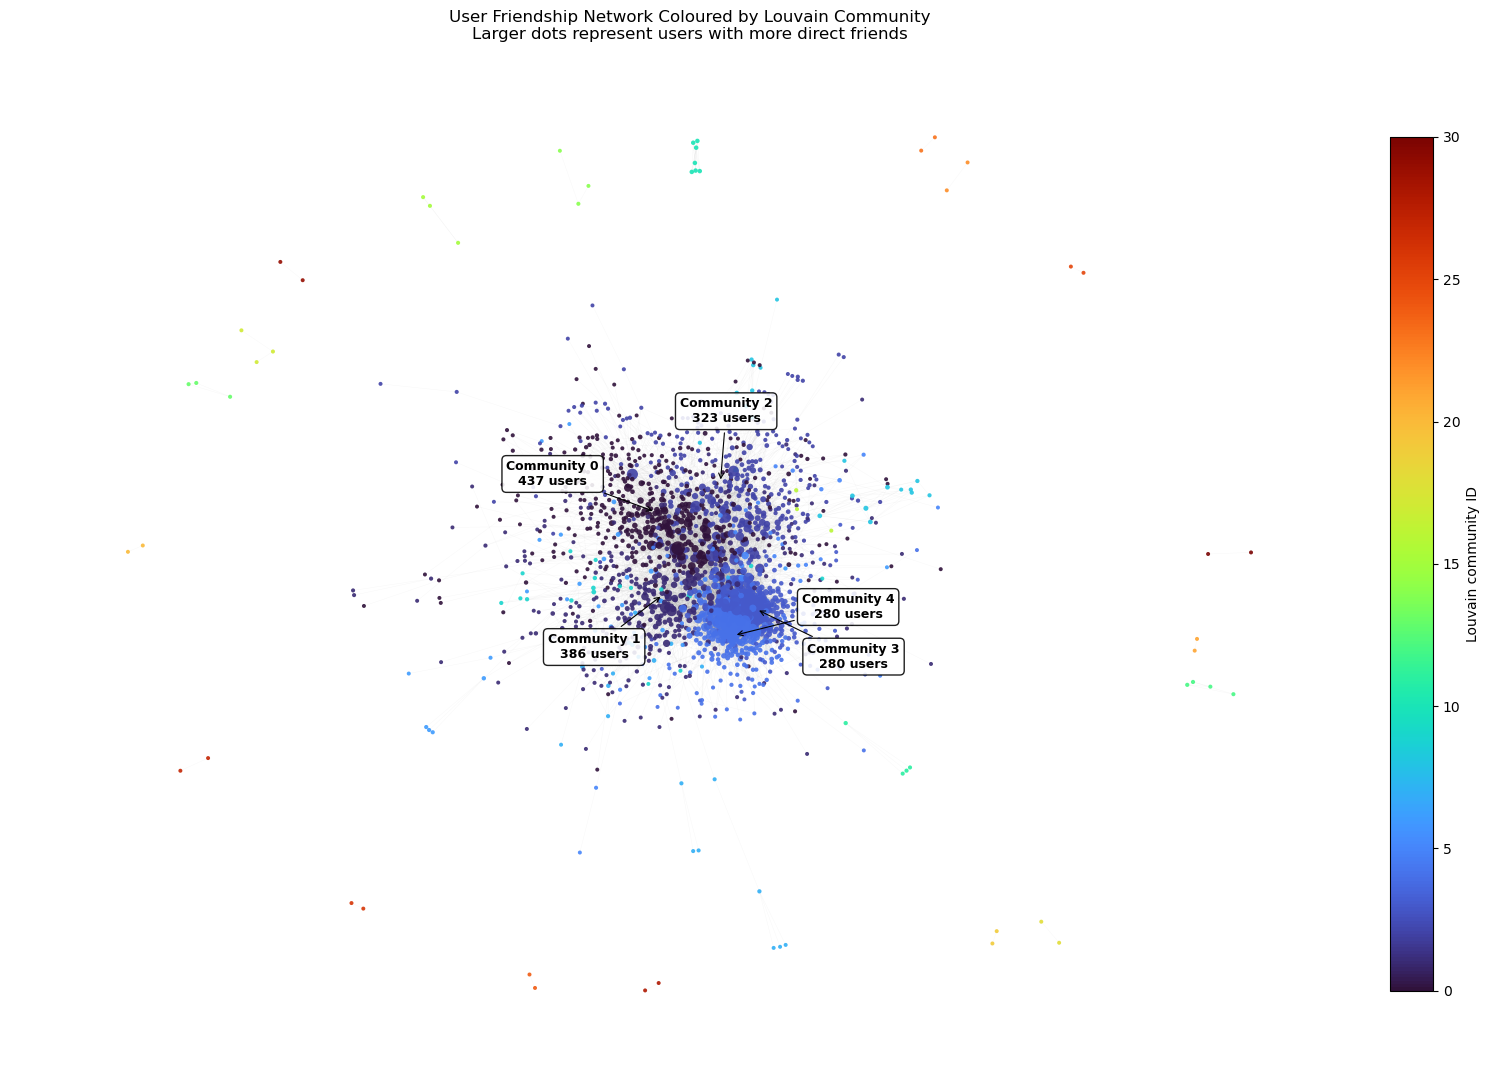


### Community Network Chart Created

- **Users shown:** 1,892
- **Friendships shown:** 12,717
- **Communities shown:** 31
- **Selected seed:** 11
- **Modularity:** 0.4640
- **Layout time:** 22.5 seconds

Users with the same colour belong to the same community, while larger dots represent users with more direct friendships.
The chart helps show the overall grouping of the network. A user's position on the page does not by itself mean that the user is more important.


In [ ]:
md("""
### 2.2.1 Supporting Node-and-Edge View of the Communities

This chart shows how users and friendships are arranged across the detected communities.

- Each **dot** is one user.
- Each **line** is one friendship.
- Users with the same **colour** belong to the same community.
- Larger dots represent users with more direct friends.

The five largest communities are labelled. The dot positions are chosen only to make the network easier to see; they do not represent importance or a real-world location.
""")

community_lookup = membership.set_index("userID")["community"].to_dict()
node_order = list(G_user.nodes())
node_colours = np.array([community_lookup[user_id]for user_id in node_order])
user_degree = dict(G_user.degree())
maximum_degree = max(user_degree.values())
node_sizes = np.array([
    8 + 90 * (user_degree[user_id] / maximum_degree) ** 1.2
    for user_id in node_order
])
start = time.perf_counter()
community_network_positions = nx.spring_layout(G_user,seed=RANDOM_SEED,k=0.08,iterations=75,)
network_layout_runtime = time.perf_counter() - start

fig, ax = plt.subplots(figsize=(15, 11))
nx.draw_networkx_edges(G_user,community_network_positions,ax=ax,edge_color="grey",width=0.35,alpha=0.055,)
nx.draw_networkx_nodes(
    G_user,
    community_network_positions,
    ax=ax,
    nodelist=node_order,
    node_size=node_sizes,
    node_color=node_colours,
    cmap=plt.cm.turbo,
    vmin=0,
    vmax=community_count - 1,
    edgecolors="none",
    alpha=0.90,
)

label_offsets = {0: (-0.18, 0.08),1: (-0.12, -0.11),2: (0.01, 0.15),3: (0.17, -0.10),4: (0.20, 0.06),}

for community_id, members in enumerate(communities[:5]):
    centre = np.mean(
        [community_network_positions[user_id] for user_id in members],
        axis=0,
    )

    offset = label_offsets[community_id]
    label_position = centre + np.array(offset)

    ax.annotate(
        f"Community {community_id}\n{len(members):,} users",
        xy=centre,
        xytext=label_position,
        textcoords="data",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 0.8,
        },
        bbox={"boxstyle": "round,pad=0.35","facecolor": "white","edgecolor": "black","alpha": 0.88,},
    )

colour_scale = plt.cm.ScalarMappable(
    cmap=plt.cm.turbo,
    norm=plt.Normalize(0, community_count - 1),
)
colour_scale.set_array([])

fig.colorbar(
    colour_scale,
    ax=ax,
    fraction=0.030,
    pad=0.015,
    label="Louvain community ID",
)

ax.set_title("User Friendship Network Coloured by Louvain Community\n""Larger dots represent users with more direct friends")

ax.axis("off")
fig.tight_layout()

fig.savefig(
    OUT_DIR / "louvain_community_network_nodes_edges.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

md(f"""
### Community Network Chart Created

- **Users shown:** {G_user.number_of_nodes():,}
- **Friendships shown:** {G_user.number_of_edges():,}
- **Communities shown:** {community_count}
- **Selected seed:** {SELECTED_LOUVAIN_SEED}
- **Modularity:** {modularity_score:.4f}
- **Layout time:** {network_layout_runtime:.1f} seconds

Users with the same colour belong to the same community, while larger dots represent users with more direct friendships.
The chart helps show the overall grouping of the network. A user's position on the page does not by itself mean that the user is more important.
""")

In [ ]:
top_five_users = int(community_sizes.head(5)["users"].sum())
top_five_share = community_sizes.head(5)["user_share"].sum()
remaining_users = G_user.number_of_nodes() - top_five_users
remaining_share = 1 - top_five_share
fifth_size = int(community_sizes.iloc[4]["users"])
sixth_size = int(community_sizes.iloc[5]["users"])

md(f"""
## 2.3 Interpretation of Modularity and Community Sizes

The Louvain method divided the friendship network into
**{community_count} communities**, with a modularity score of
**{modularity_score:.4f}**.

This positive score suggests that users generally have more friendships within their own community than with users outside it.
Most users are concentrated in five large communities:

- **Community 0:** {community_sizes.iloc[0]["users"]:,} users
  ({community_sizes.iloc[0]["user_share"]:.1%})
- **Community 1:** {community_sizes.iloc[1]["users"]:,} users
  ({community_sizes.iloc[1]["user_share"]:.1%})
- **Community 2:** {community_sizes.iloc[2]["users"]:,} users
  ({community_sizes.iloc[2]["user_share"]:.1%})
- **Community 3:** {community_sizes.iloc[3]["users"]:,} users
  ({community_sizes.iloc[3]["user_share"]:.1%})
- **Community 4:** {community_sizes.iloc[4]["users"]:,} users
  ({community_sizes.iloc[4]["user_share"]:.1%})

Together, these communities contain **{top_five_users:,} users**, or **{top_five_share:.1%} of the full network**.
Community size then falls sharply from **{fifth_size:,} users** in the fifth-largest community to **{sixth_size:,} users** in the next one.
The remaining **{community_count - 5} communities** contain only **{remaining_users:,} users** ({remaining_share:.1%}). Many contain just two or three users.

The charts therefore show a network dominated by five large social groups, followed by a long tail of much smaller groups.

Communities are not completely separate. Friendships can still exist between them; Louvain simply finds groups where friendships are more concentrated internally.

The network drawing supports this result, but the plotted positions are used only to make the graph readable. They do not represent importance or real-world distance.
At this stage, the communities describe friendship patterns only. The next sections use listening and tag data to examine whether the five largest communities also have recognisable musical preferences.

---
""")


## 2.3 Interpretation of Modularity and Community Sizes

The Louvain method divided the friendship network into
**31 communities**, with a modularity score of
**0.4640**.

This positive score suggests that users generally have more friendships within their own community than with users outside it.
Most users are concentrated in five large communities:

- **Community 0:** 437.0 users
  (23.1%)
- **Community 1:** 386.0 users
  (20.4%)
- **Community 2:** 323.0 users
  (17.1%)
- **Community 3:** 280.0 users
  (14.8%)
- **Community 4:** 280.0 users
  (14.8%)

Together, these communities contain **1,706 users**, or **90.2% of the full network**.
Community size then falls sharply from **280 users** in the fifth-largest community to **38 users** in the next one.
The remaining **26 communities** contain only **186 users** (9.8%). Many contain just two or three users.

The charts therefore show a network dominated by five large social groups, followed by a long tail of much smaller groups.

Communities are not completely separate. Friendships can still exist between them; Louvain simply finds groups where friendships are more concentrated internally.

The network drawing supports this result, but the plotted positions are used only to make the graph readable. They do not represent importance or real-world distance.
At this stage, the communities describe friendship patterns only. The next sections use listening and tag data to examine whether the five largest communities also have recognisable musical preferences.

---


In [ ]:
md("""
## 3. Artist-Based Community Profiles

### 3.1 Preparing the Five Largest Communities

This section examines the listening habits of the five largest user communities. Together, these communities contain **90.2% of all users**.
The community table is joined to the listening data so that each user-artist record includes the user's community ID.

Artists will then be compared in two ways:

1. **Community reach:** how many users in the community listened to the
   artist;
2. **Lift:** whether the artist is more common in that community than
   across the full user population.

Reach identifies widely listened-to artists. Lift helps identify artists that are especially distinctive to a community rather than simply popular everywhere.
""")

md("""
### Selecting the Five Largest Communities

Now we select the five communities with the most users.
These communities will be used for the listening-profile analysis because together they represent most of the friendship network.
""")

N_COMMUNITIES_TO_PROFILE = 5
profile_community_sizes = (community_sizes.head(N_COMMUNITIES_TO_PROFILE)[["community", "users", "user_share"]].copy())
profile_community_ids = (profile_community_sizes["community"].astype(int).tolist())

assert profile_community_ids == [0, 1, 2, 3, 4], ("The expected five largest communities were not reproduced.")
assert profile_community_sizes["users"].tolist() == [437, 386, 323, 280, 280], ("The expected community sizes were not reproduced.")
display(profile_community_sizes.style.format({"user_share": "{:.2%}",}))

md(f"""
### Communities Selected for Profiling

- **Community IDs:** {", ".join(map(str, profile_community_ids))}
- **Users included:** {profile_community_sizes["users"].sum():,}
- **Share of all users:** {profile_community_sizes["user_share"].sum():.1%}

These five communities contain most of the users in the network and will be examined using their artist-listening behaviour.
""")


## 3. Artist-Based Community Profiles

### 3.1 Preparing the Five Largest Communities

This section examines the listening habits of the five largest user communities. Together, these communities contain **90.2% of all users**.
The community table is joined to the listening data so that each user-artist record includes the user's community ID.

Artists will then be compared in two ways:

1. **Community reach:** how many users in the community listened to the
   artist;
2. **Lift:** whether the artist is more common in that community than
   across the full user population.

Reach identifies widely listened-to artists. Lift helps identify artists that are especially distinctive to a community rather than simply popular everywhere.



### Selecting the Five Largest Communities

Now we select the five communities with the most users.
These communities will be used for the listening-profile analysis because together they represent most of the friendship network.


,community,users,user_share
0,0,437,23.10%
1,1,386,20.40%
2,2,323,17.07%
3,3,280,14.80%
4,4,280,14.80%



### Communities Selected for Profiling

- **Community IDs:** 0, 1, 2, 3, 4
- **Users included:** 1,706
- **Share of all users:** 90.2%

These five communities contain most of the users in the network and will be examined using their artist-listening behaviour.


In [ ]:
md("""
### Joining Listening Records to Communities

Each listening record is matched to the community of the user who created it.
A user may have many listening records, but each user must belong to only one community. The checks confirm that no records or listening weight are lost during the merge.
""")

community_listening_all = user_artists.merge(membership,on="userID",how="left",validate="many_to_one",)

assert len(community_listening_all) == len(user_artists), ("The merge changed the number of listening records.")
assert community_listening_all["community"].notna().all(), ("Some listening records could not be assigned to a community.")
assert community_listening_all["weight"].sum() == user_artists["weight"].sum(), ("The total listening weight changed during the merge.")

community_listening_all["community"] = (community_listening_all["community"].astype(int))

md(f"""
### Community-Listening Records Created

- **Listening records retained:** {len(community_listening_all):,}
- **Listening weight retained:** {community_listening_all["weight"].sum():,.0f}
- **Unassigned records:** {community_listening_all["community"].isna().sum()}

Every listening record now includes the community ID of the user who
created it.
""")

md("""
### Creating the Five-Community Listening Dataset

Keep only the listening records belonging to the five largest communities.
The checks confirm that all five communities are included and that no users from outside those communities appear in the filtered data.
""")

community_listening = (community_listening_all.loc[community_listening_all["community"].isin(profile_community_ids)].copy())
selected_profile_users = set(membership.loc[membership["community"].isin(profile_community_ids),"userID",])

assert set(community_listening["community"].unique()) == set(profile_community_ids), ("Not all five selected communities are included.")
assert set(community_listening["userID"]).issubset(selected_profile_users), ("The data contains users outside the selected communities.")

md(f"""
### Five-Community Listening Dataset Created

- **Communities included:** {community_listening["community"].nunique()}
- **Listening records:** {len(community_listening):,}
- **Users with listening records:** {community_listening["userID"].nunique():,}
- **Artists represented:** {community_listening["artistID"].nunique():,}
- **Total listening weight:** {community_listening["weight"].sum():,.0f}

The data is now ready for comparing artist preferences across the five largest communities.
""")


### Joining Listening Records to Communities

Each listening record is matched to the community of the user who created it.
A user may have many listening records, but each user must belong to only one community. The checks confirm that no records or listening weight are lost during the merge.



### Community-Listening Records Created

- **Listening records retained:** 92,829
- **Listening weight retained:** 69,183,975
- **Unassigned records:** 0

Every listening record now includes the community ID of the user who
created it.



### Creating the Five-Community Listening Dataset

Keep only the listening records belonging to the five largest communities.
The checks confirm that all five communities are included and that no users from outside those communities appear in the filtered data.



### Five-Community Listening Dataset Created

- **Communities included:** 5
- **Listening records:** 83,734
- **Users with listening records:** 1,706
- **Artists represented:** 15,839
- **Total listening weight:** 63,815,509

The data is now ready for comparing artist preferences across the five largest communities.


In [ ]:
md("""
### Summarising Listening Activity by Community

The listening data is grouped by community to show how many users have listening records, how many artists they listened to, and the total listening activity recorded.
Average values are also calculated so communities of different sizes can be compared more fairly.
""")

community_listening_summary = (
    community_listening
    .groupby("community", as_index=False)
    .agg(users_with_listening=("userID", "nunique"),interaction_records=("artistID", "size"),unique_artists=("artistID", "nunique"),total_listening_weight=("weight", "sum"),))

community_listening_summary = (
    profile_community_sizes
    .rename(columns={"users": "community_users","user_share": "network_user_share",})
    .merge(community_listening_summary,on="community",how="left",validate="one_to_one",)
)

community_listening_summary["users_without_listening"] = (community_listening_summary["community_users"]- community_listening_summary["users_with_listening"])
community_listening_summary["average_artists_per_listening_user"] = (community_listening_summary["interaction_records"] / community_listening_summary["users_with_listening"])
community_listening_summary["average_weight_per_listening_user"] = (community_listening_summary["total_listening_weight"] / community_listening_summary["users_with_listening"])

display(community_listening_summary.style.format({"network_user_share": "{:.2%}","total_listening_weight": "{:,.0f}","average_artists_per_listening_user": "{:.2f}","average_weight_per_listening_user": "{:,.2f}",}))
# Export Code
community_listening_summary.to_csv(OUT_DIR / "community_listening_summary.csv",index=False,)


### Summarising Listening Activity by Community

The listening data is grouped by community to show how many users have listening records, how many artists they listened to, and the total listening activity recorded.
Average values are also calculated so communities of different sizes can be compared more fairly.


,community,community_users,network_user_share,users_with_listening,interaction_records,unique_artists,total_listening_weight,users_without_listening,average_artists_per_listening_user,average_weight_per_listening_user
0,0,437,23.10%,437,21537,8113,"12,065,366",0,49.28,"27,609.53"
1,1,386,20.40%,386,19143,5180,"13,627,676",0,49.59,"35,304.86"
2,2,323,17.07%,323,15711,5313,"11,202,043",0,48.64,"34,681.25"
3,3,280,14.80%,280,13509,2933,"14,473,907",0,48.25,"51,692.53"
4,4,280,14.80%,280,13834,2872,"12,446,517",0,49.41,"44,451.85"


In [ ]:
md("""
### Checking the Artist-Profile Data

These checks confirm that the five largest communities were selected correctly and joined to the listening data without losing any records or listening activity.
The analysis stops if any check fails.
""")

selected_user_count = int(profile_community_sizes["users"].sum())
retained_records = len(community_listening_all)
unassigned_records = int(community_listening_all["community"].isna().sum())
retained_weight = int(community_listening_all["weight"].sum())
represented_communities = community_listening["community"].nunique()

artist_profile_preparation_checks = pd.DataFrame([
    {"check": "Five communities selected","result": len(profile_community_ids),"expected": 5,"passed": len(profile_community_ids) == 5,},
    {"check": "Selected users","result": selected_user_count,"expected": 1_706,"passed": selected_user_count == 1_706,},
    {"check": "All listening records retained","result": retained_records,"expected": len(user_artists),"passed": retained_records == len(user_artists),},
    {"check": "No records missing a community","result": unassigned_records,"expected": 0,"passed": unassigned_records == 0,},
    {"check": "Listening weight preserved","result": retained_weight,"expected": 69_183_975,"passed": retained_weight == 69_183_975,},
    {"check": "All five communities represented","result": represented_communities,"expected": 5,"passed": represented_communities == 5,},])

display(artist_profile_preparation_checks)
assert artist_profile_preparation_checks["passed"].all(), ("The artist-profile preparation failed validation.")

md("""
### Artist-Profile Data Prepared

The five largest communities were successfully matched with the listening data. No listening records or listening weight were lost.

No conclusions about musical preferences have been made yet.

The next section will identify artists with the greatest **community reach**, meaning the artists listened to by the largest number and share of users within each community.
""")


### Checking the Artist-Profile Data

These checks confirm that the five largest communities were selected correctly and joined to the listening data without losing any records or listening activity.
The analysis stops if any check fails.


,check,result,expected,passed
0,Five communities selected,5,5,True
1,Selected users,1706,1706,True
2,All listening records retained,92829,92829,True
3,No records missing a community,0,0,True
4,Listening weight preserved,69183975,69183975,True
5,All five communities represented,5,5,True



### Artist-Profile Data Prepared

The five largest communities were successfully matched with the listening data. No listening records or listening weight were lost.

No conclusions about musical preferences have been made yet.

The next section will identify artists with the greatest **community reach**, meaning the artists listened to by the largest number and share of users within each community.


In [ ]:
md("""
### 3.2 Artists with the Greatest Community Reach

Community reach shows how widely each artist is listened to within a community.

For every artist, the analysis records:

- how many community members listened to the artist;
- what percentage of the community listened to the artist;
- the total listening activity for that artist within the community.

Artists are ranked by the percentage of community members who listened to them. Total listening weight is included as extra information but does not affect the ranking.
This identifies artists with broad appeal inside each community. It does not yet show whether an artist is unusually popular in one community compared with the full user population.
""")

md("""
### Calculating Artist Reach Within Each Community

Listening records are grouped by community and artist to measure how
widely each artist is listened to.

For every artist, the results show:

- how many different community members listened to them;
- what share of the community those listeners represent;
- the total listening activity they received.

These values will be used to identify artists with the broadest appeal
inside each community.
""")

community_size_lookup = (profile_community_sizes.set_index("community")["users"].to_dict())
community_artist_stats = (community_listening.groupby(["community", "artistID"], as_index=False).agg(community_listeners=("userID", "nunique"),total_listening_weight=("weight", "sum"),))
community_artist_stats["artist_name"] = (community_artist_stats["artistID"].map(artist_name))
community_artist_stats["community_users"] = (community_artist_stats["community"].map(community_size_lookup))
community_artist_stats["community_reach"] = (community_artist_stats["community_listeners"] / community_artist_stats["community_users"])

assert community_artist_stats["artist_name"].notna().all(), ("An artist ID could not be matched to a name.")
assert (community_artist_stats["community_listeners"] > 0).all(), ("An artist has an invalid listener count.")
assert community_artist_stats["community_reach"].between(0,1,inclusive="right",).all(), ("An artist has an invalid community reach.")
assert (community_artist_stats["total_listening_weight"] > 0).all(), ("An artist has an invalid listening weight.")

display(community_artist_stats.head())


### 3.2 Artists with the Greatest Community Reach

Community reach shows how widely each artist is listened to within a community.

For every artist, the analysis records:

- how many community members listened to the artist;
- what percentage of the community listened to the artist;
- the total listening activity for that artist within the community.

Artists are ranked by the percentage of community members who listened to them. Total listening weight is included as extra information but does not affect the ranking.
This identifies artists with broad appeal inside each community. It does not yet show whether an artist is unusually popular in one community compared with the full user population.



### Calculating Artist Reach Within Each Community

Listening records are grouped by community and artist to measure how
widely each artist is listened to.

For every artist, the results show:

- how many different community members listened to them;
- what share of the community those listeners represent;
- the total listening activity they received.

These values will be used to identify artists with the broadest appeal
inside each community.


,community,artistID,community_listeners,total_listening_weight,artist_name,community_users,community_reach
0,0,2,2,886,Diary of Dreams,437,0.004577
1,0,6,1,336,Moonspell,437,0.002288
2,0,7,24,8631,Marilyn Manson,437,0.054920
3,0,9,1,761,Combichrist,437,0.002288
4,0,10,1,267,Grendel,437,0.002288


In [ ]:
md("""
### Ranking Artists by Community Reach

Artists are ranked separately within each community according to how many community members listened to them.
A higher rank means the artist reached more people in that community.

Listening weight is used to break ties, followed by artist ID so the results remain consistent each time the code is run.

The final table keeps the top 15 artists from each community.
""")

community_artist_stats = (
    community_artist_stats
    .sort_values(
        ["community","community_listeners","total_listening_weight","artistID",],
        ascending=[True, False, False, True],).copy())

community_artist_stats["reach_rank"] = (community_artist_stats.groupby("community").cumcount().add(1))
top_artist_reach = (community_artist_stats.loc[community_artist_stats["reach_rank"] <= TOP_K].copy())

assert top_artist_reach["community"].nunique() == 5, ("Not all five communities are included.")
assert (top_artist_reach.groupby("community").size() == TOP_K).all(), ("A community does not contain exactly 15 ranked artists.")
assert top_artist_reach["reach_rank"].between(1, TOP_K).all(), ("An invalid artist reach rank was produced.")

md(f"""
### Artist Reach Rankings Created

- **Communities ranked:** {top_artist_reach["community"].nunique()}
- **Artists retained per community:** {TOP_K}
- **Total ranked rows:** {len(top_artist_reach):,}

The results now show the 15 artists listened to by the widest number of users within each selected community.
""")

md("""
### Displaying the Top Artists in Each Community

The results are shown separately for each community.

Each table lists the 15 artists listened to by the largest number of community members. The percentage shows how much of the community listened to each artist.
""")

artist_reach_display_columns = ["reach_rank","artistID","artist_name","community_listeners","community_users","community_reach","total_listening_weight",]
for community_id in profile_community_ids:
    community_user_count = community_size_lookup[community_id]

    md(f"""
#### Community {community_id} — Top 15 Artists by Reach

Community {community_id} contains **{community_user_count:,} users**.

The artists below reached the largest number of users in this community.
""")

    community_reach_table = (top_artist_reach.loc[top_artist_reach["community"] == community_id,artist_reach_display_columns,].reset_index(drop=True))
    display(community_reach_table.style.format({"community_reach": "{:.1%}","total_listening_weight": "{:,.0f}",}))


### Ranking Artists by Community Reach

Artists are ranked separately within each community according to how many community members listened to them.
A higher rank means the artist reached more people in that community.

Listening weight is used to break ties, followed by artist ID so the results remain consistent each time the code is run.

The final table keeps the top 15 artists from each community.



### Artist Reach Rankings Created

- **Communities ranked:** 5
- **Artists retained per community:** 15
- **Total ranked rows:** 75

The results now show the 15 artists listened to by the widest number of users within each selected community.



### Displaying the Top Artists in Each Community

The results are shown separately for each community.

Each table lists the 15 artists listened to by the largest number of community members. The percentage shows how much of the community listened to each artist.



#### Community 0 — Top 15 Artists by Reach

Community 0 contains **437 users**.

The artists below reached the largest number of users in this community.


,reach_rank,artistID,artist_name,community_listeners,community_users,community_reach,total_listening_weight
0,1,227,The Beatles,149,437,34.1%,"206,743"
1,2,163,Pink Floyd,120,437,27.5%,"345,303"
2,3,1412,Led Zeppelin,102,437,23.3%,"151,554"
3,4,917,Iron Maiden,100,437,22.9%,"308,533"
4,5,154,Radiohead,98,437,22.4%,"104,923"
5,6,959,Queen,91,437,20.8%,"57,970"
6,7,707,Metallica,89,437,20.4%,"263,458"
7,8,1369,Black Sabbath,82,437,18.8%,"115,633"
8,9,706,AC/DC,78,437,17.8%,"38,758"
9,10,735,The Rolling Stones,75,437,17.2%,"39,286"


...

,reach_rank,artistID,artist_name,community_listeners,community_users,community_reach,total_listening_weight
0,1,72,Depeche Mode,185,323,57.3%,"1,241,709"
1,2,159,The Cure,110,323,34.1%,"81,247"
2,3,154,Radiohead,103,323,31.9%,"77,321"
3,4,190,Muse,98,323,30.3%,"97,342"
4,5,227,The Beatles,94,323,29.1%,"99,478"
5,6,51,Duran Duran,92,323,28.5%,"301,826"
6,7,599,David Bowie,90,323,27.9%,"68,595"
7,8,59,New Order,83,323,25.7%,"58,634"
8,9,65,Coldplay,76,323,23.5%,"39,892"
9,10,511,U2,74,323,22.9%,"418,408"



#### Community 3 — Top 15 Artists by Reach

Community 3 contains **280 users**.

The artists below reached the largest number of users in this community.


,reach_rank,artistID,artist_name,community_listeners,community_users,community_reach,total_listening_weight
0,1,89,Lady Gaga,219,280,78.2%,"650,142"
1,2,289,Britney Spears,212,280,75.7%,"1,226,125"
2,3,288,Rihanna,212,280,75.7%,"504,242"
3,4,300,Katy Perry,194,280,69.3%,"287,158"
4,5,292,Christina Aguilera,186,280,66.4%,"654,431"
5,6,466,Ke$ha,170,280,60.7%,"211,429"
6,7,295,Beyoncé,155,280,55.4%,"253,637"
7,8,333,Avril Lavigne,152,280,54.3%,"287,865"
8,9,461,Miley Cyrus,148,280,52.9%,"369,164"
9,10,67,Madonna,139,280,49.6%,"488,461"



#### Community 4 — Top 15 Artists by Reach

Community 4 contains **280 users**.

The artists below reached the largest number of users in this community.


,reach_rank,artistID,artist_name,community_listeners,community_users,community_reach,total_listening_weight
0,1,289,Britney Spears,213,280,76.1%,"1,069,815"
1,2,89,Lady Gaga,208,280,74.3%,"530,002"
2,3,288,Rihanna,200,280,71.4%,"369,987"
3,4,300,Katy Perry,192,280,68.6%,"206,430"
4,5,295,Beyoncé,176,280,62.9%,"227,738"
5,6,292,Christina Aguilera,174,280,62.1%,"376,816"
6,7,333,Avril Lavigne,156,280,55.7%,"176,573"
7,8,67,Madonna,150,280,53.6%,"309,817"
8,9,701,Shakira,148,280,52.9%,"136,919"
9,10,466,Ke$ha,140,280,50.0%,"145,927"


In [ ]:
md("""
### Saving and Checking the Community-Reach Results

The full artist statistics and the top-15 rankings are saved as CSV files.

The checks confirm that all five communities contain 15 ranked artists, every artist has a name, and no reach value is greater than 100%.
""")

top_artist_reach.to_csv(OUT_DIR / "top15_artists_by_community_reach.csv",index=False,)
community_artist_stats.to_csv(OUT_DIR / "community_artist_statistics.csv",index=False,)
community_counts = top_artist_reach.groupby("community").size()
resolved_names = top_artist_reach["artist_name"].notna()
maximum_reach = top_artist_reach["community_reach"].max()

artist_reach_validation = pd.DataFrame([
    {"check": "Five communities represented","result": top_artist_reach["community"].nunique(),"expected": 5,"passed": top_artist_reach["community"].nunique() == 5,},
    {"check": "Top artists per community","result": community_counts.min(),"expected": TOP_K,"passed": (community_counts == TOP_K).all(),},
    {"check": "Artist names resolved","result": resolved_names.sum(),"expected": 5 * TOP_K,"passed": resolved_names.all(),},
    {"check": "Reach does not exceed 100%","result": maximum_reach,"expected": "At most 1.0","passed": maximum_reach <= 1,},])

display(artist_reach_validation)
assert artist_reach_validation["passed"].all(), ("The community artist-reach results failed validation.")

md(f"""
### Community-Reach Results Created

- **Communities profiled:** {top_artist_reach["community"].nunique()}
- **Artists shown per community:** {TOP_K}
- **Total ranked rows:** {len(top_artist_reach):,}

The results show which artists were listened to by the widest share of users in each community.
These artists are not necessarily unique to one community. Globally popular artists may appear near the top of several lists.

The next section uses **lift** to identify artists that are unusually common within a particular community compared with the full user population.
""")


### Saving and Checking the Community-Reach Results

The full artist statistics and the top-15 rankings are saved as CSV files.

The checks confirm that all five communities contain 15 ranked artists, every artist has a name, and no reach value is greater than 100%.


,check,result,expected,passed
0,Five communities represented,5.000000,5,True
1,Top artists per community,15.000000,15,True
2,Artist names resolved,75.000000,75,True
3,Reach does not exceed 100%,0.782143,At most 1.0,True



### Community-Reach Results Created

- **Communities profiled:** 5
- **Artists shown per community:** 15
- **Total ranked rows:** 75

The results show which artists were listened to by the widest share of users in each community.
These artists are not necessarily unique to one community. Globally popular artists may appear near the top of several lists.

The next section uses **lift** to identify artists that are unusually common within a particular community compared with the full user population.


In [ ]:
md("""
### 3.3 Identifying Distinctive Artists Using Lift

Community reach shows which artists are widely listened to, but popular artists may appear in several communities.

Lift shows whether an artist is more common in one community than across the full user population.

- **Lift above 1:** the artist is more common in the community.
- **Lift equal to 1:** the artist has similar reach inside and outside
  the community.
- **Lift below 1:** the artist is less common in the community.

Artists must reach at least **5% of the community** to be included.

This prevents artists with only one or two listeners from appearing distinctive simply because the community count is small.
""")


### 3.3 Identifying Distinctive Artists Using Lift

Community reach shows which artists are widely listened to, but popular artists may appear in several communities.

Lift shows whether an artist is more common in one community than across the full user population.

- **Lift above 1:** the artist is more common in the community.
- **Lift equal to 1:** the artist has similar reach inside and outside
  the community.
- **Lift below 1:** the artist is less common in the community.

Artists must reach at least **5% of the community** to be included.

This prevents artists with only one or two listeners from appearing distinctive simply because the community count is small.


In [ ]:
md("""
### Calculating Overall Artist Reach

Overall reach shows how widely each artist is listened to across the complete user population.

For every artist, the calculation records:

- the number of different users who listened to the artist;
- the percentage of all users who listened to the artist;
- the artist's total listening activity.

These results provide the baseline needed to decide whether an artist is unusually common within a particular community.
""")

GLOBAL_USER_COUNT = G_user.number_of_nodes()
MIN_COMMUNITY_REACH_FOR_LIFT = 0.05

global_artist_reach = (
    user_artists
    .groupby("artistID", as_index=False)
    .agg(
        global_listeners=("userID", "nunique"),
        global_total_listening_weight=("weight", "sum"),
    )
)

global_artist_reach["global_reach"] = (global_artist_reach["global_listeners"] / GLOBAL_USER_COUNT)
global_artist_reach["artist_name"] = (global_artist_reach["artistID"].map(artist_name))

assert len(global_artist_reach) == 17_619, ("The global reach table does not contain every artist.")
assert global_artist_reach["artist_name"].notna().all(), ("An artist ID could not be matched to a name.")
assert (global_artist_reach["global_listeners"] > 0).all(), ("An artist has no listeners.")
assert global_artist_reach["global_reach"].between(0,1,inclusive="right",).all(), ("An artist has an invalid global reach.")

display(global_artist_reach.head())

md(f"""
### Overall Artist Reach Calculated

- **Artists included:** {len(global_artist_reach):,}
- **Users in the full population:** {GLOBAL_USER_COUNT:,}
- **Minimum community reach for lift:** {MIN_COMMUNITY_REACH_FOR_LIFT:.0%}

The global reach values will be compared with community reach to calculate each artist's lift score.
""")

md("""
### Calculating Artist Lift

Community reach is compared with overall reach to show whether an artist is unusually common in a particular community.

The results include:

- **lift:** how many times more common the artist is in the community;
- **reach difference:** the gap between community reach and overall reach;
- **log2 lift:** another way of showing overrepresentation, where values
  above zero mean the artist is more common in the community.
""")

community_artist_lift = community_artist_stats.merge(
    global_artist_reach[["artistID","global_listeners","global_reach","global_total_listening_weight",]],on="artistID",how="left",validate="many_to_one",)

assert community_artist_lift["global_reach"].notna().all(), ("An artist has no global-reach value.")

community_artist_lift["lift"] = (community_artist_lift["community_reach"] / community_artist_lift["global_reach"])
community_artist_lift["reach_difference"] = (community_artist_lift["community_reach"] - community_artist_lift["global_reach"])
community_artist_lift["reach_percentage_point_difference"] = (community_artist_lift["reach_difference"] * 100)
community_artist_lift["log2_lift"] = np.log2(community_artist_lift["lift"])

assert np.isfinite(community_artist_lift["lift"]).all(), ("The artist-lift table contains an invalid value.")
assert (community_artist_lift["lift"] > 0).all(), ("The artist-lift table contains a non-positive value.")

md(f"""
### Artist Lift Calculated

- **Community-artist combinations:** {len(community_artist_lift):,}
- **Communities included:** {community_artist_lift["community"].nunique()}
- **Artists represented:** {community_artist_lift["artistID"].nunique():,}

A lift above **1** means an artist is more common in a community than across the full user population.
""")


### Calculating Overall Artist Reach

Overall reach shows how widely each artist is listened to across the complete user population.

For every artist, the calculation records:

- the number of different users who listened to the artist;
- the percentage of all users who listened to the artist;
- the artist's total listening activity.

These results provide the baseline needed to decide whether an artist is unusually common within a particular community.


,artistID,global_listeners,global_total_listening_weight,global_reach,artist_name
0,1,3,771,0.001586,MALICE MIZER
1,2,12,8012,0.006342,Diary of Dreams
2,3,3,775,0.001586,Carpathian Forest
3,4,2,563,0.001057,Moi dix Mois
4,5,2,913,0.001057,Bella Morte



### Overall Artist Reach Calculated

- **Artists included:** 17,619
- **Users in the full population:** 1,892
- **Minimum community reach for lift:** 5%

The global reach values will be compared with community reach to calculate each artist's lift score.



### Calculating Artist Lift

Community reach is compared with overall reach to show whether an artist is unusually common in a particular community.

The results include:

- **lift:** how many times more common the artist is in the community;
- **reach difference:** the gap between community reach and overall reach;
- **log2 lift:** another way of showing overrepresentation, where values
  above zero mean the artist is more common in the community.



### Artist Lift Calculated

- **Community-artist combinations:** 24,411
- **Communities included:** 5
- **Artists represented:** 15,839

A lift above **1** means an artist is more common in a community than across the full user population.


In [ ]:
md("""
### Ranking the Most Distinctive Artists

Only artists listened to by at least 5% of a community are considered.
This removes artists whose lift appears high because they have only one or two listeners.

Artists are then ranked by lift within each community. A higher lift means the artist is much more common in that community than across the full user population.

The 15 highest-lift artists are kept for each community.
""")

eligible_artist_lift = (community_artist_lift.loc[community_artist_lift["community_reach"]>= MIN_COMMUNITY_REACH_FOR_LIFT].copy())
eligible_artist_counts = (eligible_artist_lift.groupby("community").size().reindex(profile_community_ids, fill_value=0))

assert (eligible_artist_counts >= TOP_K).all(), ("A community has fewer than 15 eligible artists.")


eligible_artist_lift = (eligible_artist_lift.sort_values(["community","lift","community_listeners","artistID",],ascending=[True, False, False, True],).copy())# Rank by lift. Listener count and artist ID break ties consistently.
eligible_artist_lift["lift_rank"] = (eligible_artist_lift.groupby("community").cumcount().add(1))
top_distinctive_artists = (eligible_artist_lift.loc[eligible_artist_lift["lift_rank"] <= TOP_K].copy())
ranked_counts = (top_distinctive_artists.groupby("community").size().reindex(profile_community_ids, fill_value=0))

assert (ranked_counts == TOP_K).all(), ("A community does not have exactly 15 distinctive artists.")

md(f"""
### Distinctive Artist Rankings Created

- **Minimum community reach:** {MIN_COMMUNITY_REACH_FOR_LIFT:.0%}
- **Communities ranked:** {top_distinctive_artists["community"].nunique()}
- **Artists shown per community:** {TOP_K}
- **Total ranked rows:** {len(top_distinctive_artists):,}

These rankings highlight artists that are unusually common within each community, rather than artists that are simply popular across the whole network.
""")


### Ranking the Most Distinctive Artists

Only artists listened to by at least 5% of a community are considered.
This removes artists whose lift appears high because they have only one or two listeners.

Artists are then ranked by lift within each community. A higher lift means the artist is much more common in that community than across the full user population.

The 15 highest-lift artists are kept for each community.



### Distinctive Artist Rankings Created

- **Minimum community reach:** 5%
- **Communities ranked:** 5
- **Artists shown per community:** 15
- **Total ranked rows:** 75

These rankings highlight artists that are unusually common within each community, rather than artists that are simply popular across the whole network.


In [ ]:
md("""
### Displaying the Most Distinctive Artists

The results are shown separately for each community.

Only artists listened to by at least 5% of the community are included.
A higher lift means the artist is much more common in that community than across the full user population.

For example, a lift of 2 means the artist is twice as common in the community as they are across all users.
""")

artist_lift_display_columns = ["lift_rank","artistID","artist_name","community_listeners","community_reach","global_listeners","global_reach","lift","reach_percentage_point_difference","total_listening_weight",]
lift_table_format = {"community_reach": "{:.1%}","global_reach": "{:.1%}","lift": "{:.2f}","reach_percentage_point_difference": "{:+.1f}","total_listening_weight": "{:,.0f}",}
for community_id in profile_community_ids:
    md(f"""
#### Community {community_id} — Top 15 Distinctive Artists

Artists must reach at least
**{MIN_COMMUNITY_REACH_FOR_LIFT:.0%} of Community {community_id}**
to appear in this table.

The highest-ranked artists are those that are unusually common in this
community compared with the complete user population.
""")

    community_lift_table = (
        top_distinctive_artists
        .loc[
            top_distinctive_artists["community"] == community_id,
            artist_lift_display_columns,
        ]
        .reset_index(drop=True)
    )

    display(
        community_lift_table.style.format(lift_table_format)
    )


### Displaying the Most Distinctive Artists

The results are shown separately for each community.

Only artists listened to by at least 5% of the community are included.
A higher lift means the artist is much more common in that community than across the full user population.

For example, a lift of 2 means the artist is twice as common in the community as they are across all users.



#### Community 0 — Top 15 Distinctive Artists

Artists must reach at least
**5% of Community 0**
to appear in this table.

The highest-ranked artists are those that are unusually common in this
community compared with the complete user population.


,lift_rank,artistID,artist_name,community_listeners,community_reach,global_listeners,global_reach,lift,reach_percentage_point_difference,total_listening_weight
0,1,3470,Rainbow,33,7.6%,35,1.8%,4.08,+5.7,"11,021"
1,2,1366,W.A.S.P.,22,5.0%,25,1.3%,3.81,+3.7,"13,694"
2,3,2787,Whitesnake,34,7.8%,42,2.2%,3.50,+5.6,"10,993"
3,4,732,Alice Cooper,40,9.2%,51,2.7%,3.40,+6.5,"15,359"
4,5,2342,Dio,29,6.6%,38,2.0%,3.30,+4.6,"28,016"
5,6,607,Jethro Tull,29,6.6%,40,2.1%,3.14,+4.5,"18,576"
6,7,1372,Deep Purple,55,12.6%,76,4.0%,3.13,+8.6,"30,974"
7,8,2855,Cream,23,5.3%,33,1.7%,3.02,+3.5,"6,538"
8,9,1358,Judas Priest,58,13.3%,86,4.5%,2.92,+8.7,"32,592"
9,10,1369,Black Sabbath,82,18.8%,126,6.7%,2.82,+12.1,"115,633"



#### Community 1 — Top 15 Distinctive Artists

Artists must reach at least
**5% of Community 1**
to appear in this table.

The highest-ranked artists are those that are unusually common in this
community compared with the complete user population.


,lift_rank,artistID,artist_name,community_listeners,community_reach,global_listeners,global_reach,lift,reach_percentage_point_difference,total_listening_weight
0,1,823,August Burns Red,22,5.7%,25,1.3%,4.31,+4.4,"16,441"
1,2,6120,CPM 22,20,5.2%,23,1.2%,4.26,+4.0,"11,716"
2,3,932,Matanza,28,7.3%,33,1.7%,4.16,+5.5,"67,092"
3,4,4828,Forfun,20,5.2%,24,1.3%,4.08,+3.9,"17,044"
4,5,1041,Gloria,22,5.7%,27,1.4%,3.99,+4.3,"26,088"
5,6,1545,Raimundos,20,5.2%,25,1.3%,3.92,+3.9,"12,115"
6,7,705,Engenheiros do Hawaii,26,6.7%,33,1.7%,3.86,+5.0,"33,389"
7,8,2661,Anberlin,29,7.5%,37,2.0%,3.84,+5.6,"25,838"
8,9,1188,Asking Alexandria,26,6.7%,34,1.8%,3.75,+4.9,"23,429"
9,10,439,Los Hermanos,71,18.4%,95,5.0%,3.66,+13.4,"88,088"


...

,lift_rank,artistID,artist_name,community_listeners,community_reach,global_listeners,global_reach,lift,reach_percentage_point_difference,total_listening_weight
0,1,153,De/Vision,33,10.2%,33,1.7%,5.86,+8.5,"20,203"
1,2,75,Camouflage,32,9.9%,32,1.7%,5.86,+8.2,"11,768"
2,3,3768,Soft Cell,23,7.1%,23,1.2%,5.86,+5.9,"21,369"
3,4,3988,Mesh,18,5.6%,18,1.0%,5.86,+4.6,"9,928"
4,5,68,Icehouse,17,5.3%,17,0.9%,5.86,+4.4,"9,357"
5,6,1072,Martin L. Gore,41,12.7%,42,2.2%,5.72,+10.5,"39,474"
6,7,993,Simple Minds,34,10.5%,35,1.8%,5.69,+8.7,"26,639"
7,8,1061,Recoil,31,9.6%,32,1.7%,5.67,+7.9,"19,993"
8,9,1019,Yazoo,28,8.7%,29,1.5%,5.66,+7.1,"14,350"
9,10,100,ABC,18,5.6%,19,1.0%,5.55,+4.6,"6,817"



#### Community 3 — Top 15 Distinctive Artists

Artists must reach at least
**5% of Community 3**
to appear in this table.

The highest-ranked artists are those that are unusually common in this
community compared with the complete user population.


,lift_rank,artistID,artist_name,community_listeners,community_reach,global_listeners,global_reach,lift,reach_percentage_point_difference,total_listening_weight
0,1,1458,Miranda Cosgrove,25,8.9%,39,2.1%,4.33,+6.9,"8,992"
1,2,793,Hannah Montana,32,11.4%,50,2.6%,4.32,+8.8,"11,032"
2,3,797,Emily Osment,32,11.4%,51,2.7%,4.24,+8.7,"5,128"
3,4,4562,Jason Derülo,20,7.1%,32,1.7%,4.22,+5.5,"3,800"
4,5,2092,소녀시대,15,5.4%,24,1.3%,4.22,+4.1,"17,940"
5,6,1601,Anastacia,19,6.8%,31,1.6%,4.14,+5.1,"14,029"
6,7,1037,Nicki Minaj,53,18.9%,87,4.6%,4.12,+14.3,"36,287"
7,8,908,Vanessa Hudgens,45,16.1%,76,4.0%,4.00,+12.1,"24,785"
8,9,2091,4minute,14,5.0%,24,1.3%,3.94,+3.7,"9,546"
9,10,241,Toni Braxton,15,5.4%,26,1.4%,3.90,+4.0,"14,213"



#### Community 4 — Top 15 Distinctive Artists

Artists must reach at least
**5% of Community 4**
to appear in this table.

The highest-ranked artists are those that are unusually common in this
community compared with the complete user population.


,lift_rank,artistID,artist_name,community_listeners,community_reach,global_listeners,global_reach,lift,reach_percentage_point_difference,total_listening_weight
0,1,3173,Ivete Sangalo,20,7.1%,24,1.3%,5.63,+5.9,"9,375"
1,2,2548,Wanessa,21,7.5%,30,1.6%,4.73,+5.9,"86,120"
2,3,792,Thalía,17,6.1%,26,1.4%,4.42,+4.7,"341,141"
3,4,3332,Sandy e Junior,15,5.4%,23,1.2%,4.41,+4.1,"5,168"
4,5,1429,Christian Chávez,14,5.0%,22,1.2%,4.30,+3.8,"3,444"
5,6,674,Darin,16,5.7%,26,1.4%,4.16,+4.3,"12,843"
6,7,646,RBD,44,15.7%,73,3.9%,4.07,+11.9,"24,383"
7,8,790,Belinda,39,13.9%,65,3.4%,4.05,+10.5,"20,081"
8,9,802,Anahí,40,14.3%,67,3.5%,4.03,+10.7,"28,691"
9,10,530,Alphabeat,16,5.7%,27,1.4%,4.00,+4.3,"7,210"


In [ ]:
md("""
### Comparing Reach and Distinctiveness

The two top-15 lists are compared for each community:

- **Reach** highlights artists listened to by the most community members.
- **Lift** highlights artists that are unusually common in the community.

The overlap shows how many artists appear in both lists. A low overlap means the two methods give very different views of the community's
listening preferences.
""")

comparison_rows = []
for community_id in profile_community_ids:
    reach_ids = set(
        top_artist_reach.loc[
            top_artist_reach["community"] == community_id,
            "artistID",])

    lift_ids = set(
        top_distinctive_artists.loc[
            top_distinctive_artists["community"] == community_id,
            "artistID",])

    shared_count = len(reach_ids & lift_ids)

    comparison_rows.append({
        "community": community_id,
        "reach_top15_artists": len(reach_ids),
        "lift_top15_artists": len(lift_ids),
        "shared_artists": shared_count,
        "artists_replaced": TOP_K - shared_count,})

reach_lift_overlap = pd.DataFrame(comparison_rows)

assert (reach_lift_overlap[["reach_top15_artists", "lift_top15_artists"]] == TOP_K).all().all(), ("A community does not contain 15 artists in both rankings.")

display(reach_lift_overlap)

md("""
### Reach and Lift Comparison Created

**Shared artists** appear in both top-15 lists.

**Artists replaced** shows how many widely listened-to artists are replaced when the ranking focuses on artists that are distinctive to the community.
A smaller overlap means that general popularity and community distinctiveness identify substantially different artists.
""")


### Comparing Reach and Distinctiveness

The two top-15 lists are compared for each community:

- **Reach** highlights artists listened to by the most community members.
- **Lift** highlights artists that are unusually common in the community.

The overlap shows how many artists appear in both lists. A low overlap means the two methods give very different views of the community's
listening preferences.


,community,reach_top15_artists,lift_top15_artists,shared_artists,artists_replaced
0,0,15,15,2,13
1,1,15,15,1,14
2,2,15,15,0,15
3,3,15,15,0,15
4,4,15,15,0,15



### Reach and Lift Comparison Created

**Shared artists** appear in both top-15 lists.

**Artists replaced** shows how many widely listened-to artists are replaced when the ranking focuses on artists that are distinctive to the community.
A smaller overlap means that general popularity and community distinctiveness identify substantially different artists.


In [ ]:
md("""
### Saving and Checking the Lift Results

The full lift results, top-15 distinctive artist lists, and comparison with the reach rankings are saved as CSV files.

The checks confirm that all five communities have 15 ranked artists, every artist meets the 5% reach requirement, all lift values are valid,
and every artist name is available.
""")

community_artist_lift.to_csv(OUT_DIR / "community_artist_lift_all.csv",index=False,)
top_distinctive_artists.to_csv(OUT_DIR / "top15_distinctive_artists_by_lift.csv",index=False,)
reach_lift_overlap.to_csv(OUT_DIR / "artist_reach_lift_overlap.csv",index=False,)
community_counts = (top_distinctive_artists.groupby("community").size())
minimum_reach = top_distinctive_artists["community_reach"].min()
valid_lift = np.isfinite(top_distinctive_artists["lift"]).all()
resolved_names = top_distinctive_artists["artist_name"].notna()

artist_lift_validation = pd.DataFrame([
    {"check": "Five communities represented","result": top_distinctive_artists["community"].nunique(),"expected": 5,"passed": top_distinctive_artists["community"].nunique() == 5,},
    {"check": "Distinctive artists per community","result": community_counts.min(),"expected": TOP_K,"passed": (community_counts == TOP_K).all(),},
    {"check": "Minimum reach requirement met","result": minimum_reach,"expected": f"At least {MIN_COMMUNITY_REACH_FOR_LIFT:.0%}","passed": minimum_reach >= MIN_COMMUNITY_REACH_FOR_LIFT,},
    {"check": "Lift values are valid","result": valid_lift,"expected": True,"passed": valid_lift,},
    {"check": "Artist names resolved","result": resolved_names.sum(),"expected": 5 * TOP_K,"passed": resolved_names.all(),},
])

display(artist_lift_validation)

assert artist_lift_validation["passed"].all(), ("The distinctive artist analysis failed validation.")

md(f"""
### Distinctive Artist Results Validated

- **Communities profiled:** {top_distinctive_artists["community"].nunique()}
- **Artists shown per community:** {TOP_K}
- **Minimum community reach:** {MIN_COMMUNITY_REACH_FOR_LIFT:.0%}
- **Total ranked rows:** {len(top_distinctive_artists):,}

All distinctive artist rankings passed the validation checks and were saved successfully.
""")


### Saving and Checking the Lift Results

The full lift results, top-15 distinctive artist lists, and comparison with the reach rankings are saved as CSV files.

The checks confirm that all five communities have 15 ranked artists, every artist meets the 5% reach requirement, all lift values are valid,
and every artist name is available.


,check,result,expected,passed
0,Five communities represented,5,5,True
1,Distinctive artists per community,15,15,True
2,Minimum reach requirement met,0.05,At least 5%,True
3,Lift values are valid,True,True,True
4,Artist names resolved,75,75,True



### Distinctive Artist Results Validated

- **Communities profiled:** 5
- **Artists shown per community:** 15
- **Minimum community reach:** 5%
- **Total ranked rows:** 75

All distinctive artist rankings passed the validation checks and were saved successfully.



### 3.3.1 Visual Comparison of the Most Distinctive Artists

This figure shows the five highest-lift artists in each of the five profiled
communities.

- Each panel is one community, labelled with its user count.
- Bar length is lift: how many times more common that artist is inside the
  community than across all 1,892 users.
- The dashed line at lift 1 marks the point where an artist is no more common
  in the community than in the network as a whole.
- All panels share the same horizontal scale, so bars can be compared directly
  between communities.

Every artist shown reaches at least 5% of its community, so no bar is produced
by a one- or two-listener artist.

One artist name is shown in Latin script for display only. The exported data
files keep the original name.


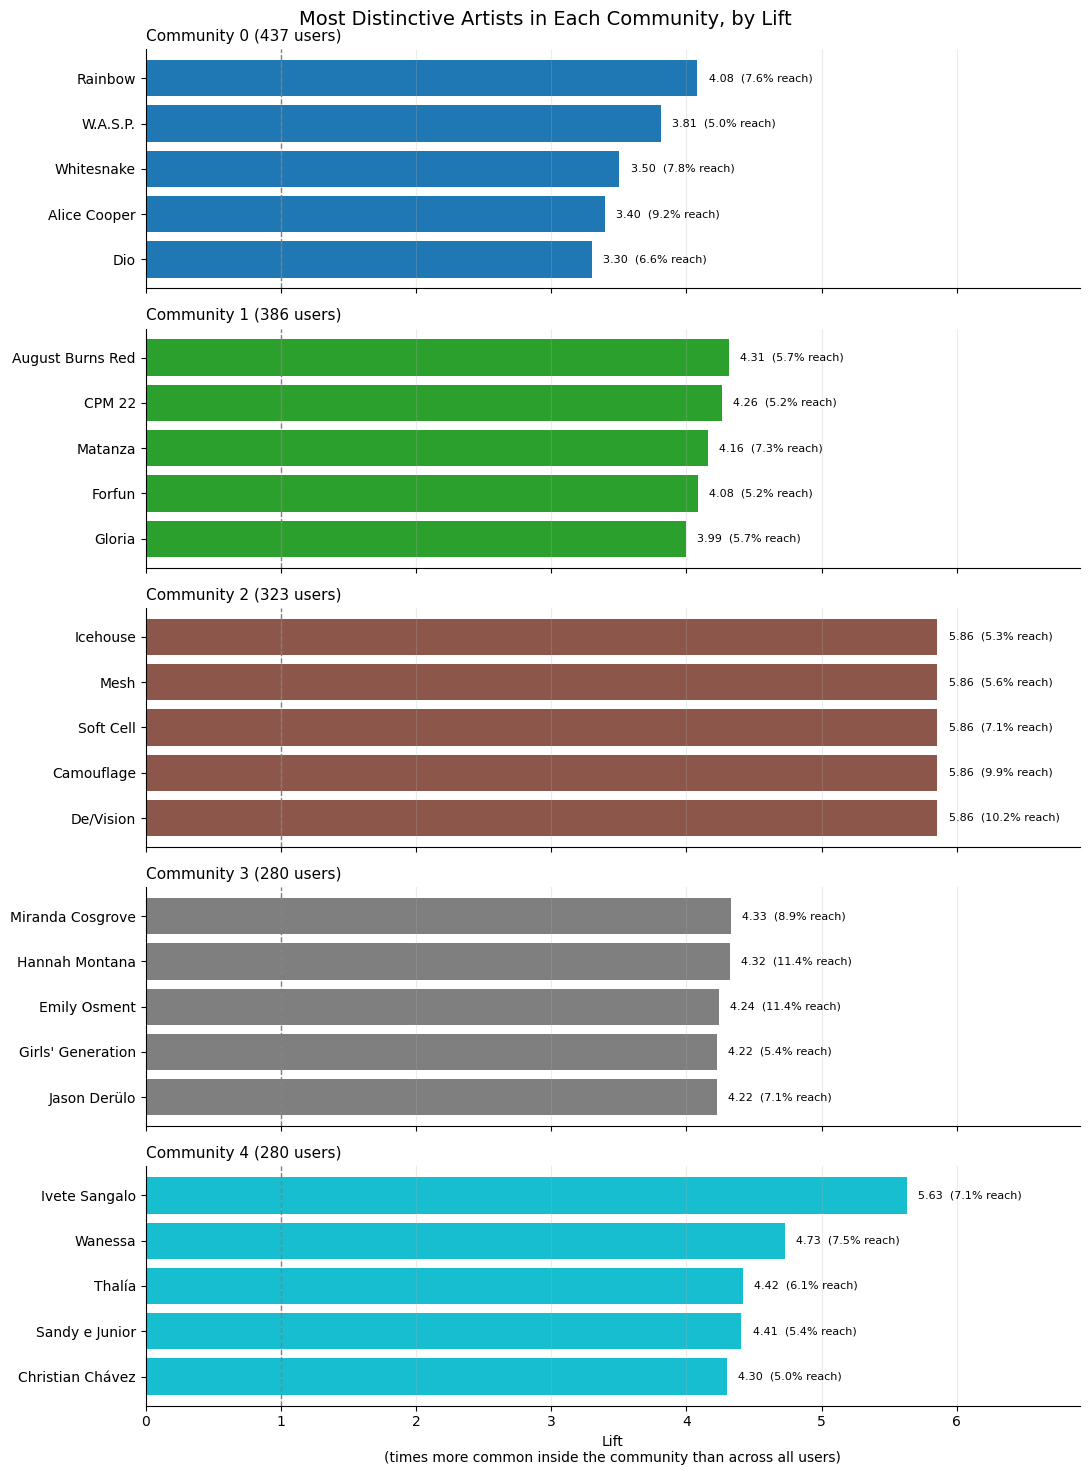


#### What the figure shows

- **Artists shown per community:** 5
- **Highest lift in the figure:** 5.86
- **Lowest lift in the figure:** 3.30
- **Shared artists across any two panels:**
  0

The leading artist in each community is:

- **Community 0:** Rainbow (4.08 lift)
- **Community 1:** August Burns Red (4.31 lift)
- **Community 2:** De/Vision (5.86 lift)
- **Community 3:** Miranda Cosgrove (4.33 lift)
- **Community 4:** Ivete Sangalo (5.63 lift)

Every bar sits well above the dashed line at 1, so each of these artists is
substantially overrepresented in its community rather than merely present.


In [ ]:
md("""
### 3.3.1 Visual Comparison of the Most Distinctive Artists

This figure shows the five highest-lift artists in each of the five profiled
communities.

- Each panel is one community, labelled with its user count.
- Bar length is lift: how many times more common that artist is inside the
  community than across all 1,892 users.
- The dashed line at lift 1 marks the point where an artist is no more common
  in the community than in the network as a whole.
- All panels share the same horizontal scale, so bars can be compared directly
  between communities.

Every artist shown reaches at least 5% of its community, so no bar is produced
by a one- or two-listener artist.

One artist name is shown in Latin script for display only. The exported data
files keep the original name.
""")

ARTISTS_PER_PANEL = 5

panel_artists = (
    top_distinctive_artists.loc[top_distinctive_artists["lift_rank"] <= ARTISTS_PER_PANEL]
    .copy()
)

# Matplotlib's default font has no glyphs for non-Latin scripts, so those names
# would draw as empty boxes. Aliases affect this figure only; the exported CSV
# files keep the original artist names.
FIGURE_ARTIST_LABELS = {
    "\uc18c\ub140\uc2dc\ub300": "Girls' Generation",
}

panel_artists["artist_name"] = (
    panel_artists["artist_name"].replace(FIGURE_ARTIST_LABELS)
)


def renders_in_default_font(label):
    """Conservative check: Latin-1 is safely covered by the default font."""
    try:
        str(label).encode("latin-1")
        return True
    except UnicodeEncodeError:
        return False


unrenderable_labels = sorted(
    label
    for label in panel_artists["artist_name"].unique()
    if not renders_in_default_font(label)
)

if unrenderable_labels:
    print(
        "Names that may not render in the figure, add them to "
        f"FIGURE_ARTIST_LABELS: {unrenderable_labels}"
    )

community_user_counts = (
    community_sizes.set_index("community")["users"].to_dict()
)

panel_colours = plt.cm.tab10(np.linspace(0, 1, len(profile_community_ids)))

fig, axes = plt.subplots(
    len(profile_community_ids),
    1,
    figsize=(11, 3.0 * len(profile_community_ids)),
    sharex=True,
)

lift_limit = panel_artists["lift"].max() * 1.18

for axis, community_id, panel_colour in zip(
    np.atleast_1d(axes),
    profile_community_ids,
    panel_colours,
):
    community_panel = (
        panel_artists.loc[panel_artists["community"] == community_id]
        .sort_values("lift", ascending=True)
    )

    bar_positions = np.arange(len(community_panel))

    axis.barh(
        bar_positions,
        community_panel["lift"],
        color=panel_colour,
        edgecolor="none",
    )

    axis.set_yticks(bar_positions)
    axis.set_yticklabels(community_panel["artist_name"])

    for position, (_, row) in zip(bar_positions, community_panel.iterrows()):
        axis.text(
            row["lift"] + lift_limit * 0.012,
            position,
            f'{row["lift"]:.2f}  ({row["community_reach"]:.1%} reach)',
            va="center",
            fontsize=8,
        )

    axis.axvline(
        1.0,
        linestyle="--",
        linewidth=1.0,
        color="grey",
    )

    axis.set_xlim(0, lift_limit)
    axis.set_title(
        f"Community {int(community_id)} "
        f"({int(community_user_counts[community_id]):,} users)",
        loc="left",
        fontsize=11,
    )
    axis.grid(axis="x", alpha=0.25)

    for spine in ("top", "right"):
        axis.spines[spine].set_visible(False)

np.atleast_1d(axes)[-1].set_xlabel(
    "Lift\n(times more common inside the community than across all users)"
)

fig.suptitle(
    "Most Distinctive Artists in Each Community, by Lift",
    fontsize=14,
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "community_top_distinctive_artists.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

panel_leaders = (
    panel_artists.loc[panel_artists["lift_rank"] == 1]
    .set_index("community")
)

md(f"""
#### What the figure shows

- **Artists shown per community:** {ARTISTS_PER_PANEL}
- **Highest lift in the figure:** {panel_artists["lift"].max():.2f}
- **Lowest lift in the figure:** {panel_artists["lift"].min():.2f}
- **Shared artists across any two panels:**
  {ARTISTS_PER_PANEL * len(profile_community_ids) - panel_artists["artistID"].nunique()}

The leading artist in each community is:

{chr(10).join(
    f'- **Community {int(community_id)}:** '
    f'{panel_leaders.loc[community_id, "artist_name"]} '
    f'({panel_leaders.loc[community_id, "lift"]:.2f} lift)'
    for community_id in profile_community_ids
)}

Every bar sits well above the dashed line at 1, so each of these artists is
substantially overrepresented in its community rather than merely present.
""")

In [ ]:
md("""
### 3.4  Interpretation of the Artist-Based Community Profiles

The reach and lift rankings describe different aspects of listening.

**Reach** identifies artists listened to by many users in a community.
Because globally popular artists often appear in several communities,
reach does not always show what makes a community distinctive.

**Lift** compares an artist's popularity inside a community with their
popularity across all users. A high lift means the artist is unusually
common in that community.

The two rankings have little overlap:

- **Community 0:** 2 shared artists
- **Community 1:** 1 shared artist
- **Communities 2, 3 and 4:** no shared artists

This shows that the most widely heard artists are usually different from
the artists that best define each community.

#### Community 0: Classic rock and heavy metal

The reach list includes The Beatles, Pink Floyd, Led Zeppelin, Metallica
and Black Sabbath.

The lift list gives a clearer hard-rock and heavy-metal identity, with
Rainbow, W.A.S.P., Whitesnake, Dio, Deep Purple and Judas Priest.

Rainbow has the highest lift at **4.08**, reaching **7.6%** of the
community compared with **1.8%** of all users.

#### Community 1: Metalcore, pop-punk and Brazilian rock

The reach list includes Paramore, Arctic Monkeys, Linkin Park, Green Day
and blink-182.

The lift list is more specialised, including August Burns Red, Asking
Alexandria, A Day to Remember and The Devil Wears Prada.

Brazilian rock artists such as CPM 22, Matanza and Raimundos also appear.
August Burns Red has the highest lift at **4.31**.

This pattern may reflect both musical taste and language or geographic
connections.

#### Community 2: Synth-pop, new wave and electronic alternative

The reach list is led by Depeche Mode and includes The Cure, Duran Duran,
New Order and Pet Shop Boys.

The lift list contains De/Vision, Camouflage, Soft Cell, Mesh, Yazoo,
Gary Numan and Ultravox.

Several artists have a lift of about **5.86**, meaning all their recorded
listeners belong to Community 2.

This is the clearest and most consistent musical profile.

#### Community 3: Youth-oriented female pop and R&B

The reach list is dominated by Lady Gaga, Britney Spears, Rihanna and
Katy Perry.

The lift list is more specific, including Miranda Cosgrove, Hannah
Montana, Emily Osment, Vanessa Hudgens and Leighton Meester.

Nicki Minaj, Toni Braxton and Sugababes add a female pop and R&B element,
while Girls' Generation and 4minute add K-pop.

Miranda Cosgrove has the highest lift at **4.33**.

#### Community 4: Latin-American and Brazilian pop

The reach list also contains global pop artists such as Britney Spears,
Lady Gaga, Rihanna and Katy Perry.

The lift list separates this community from Community 3. It includes
Ivete Sangalo, Wanessa, Thalía, Sandy e Junior, RBD, Belinda and
Ricky Martin.

Ivete Sangalo has the highest lift at **5.63**. Westlife, Jessie J and
David Archuleta add an international teen-pop element.

### Artist-Profile Conclusion

The artist results suggest that friendship communities are linked to
different listening preferences.

The provisional community identities are:

- **Community 0:** classic rock and heavy metal
- **Community 1:** metalcore, pop-punk and Brazilian rock
- **Community 2:** synth-pop, new wave and electronic alternative
- **Community 3:** youth-oriented female pop and R&B
- **Community 4:** Latin-American and Brazilian pop

These labels are provisional. Artist patterns may also reflect language,
location, age or other social factors.

The tag analysis will now be used to check whether it supports or
challenges these interpretations.
""")


### 3.4  Interpretation of the Artist-Based Community Profiles

The reach and lift rankings describe different aspects of listening.

**Reach** identifies artists listened to by many users in a community.
Because globally popular artists often appear in several communities,
reach does not always show what makes a community distinctive.

**Lift** compares an artist's popularity inside a community with their
popularity across all users. A high lift means the artist is unusually
common in that community.

The two rankings have little overlap:

- **Community 0:** 2 shared artists
- **Community 1:** 1 shared artist
- **Communities 2, 3 and 4:** no shared artists

This shows that the most widely heard artists are usually different from
the artists that best define each community.

#### Community 0: Classic rock and heavy metal

The reach list includes The Beatles, Pink Floyd, Led Zeppelin, Metallica
and Black Sabbath.

The lift list gives a clearer hard-rock and heavy-metal identity, with
Rainbow, W.A.S.P., Whitesnake, Dio, Deep Purple and Judas Priest.

Rainbow has the highest lift at **4.08**, reaching **7.6%** of the
community compared with **1.8%** of all users.

#### Community 1: Metalcore, pop-punk and Brazilian rock

The reach list includes Paramore, Arctic Monkeys, Linkin Park, Green Day
and blink-182.

The lift list is more specialised, including August Burns Red, Asking
Alexandria, A Day to Remember and The Devil Wears Prada.

Brazilian rock artists such as CPM 22, Matanza and Raimundos also appear.
August Burns Red has the highest lift at **4.31**.

This pattern may reflect both musical taste and language or geographic
connections.

#### Community 2: Synth-pop, new wave and electronic alternative

The reach list is led by Depeche Mode and includes The Cure, Duran Duran,
New Order and Pet Shop Boys.

The lift list contains De/Vision, Camouflage, Soft Cell, Mesh, Yazoo,
Gary Numan and Ultravox.

Several artists have a lift of about **5.86**, meaning all their recorded
listeners belong to Community 2.

This is the clearest and most consistent musical profile.

#### Community 3: Youth-oriented female pop and R&B

The reach list is dominated by Lady Gaga, Britney Spears, Rihanna and
Katy Perry.

The lift list is more specific, including Miranda Cosgrove, Hannah
Montana, Emily Osment, Vanessa Hudgens and Leighton Meester.

Nicki Minaj, Toni Braxton and Sugababes add a female pop and R&B element,
while Girls' Generation and 4minute add K-pop.

Miranda Cosgrove has the highest lift at **4.33**.

#### Community 4: Latin-American and Brazilian pop

The reach list also contains global pop artists such as Britney Spears,
Lady Gaga, Rihanna and Katy Perry.

The lift list separates this community from Community 3. It includes
Ivete Sangalo, Wanessa, Thalía, Sandy e Junior, RBD, Belinda and
Ricky Martin.

Ivete Sangalo has the highest lift at **5.63**. Westlife, Jessie J and
David Archuleta add an international teen-pop element.

### Artist-Profile Conclusion

The artist results suggest that friendship communities are linked to
different listening preferences.

The provisional community identities are:

- **Community 0:** classic rock and heavy metal
- **Community 1:** metalcore, pop-punk and Brazilian rock
- **Community 2:** synth-pop, new wave and electronic alternative
- **Community 3:** youth-oriented female pop and R&B
- **Community 4:** Latin-American and Brazilian pop

These labels are provisional. Artist patterns may also reflect language,
location, age or other social factors.

The tag analysis will now be used to check whether it supports or
challenges these interpretations.


In [ ]:
md("""
## 4. Tag-Based Community Profiles

### 4.1  Preparing the Cleaned Tag Records

Artist profiles show which performers are common within each friendship community. Tag profiles provide another view by showing the words users
used to describe those artists, such as genres, styles and musical features.

Only tags approved during the earlier data-cleaning stage are included.
This removes spelling variations, duplicate labels, personal comments, artist names and other unclear or noisy tags.

The analysis focuses on the five largest communities, which together contain **90.2% of all users**.
""")

md("""
### Joining Tag Records to User Communities

Each cleaned tag record is matched to the community of the user who created it.

A user may have many tag records, but each user must belong to only one community. The checks confirm that no tag records are lost and that every record receives a community ID.
""")

community_tag_votes_all = votes.merge(membership,on="userID",how="left",validate="many_to_one",)

assert len(community_tag_votes_all) == len(votes), ("The merge changed the number of cleaned tag records.")
assert community_tag_votes_all["community"].notna().all(), ("Some tag records could not be assigned to a community.")
community_tag_votes_all["community"] = (community_tag_votes_all["community"].astype(int))

md(f"""
### Community-Tag Records Created

- **Tag records retained:** {len(community_tag_votes_all):,}
- **Users represented:** {community_tag_votes_all["userID"].nunique():,}
- **Communities represented:** {community_tag_votes_all["community"].nunique()}
- **Unassigned records:** {community_tag_votes_all["community"].isna().sum()}

Every cleaned tag record now includes the community ID of the user who created it.
""")

md("""
### Applying the Community-Profile Eligibility Flag

Only tag records approved during the earlier human review are kept for the community profiles.

The eligibility field may be stored as true/false values or as text such as "yes" or "1", so both formats are handled. Records with missing or
blank cleaned tag names are rejected.
""")

profile_flags = community_tag_votes_all["use_for_community_profile"]

if pd.api.types.is_bool_dtype(profile_flags):
    eligible_mask = profile_flags.fillna(False)
else:
    eligible_mask = (profile_flags.astype(str).str.strip().str.lower().isin({"true", "1", "yes"}))

eligible_tag_votes_all = (community_tag_votes_all.loc[eligible_mask].copy())

assert not eligible_tag_votes_all.empty, ("No tag records were approved for community profiling.")

for column in ["canonical_key", "canonical_tag"]:
    assert eligible_tag_votes_all[column].notna().all(), (f"An eligible tag record has no {column}.")
    assert eligible_tag_votes_all[column].astype(str).str.strip().ne("").all(), (f"An eligible tag record has a blank {column}.")

excluded_records = (len(community_tag_votes_all) - len(eligible_tag_votes_all))

md(f"""
### Eligible Tag Records Retained

- **All cleaned tag records:** {len(community_tag_votes_all):,}
- **Eligible records:** {len(eligible_tag_votes_all):,}
- **Excluded records:** {excluded_records:,}
- **Unique approved tags:** {eligible_tag_votes_all["canonical_key"].nunique():,}
- **Users with approved tags:** {eligible_tag_votes_all["userID"].nunique():,}

Only approved, meaningful tags will be used to describe the musical preferences of the communities.
""")


## 4. Tag-Based Community Profiles

### 4.1  Preparing the Cleaned Tag Records

Artist profiles show which performers are common within each friendship community. Tag profiles provide another view by showing the words users
used to describe those artists, such as genres, styles and musical features.

Only tags approved during the earlier data-cleaning stage are included.
This removes spelling variations, duplicate labels, personal comments, artist names and other unclear or noisy tags.

The analysis focuses on the five largest communities, which together contain **90.2% of all users**.



### Joining Tag Records to User Communities

Each cleaned tag record is matched to the community of the user who created it.

A user may have many tag records, but each user must belong to only one community. The checks confirm that no tag records are lost and that every record receives a community ID.



### Community-Tag Records Created

- **Tag records retained:** 184,146
- **Users represented:** 1,891
- **Communities represented:** 31
- **Unassigned records:** 0

Every cleaned tag record now includes the community ID of the user who created it.



### Applying the Community-Profile Eligibility Flag

Only tag records approved during the earlier human review are kept for the community profiles.

The eligibility field may be stored as true/false values or as text such as "yes" or "1", so both formats are handled. Records with missing or
blank cleaned tag names are rejected.



### Eligible Tag Records Retained

- **All cleaned tag records:** 184,146
- **Eligible records:** 157,751
- **Excluded records:** 26,395
- **Unique approved tags:** 7,452
- **Users with approved tags:** 1,857

Only approved, meaningful tags will be used to describe the musical preferences of the communities.


In [ ]:
md("""
### Creating the Five-Community Tag Dataset

Keep only the approved tag records created by users in the five largest communities.
The checks confirm that all five communities are included and that no users from outside those communities appear in the filtered data.
""")

community_tag_votes = (eligible_tag_votes_all.loc[eligible_tag_votes_all["community"].isin(profile_community_ids)].copy())

selected_profile_users = set(membership.loc[membership["community"].isin(profile_community_ids),"userID",])

assert set(community_tag_votes["community"].unique()) == set(profile_community_ids), ("Not all five selected communities are included.")
assert set(community_tag_votes["userID"]).issubset(selected_profile_users), ("The tag data contains users outside the selected communities.")

md(f"""
### Five-Community Tag Dataset Created

- **Communities included:** {community_tag_votes["community"].nunique()}
- **Approved tag records:** {len(community_tag_votes):,}
- **Users represented:** {community_tag_votes["userID"].nunique():,}
- **Artists tagged:** {community_tag_votes["artistID"].nunique():,}
- **Unique approved tags:** {community_tag_votes["canonical_key"].nunique():,}

The tag data is now ready for comparing the musical descriptions used within the five largest communities.
""")


### Creating the Five-Community Tag Dataset

Keep only the approved tag records created by users in the five largest communities.
The checks confirm that all five communities are included and that no users from outside those communities appear in the filtered data.



### Five-Community Tag Dataset Created

- **Communities included:** 5
- **Approved tag records:** 146,724
- **Users represented:** 1,676
- **Artists tagged:** 11,394
- **Unique approved tags:** 6,900

The tag data is now ready for comparing the musical descriptions used within the five largest communities.


In [ ]:
md("""
### Creating Unique User-Tag Records

Each user should count only once for each tag.

For example, someone who uses the tag `rock` on ten different artists still counts as one user associated with `rock`.
Removing repeated user-tag combinations prevents very active taggers from having too much influence on the community results.
""")

community_user_tags = (community_tag_votes[["community", "userID", "canonical_key", "canonical_tag"]].drop_duplicates(["community", "userID", "canonical_key"]).copy())
global_user_tags = (eligible_tag_votes_all[["userID", "canonical_key", "canonical_tag"]].drop_duplicates(["userID", "canonical_key"]).copy())

assert not community_user_tags.duplicated(["community", "userID", "canonical_key"]).any(), ("Duplicate community user-tag pairs remain.")
assert not global_user_tags.duplicated(["userID", "canonical_key"]).any(), ("Duplicate global user-tag pairs remain.")
canonical_tag_mapping = (eligible_tag_votes_all.groupby("canonical_key")["canonical_tag"].nunique())
assert (canonical_tag_mapping == 1).all(), ("A cleaned tag key has more than one display label.")

md(f"""
### Unique User-Tag Records Created

- **Five-community user-tag pairs:** {len(community_user_tags):,}
- **Global user-tag pairs:** {len(global_user_tags):,}
- **Five-community users represented:** {community_user_tags["userID"].nunique():,}
- **Global users represented:** {global_user_tags["userID"].nunique():,}

Each user now contributes no more than once to each tag.
These records will be used to measure which tags are widely used within each community and which tags are unusually common compared with the full user population.
""")


### Creating Unique User-Tag Records

Each user should count only once for each tag.

For example, someone who uses the tag `rock` on ten different artists still counts as one user associated with `rock`.
Removing repeated user-tag combinations prevents very active taggers from having too much influence on the community results.



### Unique User-Tag Records Created

- **Five-community user-tag pairs:** 26,587
- **Global user-tag pairs:** 29,269
- **Five-community users represented:** 1,676
- **Global users represented:** 1,857

Each user now contributes no more than once to each tag.
These records will be used to measure which tags are widely used within each community and which tags are unusually common compared with the full user population.


In [ ]:
md("""
### Summarising Tag Activity by Community

The approved tag records are grouped by community to show:

- how many users contributed useful tags;
- how many tag records were created;
- how many artists and different tags were covered;
- how many unique user-tag combinations remain after duplicates are
  removed.

Tag coverage shows what percentage of each community contributed at least one approved tag. This helps judge how representative the later tag profiles are.
""")

community_tag_summary = (
    community_tag_votes
    .groupby("community", as_index=False)
    .agg(users_with_eligible_tags=("userID", "nunique"),eligible_tag_records=("canonical_key", "size"),tagged_artists=("artistID", "nunique"),unique_canonical_tags=("canonical_key", "nunique"),))

unique_user_tag_counts = (
    community_user_tags
    .groupby("community")
    .size()
    .rename("unique_user_tag_pairs")
    .reset_index())

community_tag_summary = (
    profile_community_sizes
    .rename(columns={"users": "community_users","user_share": "network_user_share",})
    .merge(community_tag_summary,on="community",how="left",validate="one_to_one",)
    .merge(unique_user_tag_counts,on="community",how="left",validate="one_to_one",))

community_tag_summary["users_without_eligible_tags"] = (community_tag_summary["community_users"] - community_tag_summary["users_with_eligible_tags"])
community_tag_summary["eligible_tag_user_coverage"] = (community_tag_summary["users_with_eligible_tags"] / community_tag_summary["community_users"])

assert community_tag_summary["community"].nunique() == 5, ("Not all five communities are included.")
assert not community_tag_summary.isna().any().any(), ("The tag summary contains missing values.")

display(community_tag_summary.style.format({"network_user_share": "{:.2%}","eligible_tag_user_coverage": "{:.1%}",}))

community_tag_summary.to_csv(OUT_DIR / "community_tag_preparation_summary.csv",index=False,)


### Summarising Tag Activity by Community

The approved tag records are grouped by community to show:

- how many users contributed useful tags;
- how many tag records were created;
- how many artists and different tags were covered;
- how many unique user-tag combinations remain after duplicates are
  removed.

Tag coverage shows what percentage of each community contributed at least one approved tag. This helps judge how representative the later tag profiles are.


,community,community_users,network_user_share,users_with_eligible_tags,eligible_tag_records,tagged_artists,unique_canonical_tags,unique_user_tag_pairs,users_without_eligible_tags,eligible_tag_user_coverage
0,0,437,23.10%,433,47085,7345,2819,7869,4,99.1%
1,1,386,20.40%,383,27111,4692,1611,5952,3,99.2%
2,2,323,17.07%,317,35460,5107,1851,5396,6,98.1%
3,3,280,14.80%,269,16528,2506,1491,3606,11,96.1%
4,4,280,14.80%,274,20540,3311,1368,3764,6,97.9%


In [ ]:
md("""
### Validating the Prepared Tag Data

The checks confirm that no records were lost during the community merge, all approved tags are complete, all five communities are represented, and each user counts only once for each tag.
All checks must pass before community-level tag reach is calculated.
""")

unique_user_tags_valid = not community_user_tags.duplicated(["community", "userID", "canonical_key"]).any()
one_label_per_key = (canonical_tag_mapping == 1).all()
tag_profile_preparation_checks = pd.DataFrame([
    {"check": "All cleaned tag records retained in merge","result": len(community_tag_votes_all),"expected": len(votes),"passed": len(community_tag_votes_all) == len(votes),},
    {"check": "No tag record lacks a community","result": community_tag_votes_all["community"].isna().sum(),"expected": 0,"passed": community_tag_votes_all["community"].notna().all(),},
    {"check": "Eligible tag records exist","result": len(eligible_tag_votes_all),"expected": "Greater than zero","passed": not eligible_tag_votes_all.empty,},
    {"check": "Five communities represented","result": community_tag_votes["community"].nunique(),"expected": 5,"passed": (set(community_tag_votes["community"].unique())== set(profile_community_ids)),},
    {"check": "Canonical keys are complete","result": community_tag_votes["canonical_key"].notna().sum(),"expected": len(community_tag_votes),"passed": community_tag_votes["canonical_key"].notna().all(),},
    {"check": "Canonical labels are complete","result": community_tag_votes["canonical_tag"].notna().sum(),"expected": len(community_tag_votes),"passed": community_tag_votes["canonical_tag"].notna().all(),},
    {"check": "Unique community user-tag pairs","result": unique_user_tags_valid,"expected": True,"passed": unique_user_tags_valid,},
    {"check": "One label per canonical key","result": one_label_per_key,"expected": True,"passed": one_label_per_key,},])

display(tag_profile_preparation_checks)

assert tag_profile_preparation_checks["passed"].all(), ("The tag-profile preparation failed validation.")

md("""
### Tag-Profile Data Prepared

All approved tags have been matched to the selected communities and the preparation checks have passed.

Do Note: The five largest communities contain **1,706 users**, while **1,676** are represented in the approved tag data.
The remaining **30 users** did not contribute any tag that passed the cleaning and eligibility checks. They remain members of their friendship
communities but do not contribute to the tag-based profiles.

Repeated use of the same tag by one user has been collapsed, so active taggers cannot dominate the later reach calculations.
No musical conclusions are drawn at this stage. The next step identifies the tags used by the largest number and proportion of users in each community.


""")


### Validating the Prepared Tag Data

The checks confirm that no records were lost during the community merge, all approved tags are complete, all five communities are represented, and each user counts only once for each tag.
All checks must pass before community-level tag reach is calculated.


,check,result,expected,passed
0,All cleaned tag records retained in merge,184146,184146,True
1,No tag record lacks a community,0,0,True
2,Eligible tag records exist,157751,Greater than zero,True
3,Five communities represented,5,5,True
4,Canonical keys are complete,146724,146724,True
5,Canonical labels are complete,146724,146724,True
6,Unique community user-tag pairs,True,True,True
7,One label per canonical key,True,True,True



### Tag-Profile Data Prepared

All approved tags have been matched to the selected communities and the preparation checks have passed.

Do Note: The five largest communities contain **1,706 users**, while **1,676** are represented in the approved tag data.
The remaining **30 users** did not contribute any tag that passed the cleaning and eligibility checks. They remain members of their friendship
communities but do not contribute to the tag-based profiles.

Repeated use of the same tag by one user has been collapsed, so active taggers cannot dominate the later reach calculations.
No musical conclusions are drawn at this stage. The next step identifies the tags used by the largest number and proportion of users in each community.




In [ ]:
md("""
### 4.2 Most Common Tags by Community Reach

Tag reach shows how widely each approved tag is used within a community.

For each community and tag, the analysis measures:

- **Tag users:** the number of different community members linked to the
  tag
- **Community tag reach:** the share of all community members linked to
  the tag
- **Tag records:** the number of approved user–artist–tag records using
  the tag

Each user counts only once per tag, even when they apply the same tag to
several artists. This prevents highly active taggers from having too much
influence on the ranking.

These results show the most common descriptive themes in each community.
Broad tags such as `rock`, `pop` and `alternative` may still appear in
several communities, so distinctive tag lift will be examined in
Section 4.3.
""")


### 4.2 Most Common Tags by Community Reach

Tag reach shows how widely each approved tag is used within a community.

For each community and tag, the analysis measures:

- **Tag users:** the number of different community members linked to the
  tag
- **Community tag reach:** the share of all community members linked to
  the tag
- **Tag records:** the number of approved user–artist–tag records using
  the tag

Each user counts only once per tag, even when they apply the same tag to
several artists. This prevents highly active taggers from having too much
influence on the ranking.

These results show the most common descriptive themes in each community.
Broad tags such as `rock`, `pop` and `alternative` may still appear in
several communities, so distinctive tag lift will be examined in
Section 4.3.


In [ ]:
md("""
### Calculating Tag Reach

Tag reach measures how many different users in each community are linked to an approved tag.

The main measure divides the number of tag users by the full community size. A second measure divides by only those users who contributed at
least one approved tag. Raw tag-record counts are retained as supporting information but do not determine the ranking.
""")

community_tag_reach = (
    community_user_tags
    .groupby(["community", "canonical_key", "canonical_tag"],as_index=False,).agg(tag_users=("userID", "nunique")))

tag_record_counts = (
    community_tag_votes
    .groupby(["community", "canonical_key"]).size().rename("tag_records").reset_index())

eligible_tagger_lookup = (
    community_tag_summary.set_index("community")["users_with_eligible_tags"].to_dict())

community_tag_reach = (
    community_tag_reach
    .merge(tag_record_counts,on=["community", "canonical_key"],how="left",validate="one_to_one",)
    .assign(community_users=lambda df: (df["community"].map(community_size_lookup)),
        eligible_tag_users=lambda df: (df["community"].map(eligible_tagger_lookup)),))

community_tag_reach["community_tag_reach"] = (community_tag_reach["tag_users"] / community_tag_reach["community_users"])
community_tag_reach["active_tagger_reach"] = (community_tag_reach["tag_users"] / community_tag_reach["eligible_tag_users"])

assert community_tag_reach[["canonical_tag", "community_users", "eligible_tag_users", "tag_records"]].notna().all().all(), ("Some tag-reach records contain missing information.")
assert (community_tag_reach["tag_users"] > 0).all(), ("A tag has a non-positive user count.")
assert (community_tag_reach["tag_records"] > 0).all(), ("A tag has a non-positive record count.")
assert community_tag_reach[["community_tag_reach", "active_tagger_reach"]].gt(0).all().all(), ("A tag has non-positive reach.")
assert community_tag_reach[["community_tag_reach", "active_tagger_reach"]].le(1).all().all(), ("A tag has reach above 100%.")

display(community_tag_reach.head().style.format({"community_tag_reach": "{:.1%}","active_tagger_reach": "{:.1%}",}))


### Calculating Tag Reach

Tag reach measures how many different users in each community are linked to an approved tag.

The main measure divides the number of tag users by the full community size. A second measure divides by only those users who contributed at
least one approved tag. Raw tag-record counts are retained as supporting information but do not determine the ranking.


,community,canonical_key,canonical_tag,tag_users,tag_records,community_users,eligible_tag_users,community_tag_reach,active_tagger_reach
0,0,00s,00s,8,182,437,433,1.8%,1.8%
1,0,1,1,1,1,437,433,0.2%,0.2%
2,0,10101,10101,1,1,437,433,0.2%,0.2%
3,0,10s,10s,1,8,437,433,0.2%,0.2%
4,0,111,111,1,1,437,433,0.2%,0.2%


In [ ]:
md("""
### Ranking the Most Common Tags

Tags are ranked separately within each community.

The number of different users linked to a tag determines its position.
Tag-record count and tag name are used only to break ties, making the ranking consistent when tags have the same user count.
""")

community_tag_reach = (community_tag_reach.sort_values(["community", "tag_users", "tag_records", "canonical_key"],ascending=[True, False, False, True],)
    .copy())

community_tag_reach["tag_reach_rank"] = (community_tag_reach.groupby("community").cumcount().add(1))
top_common_tags = (community_tag_reach.loc[community_tag_reach["tag_reach_rank"] <= TOP_K].copy())

tags_per_community = (top_common_tags.groupby("community").size())

assert set(top_common_tags["community"]) == set(profile_community_ids), ("The common-tag ranking does not contain all selected communities.")
assert (tags_per_community == TOP_K).all(), (f"At least one community does not contain {TOP_K} common tags.")

md(f"""
### Common-Tag Rankings Created

- **Communities ranked:** {top_common_tags["community"].nunique()}
- **Tags shown per community:** {TOP_K}
- **Total ranked rows:** {len(top_common_tags):,}

The highest-ranked tags are those associated with the largest number of different users in each community.
""")

md("""
### Displaying the Most Common Tags

The top tags are shown separately for each community.

Tags are ranked by how many different community members are associated with them. The active-tagger percentage is also shown because some users
did not contribute an approved tag.
""")

common_tag_display_columns = ["tag_reach_rank","canonical_key","canonical_tag","tag_users","community_users","community_tag_reach","eligible_tag_users","active_tagger_reach","tag_records",]
common_tag_format = {"tag_users": "{:,.0f}","community_users": "{:,.0f}","community_tag_reach": "{:.1%}","eligible_tag_users": "{:,.0f}","active_tagger_reach": "{:.1%}","tag_records": "{:,.0f}",}

for community_id in profile_community_ids:
    community_user_count = int(community_size_lookup[community_id])
    eligible_tagger_count = int(eligible_tagger_lookup[community_id])

    md(f"""
#### Community {community_id} — Top {TOP_K} Tags by Reach

Community {community_id} contains **{community_user_count:,} users**.
Of these, **{eligible_tagger_count:,} contributed at least one approved
tag**.

The highest-ranked tags are associated with the largest number and share of all community members.
""")

    community_common_tag_table = (
        top_common_tags
        .loc[top_common_tags["community"] == community_id,common_tag_display_columns,].reset_index(drop=True))

    display(community_common_tag_table.style.format(common_tag_format))


### Ranking the Most Common Tags

Tags are ranked separately within each community.

The number of different users linked to a tag determines its position.
Tag-record count and tag name are used only to break ties, making the ranking consistent when tags have the same user count.



### Common-Tag Rankings Created

- **Communities ranked:** 5
- **Tags shown per community:** 15
- **Total ranked rows:** 75

The highest-ranked tags are those associated with the largest number of different users in each community.



### Displaying the Most Common Tags

The top tags are shown separately for each community.

Tags are ranked by how many different community members are associated with them. The active-tagger percentage is also shown because some users
did not contribute an approved tag.



#### Community 0 — Top 15 Tags by Reach

Community 0 contains **437 users**.
Of these, **433 contributed at least one approved
tag**.

The highest-ranked tags are associated with the largest number and share of all community members.


,tag_reach_rank,canonical_key,canonical_tag,tag_users,community_users,community_tag_reach,eligible_tag_users,active_tagger_reach,tag_records
0,1,rock,rock,155,437,35.5%,433,35.8%,"1,844"
1,2,alternative,alternative,102,437,23.3%,433,23.6%,"1,055"
2,3,classic rock,classic rock,96,437,22.0%,433,22.2%,"1,068"
3,4,indie,indie,91,437,20.8%,433,21.0%,939
4,5,hard rock,hard rock,87,437,19.9%,433,20.1%,842
5,6,experimental,experimental,87,437,19.9%,433,20.1%,736
6,7,metal,metal,81,437,18.5%,433,18.7%,638
7,8,alternative rock,alternative rock,80,437,18.3%,433,18.5%,628
8,9,instrumental,instrumental,79,437,18.1%,433,18.2%,528
9,10,female vocalist,female vocalist,75,437,17.2%,433,17.3%,771


...

,tag_reach_rank,canonical_key,canonical_tag,tag_users,community_users,community_tag_reach,eligible_tag_users,active_tagger_reach,tag_records
0,1,alternative,alternative,115,323,35.6%,317,36.3%,"1,191"
1,2,rock,rock,103,323,31.9%,317,32.5%,"1,495"
2,3,new wave,new wave,96,323,29.7%,317,30.3%,"1,013"
3,4,indie,indie,92,323,28.5%,317,29.0%,"1,016"
4,5,80s,80s,90,323,27.9%,317,28.4%,"1,298"
5,6,pop,pop,80,323,24.8%,317,25.2%,849
6,7,synthpop,synthpop,76,323,23.5%,317,24.0%,621
7,8,british,british,64,323,19.8%,317,20.2%,734
8,9,female vocalist,female vocalist,63,323,19.5%,317,19.9%,705
9,10,alternative rock,alternative rock,63,323,19.5%,317,19.9%,427



#### Community 3 — Top 15 Tags by Reach

Community 3 contains **280 users**.
Of these, **269 contributed at least one approved
tag**.

The highest-ranked tags are associated with the largest number and share of all community members.


,tag_reach_rank,canonical_key,canonical_tag,tag_users,community_users,community_tag_reach,eligible_tag_users,active_tagger_reach,tag_records
0,1,pop,pop,154,280,55.0%,269,57.2%,"1,177"
1,2,dance,dance,103,280,36.8%,269,38.3%,707
2,3,female vocalist,female vocalist,100,280,35.7%,269,37.2%,871
3,4,rock,rock,79,280,28.2%,269,29.4%,729
4,5,rnb,rnb,60,280,21.4%,269,22.3%,493
5,6,hip hop,hip-hop,52,280,18.6%,269,19.3%,436
6,7,alternative,alternative,50,280,17.9%,269,18.6%,502
7,8,pop rock,pop rock,50,280,17.9%,269,18.6%,213
8,9,soul,soul,39,280,13.9%,269,14.5%,259
9,10,indie,indie,36,280,12.9%,269,13.4%,353



#### Community 4 — Top 15 Tags by Reach

Community 4 contains **280 users**.
Of these, **274 contributed at least one approved
tag**.

The highest-ranked tags are associated with the largest number and share of all community members.


,tag_reach_rank,canonical_key,canonical_tag,tag_users,community_users,community_tag_reach,eligible_tag_users,active_tagger_reach,tag_records
0,1,pop,pop,163,280,58.2%,274,59.5%,"1,573"
1,2,dance,dance,108,280,38.6%,274,39.4%,805
2,3,rock,rock,105,280,37.5%,274,38.3%,"1,115"
3,4,female vocalist,female vocalist,103,280,36.8%,274,37.6%,"1,003"
4,5,alternative,alternative,72,280,25.7%,274,26.3%,817
5,6,indie,indie,68,280,24.3%,274,24.8%,705
6,7,rnb,rnb,50,280,17.9%,274,18.2%,409
7,8,pop rock,pop rock,50,280,17.9%,274,18.2%,303
8,9,alternative rock,alternative rock,45,280,16.1%,274,16.4%,407
9,10,hip hop,hip-hop,41,280,14.6%,274,15.0%,351


In [ ]:
md("""
### Comparing Common Tags Across Communities

The top-15 tag lists are compared in pairs.

Each value shows how many tags appear in both communities. A larger number means the communities share more broad musical descriptions,
while a smaller number suggests more distinct tag profiles. The diagonal is always 15 because each community is compared with itself.
""")

common_tag_sets = {
    community_id: set(
        top_common_tags.loc[
            top_common_tags["community"] == community_id,
            "canonical_key",])
    for community_id in profile_community_ids}

common_tag_overlap = pd.DataFrame(
    [[len(common_tag_sets[community_a] & common_tag_sets[community_b])for community_b in profile_community_ids]
        for community_a in profile_community_ids],index=profile_community_ids,columns=profile_community_ids,dtype="int64",)

common_tag_overlap.index.name = "community"
common_tag_overlap.columns.name = "community"

assert (np.diag(common_tag_overlap) == TOP_K).all(), (f"The overlap diagonal should equal {TOP_K}.")
assert common_tag_overlap.equals(common_tag_overlap.T), ("The common-tag overlap table is not symmetrical.")

display(common_tag_overlap)


### Comparing Common Tags Across Communities

The top-15 tag lists are compared in pairs.

Each value shows how many tags appear in both communities. A larger number means the communities share more broad musical descriptions,
while a smaller number suggests more distinct tag profiles. The diagonal is always 15 because each community is compared with itself.


community,0,1,2,3,4
community,,,,,
0,15,8,7,6,6
1,8,15,8,6,8
2,7,8,15,7,9
3,6,6,7,15,12
4,6,8,9,12,15


In [ ]:
md("""
### Saving and Checking the Common-Tag Results

The complete tag-reach results, top tag lists and overlap table are saved as CSV files.

The checks confirm that all five communities have 15 ranked tags, every tag has a display label, and no user count or reach value exceeds the size of its community.
""")

community_tag_reach.to_csv(OUT_DIR / "community_tag_reach_all.csv",index=False,)
top_common_tags.to_csv(OUT_DIR / "top15_common_tags_by_community.csv",index=False,)
common_tag_overlap.to_csv(OUT_DIR / "common_tag_top15_overlap.csv",index=True,)
common_tags_per_community = (top_common_tags.groupby("community").size())
labels_resolved = top_common_tags["canonical_tag"].notna()
valid_reach = top_common_tags["community_tag_reach"].between(0, 1, inclusive="right")
valid_user_counts = (top_common_tags["tag_users"]<= top_common_tags["community_users"])

common_tag_validation = pd.DataFrame([
    {"check": "Five communities represented","result": top_common_tags["community"].nunique(),"expected": 5,"passed": (set(top_common_tags["community"])== set(profile_community_ids)),},
    {"check": "Common tags per community","result": common_tags_per_community.min(),"expected": TOP_K,"passed": (common_tags_per_community == TOP_K).all(),},
    {"check": "Canonical labels resolved","result": labels_resolved.sum(),"expected": 5 * TOP_K,"passed": labels_resolved.all(),},
    {"check": "Reach is between 0% and 100%","result": top_common_tags["community_tag_reach"].max(),"expected": "Above 0 and at most 1.0","passed": valid_reach.all(),},
    {"check": "User counts do not exceed community sizes","result": valid_user_counts.all(),"expected": True,"passed": valid_user_counts.all(),},
])

display(common_tag_validation.style.format({"result": lambda value: (f"{value:.1%}" if isinstance(value, float) else value)}))

assert common_tag_validation["passed"].all(), ("The common-tag reach analysis failed validation.")

md(f"""
### Common-Tag Results Validated

- **Communities ranked:** {top_common_tags["community"].nunique()}
- **Tags shown per community:** {TOP_K}
- **Total ranked tags:** {len(top_common_tags):,}

The tables show the tags used by the broadest share of each community, but common tags may still be general or widespread across the network.
Tag lift will next identify labels that are unusually concentrated in particular communities.
""")


### Saving and Checking the Common-Tag Results

The complete tag-reach results, top tag lists and overlap table are saved as CSV files.

The checks confirm that all five communities have 15 ranked tags, every tag has a display label, and no user count or reach value exceeds the size of its community.


,check,result,expected,passed
0,Five communities represented,5,5,True
1,Common tags per community,15,15,True
2,Canonical labels resolved,75,75,True
3,Reach is between 0% and 100%,58.2%,Above 0 and at most 1.0,True
4,User counts do not exceed community sizes,True,True,True



### Common-Tag Results Validated

- **Communities ranked:** 5
- **Tags shown per community:** 15
- **Total ranked tags:** 75

The tables show the tags used by the broadest share of each community, but common tags may still be general or widespread across the network.
Tag lift will next identify labels that are unusually concentrated in particular communities.


In [ ]:
md("""
### Interpretation of the Common-Tag Reach Results

All **75 ranked tag rows** were produced and every validation check
passed.

The common tags support the provisional artist-based profiles:

- **Community 0:** rock, classic rock, hard rock, metal, progressive rock
  and heavy metal
- **Community 1:** alternative rock, hardcore, punk, metalcore, screamo
  and post-hardcore
- **Community 2:** new wave, 80s, synthpop, industrial and post-punk
- **Community 3:** pop, dance, female vocalists, R&B, hip-hop and soul
- **Community 4:** pop, dance and female vocalists, with broader rock,
  alternative and indie representation

Communities 3 and 4 share **12 of their 15** most common tags. This
confirms that general tag reach does not separate these two
mainstream-pop communities clearly enough.

Tag lift is therefore needed to identify the labels that are unusually
concentrated within each community.
""")


### Interpretation of the Common-Tag Reach Results

All **75 ranked tag rows** were produced and every validation check
passed.

The common tags support the provisional artist-based profiles:

- **Community 0:** rock, classic rock, hard rock, metal, progressive rock
  and heavy metal
- **Community 1:** alternative rock, hardcore, punk, metalcore, screamo
  and post-hardcore
- **Community 2:** new wave, 80s, synthpop, industrial and post-punk
- **Community 3:** pop, dance, female vocalists, R&B, hip-hop and soul
- **Community 4:** pop, dance and female vocalists, with broader rock,
  alternative and indie representation

Communities 3 and 4 share **12 of their 15** most common tags. This
confirms that general tag reach does not separate these two
mainstream-pop communities clearly enough.

Tag lift is therefore needed to identify the labels that are unusually
concentrated within each community.


In [ ]:
md("""
### 4.3 Identifying Distinctive Tags Using Lift

Common-tag reach shows which labels are used by many people in a community. However, broad tags such as `rock`, `pop`, `alternative` and
`female vocalist` may be common across several communities.

Tag lift compares a tag's reach inside one community with its reach across the complete user population.

- **Lift above 1:** the tag is more common in the community
- **Lift equal to 1:** the tag has similar reach inside and outside the
  community
- **Lift below 1:** the tag is less common in the community

Only tags reaching at least **5% of a community** can enter the distinctive ranking.
This requirement prevents tags used by only one or two people from appearing highly distinctive because of very small counts.
""")

md("""
### Calculating Global Tag Reach

Global tag reach shows how common each approved tag is across the full network of 1,892 users.

The main baseline includes every user, including those who did not contribute an approved tag. A supporting measure considers only users
who supplied at least one approved tag.

These values will be compared with community reach to calculate lift.
""")

GLOBAL_TAG_USER_COUNT = G_user.number_of_nodes()
GLOBAL_ELIGIBLE_TAG_USER_COUNT = global_user_tags["userID"].nunique()
MIN_COMMUNITY_TAG_REACH_FOR_LIFT = 0.05

global_tag_reach = (
    global_user_tags
    .groupby(["canonical_key", "canonical_tag"],as_index=False,).agg(global_tag_users=("userID", "nunique")))

global_tag_reach["global_tag_reach"] = (global_tag_reach["global_tag_users"] / GLOBAL_TAG_USER_COUNT)
global_tag_reach["global_active_tagger_reach"] = (global_tag_reach["global_tag_users"] / GLOBAL_ELIGIBLE_TAG_USER_COUNT)

assert len(global_tag_reach) == (eligible_tag_votes_all["canonical_key"].nunique()), ("The global tag-reach table does not contain every approved tag.")
assert global_tag_reach["canonical_tag"].notna().all(), ("At least one approved tag has no display label.")
assert (global_tag_reach["global_tag_users"] > 0).all(), ("At least one approved tag has no global users.")
assert global_tag_reach[["global_tag_reach", "global_active_tagger_reach"]].gt(0).all().all(), ("At least one approved tag has non-positive global reach.")
assert global_tag_reach[["global_tag_reach", "global_active_tagger_reach"]].le(1).all().all(), ("At least one approved tag has global reach above 100%.")

display(global_tag_reach.head().style.format({"global_tag_reach": "{:.1%}","global_active_tagger_reach": "{:.1%}",}))

md(f"""
### Global Tag Reach Calculated

- **Approved tags included:** {len(global_tag_reach):,}
- **Complete user population:** {GLOBAL_TAG_USER_COUNT:,}
- **Users with approved tags:** {GLOBAL_ELIGIBLE_TAG_USER_COUNT:,}
- **Minimum community reach for lift:** {MIN_COMMUNITY_TAG_REACH_FOR_LIFT:.0%}

These global values provide the baseline for identifying tags that are unusually common within a particular community.
""")


### 4.3 Identifying Distinctive Tags Using Lift

Common-tag reach shows which labels are used by many people in a community. However, broad tags such as `rock`, `pop`, `alternative` and
`female vocalist` may be common across several communities.

Tag lift compares a tag's reach inside one community with its reach across the complete user population.

- **Lift above 1:** the tag is more common in the community
- **Lift equal to 1:** the tag has similar reach inside and outside the
  community
- **Lift below 1:** the tag is less common in the community

Only tags reaching at least **5% of a community** can enter the distinctive ranking.
This requirement prevents tags used by only one or two people from appearing highly distinctive because of very small counts.



### Calculating Global Tag Reach

Global tag reach shows how common each approved tag is across the full network of 1,892 users.

The main baseline includes every user, including those who did not contribute an approved tag. A supporting measure considers only users
who supplied at least one approved tag.

These values will be compared with community reach to calculate lift.


,canonical_key,canonical_tag,global_tag_users,global_tag_reach,global_active_tagger_reach
0,'80s,'80s,2,0.1%,0.1%
1,00,00,1,0.1%,0.1%
2,00's,00's,4,0.2%,0.2%
3,007,007,1,0.1%,0.1%
4,00s,00s,65,3.4%,3.5%



### Global Tag Reach Calculated

- **Approved tags included:** 7,452
- **Complete user population:** 1,892
- **Users with approved tags:** 1,857
- **Minimum community reach for lift:** 5%

These global values provide the baseline for identifying tags that are unusually common within a particular community.


In [ ]:
md("""
### Calculating Tag Lift

Each tag's reach inside a community is compared with its reach across the full user population.
The main lift measure uses all users. A supporting version uses only people who contributed at least one approved tag.
A lift above 1 means the tag is proportionally more common in thecommunity than across the network.
""")

community_tag_lift = (
    community_tag_reach
    .merge(
        global_tag_reach[
            [
                "canonical_key",
                "global_tag_users",
                "global_tag_reach",
                "global_active_tagger_reach",
            ]
        ],
        on="canonical_key",
        how="left",
        validate="many_to_one",
    )
)

assert community_tag_lift["global_tag_reach"].notna().all(), ("At least one community tag has no global reach value.")
community_tag_lift["lift"] = (community_tag_lift["community_tag_reach"] / community_tag_lift["global_tag_reach"])
community_tag_lift["active_tagger_lift"] = (community_tag_lift["active_tagger_reach"] / community_tag_lift["global_active_tagger_reach"])
community_tag_lift["reach_difference"] = (community_tag_lift["community_tag_reach"] - community_tag_lift["global_tag_reach"])
community_tag_lift["reach_percentage_point_difference"] = (community_tag_lift["reach_difference"] * 100)
community_tag_lift["log2_lift"] = np.log2(community_tag_lift["lift"])

assert np.isfinite(community_tag_lift[["lift", "active_tagger_lift"]]).all().all(), ("The tag-lift table contains a non-finite value.")
assert (community_tag_lift[["lift", "active_tagger_lift"]] > 0).all().all(), ("The tag-lift table contains a non-positive value.")
assert (community_tag_lift["global_tag_users"]>= community_tag_lift["tag_users"]).all(), ("A community tag-user count exceeds its global user count.")

md(f"""
### Tag Lift Calculated

- **Community-tag combinations:** {len(community_tag_lift):,}
- **Communities included:** {community_tag_lift["community"].nunique()}
- **Approved tags represented:** {community_tag_lift["canonical_key"].nunique():,}

A lift of 2 means that a tag is twice as common in the community as it is across the complete user population.
""")


### Calculating Tag Lift

Each tag's reach inside a community is compared with its reach across the full user population.
The main lift measure uses all users. A supporting version uses only people who contributed at least one approved tag.
A lift above 1 means the tag is proportionally more common in thecommunity than across the network.



### Tag Lift Calculated

- **Community-tag combinations:** 9,140
- **Communities included:** 5
- **Approved tags represented:** 6,900

A lift of 2 means that a tag is twice as common in the community as it is across the complete user population.


In [ ]:
md("""
### Ranking the Most Distinctive Tags

Only tags used by at least 5% of a community are considered. This avoids giving very high lift scores to tags supported by only a few users.
Eligible tags are ranked by lift within each community. User count, record count and tag name are used only to break ties consistently.
""")

eligible_tag_lift = (community_tag_lift.loc[community_tag_lift["community_tag_reach"] >= MIN_COMMUNITY_TAG_REACH_FOR_LIFT].copy())
eligible_tag_counts = (eligible_tag_lift.groupby("community").size())

assert set(eligible_tag_counts.index) == set(profile_community_ids), ("Not all selected communities contain eligible tags.")
assert (eligible_tag_counts >= TOP_K).all(), (f"At least one community has fewer than {TOP_K} eligible tags.")

eligible_tag_lift = (eligible_tag_lift.sort_values(
        ["community","lift","tag_users","tag_records","canonical_key",],ascending=[True, False, False, False, True],).copy())
eligible_tag_lift["tag_lift_rank"] = (eligible_tag_lift.groupby("community").cumcount().add(1))
top_distinctive_tags = (eligible_tag_lift.loc[eligible_tag_lift["tag_lift_rank"] <= TOP_K].copy())
distinctive_tags_per_community = (top_distinctive_tags.groupby("community").size())

assert set(top_distinctive_tags["community"]) == set(profile_community_ids), ("The distinctive-tag ranking does not contain all selected communities.")
assert (distinctive_tags_per_community == TOP_K).all(), (f"At least one community does not contain {TOP_K} distinctive tags.")

md(f"""
### Distinctive-Tag Rankings Created

- **Minimum community reach:** {MIN_COMMUNITY_TAG_REACH_FOR_LIFT:.0%}
- **Communities ranked:** {top_distinctive_tags["community"].nunique()}
- **Tags shown per community:** {TOP_K}
- **Total ranked rows:** {len(top_distinctive_tags):,}

The highest-ranked tags are those that are much more common within one community than across the full user population.
""")


### Ranking the Most Distinctive Tags

Only tags used by at least 5% of a community are considered. This avoids giving very high lift scores to tags supported by only a few users.
Eligible tags are ranked by lift within each community. User count, record count and tag name are used only to break ties consistently.



### Distinctive-Tag Rankings Created

- **Minimum community reach:** 5%
- **Communities ranked:** 5
- **Tags shown per community:** 15
- **Total ranked rows:** 75

The highest-ranked tags are those that are much more common within one community than across the full user population.


In [ ]:
md("""
### Displaying the Most Distinctive Tags

The top lift-ranked tags are shown separately for each community.
Only tags used by at least 5% of a community are included. Higher lift values indicate that a tag is much more common in that community than across the full user population.
""")

distinctive_tag_display_columns = [
    "tag_lift_rank",
    "canonical_tag",
    "tag_users",
    "community_tag_reach",
    "global_tag_users",
    "global_tag_reach",
    "lift",
    "reach_percentage_point_difference",
    "active_tagger_lift",
    "tag_records",]

distinctive_tag_format = {
    "tag_users": "{:,.0f}",
    "community_tag_reach": "{:.1%}",
    "global_tag_users": "{:,.0f}",
    "global_tag_reach": "{:.1%}",
    "lift": "{:.2f}",
    "reach_percentage_point_difference": "{:+.1f}",
    "active_tagger_lift": "{:.2f}",
    "tag_records": "{:,.0f}",}

for community_id in profile_community_ids:
    md(f"""
#### Community {community_id} — Top {TOP_K} Distinctive Tags

Tags must reach at least
**{MIN_COMMUNITY_TAG_REACH_FOR_LIFT:.0%} of Community {community_id}**
to appear in the ranking.

A lift of 2 means the tag is twice as common in the community as it is
across the complete user population.
""")

    community_distinctive_tag_table = (top_distinctive_tags.loc[top_distinctive_tags["community"] == community_id,distinctive_tag_display_columns,].reset_index(drop=True))
    display(community_distinctive_tag_table.style.format(distinctive_tag_format))


### Displaying the Most Distinctive Tags

The top lift-ranked tags are shown separately for each community.
Only tags used by at least 5% of a community are included. Higher lift values indicate that a tag is much more common in that community than across the full user population.



#### Community 0 — Top 15 Distinctive Tags

Tags must reach at least
**5% of Community 0**
to appear in the ranking.

A lift of 2 means the tag is twice as common in the community as it is
across the complete user population.


,tag_lift_rank,canonical_tag,tag_users,community_tag_reach,global_tag_users,global_tag_reach,lift,reach_percentage_point_difference,active_tagger_lift,tag_records
0,1,blues rock,33,7.6%,51,2.7%,2.80,+4.9,2.78,224
1,2,speed metal,22,5.0%,34,1.8%,2.80,+3.2,2.78,96
2,3,world,25,5.7%,43,2.3%,2.52,+3.4,2.49,175
3,4,lounge,22,5.0%,39,2.1%,2.44,+3.0,2.42,148
4,5,doom metal,24,5.5%,44,2.3%,2.36,+3.2,2.34,113
5,6,power metal,37,8.5%,68,3.6%,2.36,+4.9,2.33,282
6,7,psychedelic rock,35,8.0%,67,3.5%,2.26,+4.5,2.24,145
7,8,guitar,30,6.9%,61,3.2%,2.13,+3.6,2.11,130
8,9,downtempo,39,8.9%,82,4.3%,2.06,+4.6,2.04,403
9,10,idm,37,8.5%,78,4.1%,2.05,+4.3,2.03,350



#### Community 1 — Top 15 Distinctive Tags

Tags must reach at least
**5% of Community 1**
to appear in the ranking.

A lift of 2 means the tag is twice as common in the community as it is
across the complete user population.


,tag_lift_rank,canonical_tag,tag_users,community_tag_reach,global_tag_users,global_tag_reach,lift,reach_percentage_point_difference,active_tagger_lift,tag_records
0,1,deathcore,32,8.3%,46,2.4%,3.41,+5.9,3.37,275
1,2,emocore,29,7.5%,47,2.5%,3.02,+5.0,2.99,76
2,3,screamo,58,15.0%,99,5.2%,2.87,+9.8,2.84,305
3,4,post-hardcore,56,14.5%,97,5.1%,2.83,+9.4,2.80,410
4,5,christian,23,6.0%,41,2.2%,2.75,+3.8,2.72,163
5,6,powerpop,25,6.5%,46,2.4%,2.66,+4.0,2.64,92
6,7,brazilian,49,12.7%,92,4.9%,2.61,+7.8,2.58,294
7,8,metalcore,61,15.8%,116,6.1%,2.58,+9.7,2.55,551
8,9,mpb,27,7.0%,52,2.7%,2.55,+4.2,2.52,99
9,10,hardcore,71,18.4%,150,7.9%,2.32,+10.5,2.29,472


...

,tag_lift_rank,canonical_tag,tag_users,community_tag_reach,global_tag_users,global_tag_reach,lift,reach_percentage_point_difference,active_tagger_lift,tag_records
0,1,new romantic,25,7.7%,31,1.6%,4.72,+6.1,4.72,139
1,2,synth pop,42,13.0%,58,3.1%,4.24,+9.9,4.24,302
2,3,futurepop,17,5.3%,24,1.3%,4.15,+4.0,4.15,114
3,4,ebm,36,11.1%,51,2.7%,4.13,+8.4,4.14,315
4,5,darkwave,33,10.2%,53,2.8%,3.65,+7.4,3.65,144
5,6,goth,17,5.3%,28,1.5%,3.56,+3.8,3.56,57
6,7,synthpop,76,23.5%,131,6.9%,3.40,+16.6,3.40,621
7,8,new wave,96,29.7%,191,10.1%,2.94,+19.6,2.94,"1,013"
8,9,post-punk,50,15.5%,113,6.0%,2.59,+9.5,2.59,430
9,10,gothic,34,10.5%,79,4.2%,2.52,+6.4,2.52,150



#### Community 3 — Top 15 Distinctive Tags

Tags must reach at least
**5% of Community 3**
to appear in the ranking.

A lift of 2 means the tag is twice as common in the community as it is
across the complete user population.


,tag_lift_rank,canonical_tag,tag_users,community_tag_reach,global_tag_users,global_tag_reach,lift,reach_percentage_point_difference,active_tagger_lift,tag_records
0,1,teen pop,14,5.0%,26,1.4%,3.64,+3.6,3.72,67
1,2,catchy,18,6.4%,43,2.3%,2.83,+4.2,2.89,130
2,3,ballad,23,8.2%,59,3.1%,2.63,+5.1,2.69,241
3,4,rnb,60,21.4%,161,8.5%,2.52,+12.9,2.57,493
4,5,female,26,9.3%,72,3.8%,2.44,+5.5,2.49,173
5,6,cute,14,5.0%,42,2.2%,2.25,+2.8,2.30,19
6,7,00s,19,6.8%,65,3.4%,1.98,+3.4,2.02,181
7,8,country,27,9.6%,93,4.9%,1.96,+4.7,2.00,84
8,9,dance,103,36.8%,369,19.5%,1.89,+17.3,1.93,707
9,10,pop rock,50,17.9%,181,9.6%,1.87,+8.3,1.91,213



#### Community 4 — Top 15 Distinctive Tags

Tags must reach at least
**5% of Community 4**
to appear in the ranking.

A lift of 2 means the tag is twice as common in the community as it is
across the complete user population.


,tag_lift_rank,canonical_tag,tag_users,community_tag_reach,global_tag_users,global_tag_reach,lift,reach_percentage_point_difference,active_tagger_lift,tag_records
0,1,latin,24,8.6%,65,3.4%,2.49,+5.1,2.50,87
1,2,spanish,14,5.0%,38,2.0%,2.49,+3.0,2.50,53
2,3,electropop,32,11.4%,96,5.1%,2.25,+6.4,2.26,108
3,4,female,24,8.6%,72,3.8%,2.25,+4.8,2.26,83
4,5,brasil,14,5.0%,43,2.3%,2.20,+2.7,2.21,113
5,6,male vocalist,34,12.1%,109,5.8%,2.11,+6.4,2.11,215
6,7,rnb,50,17.9%,161,8.5%,2.10,+9.3,2.10,409
7,8,dance,108,38.6%,369,19.5%,1.98,+19.1,1.98,805
8,9,pop,163,58.2%,585,30.9%,1.88,+27.3,1.89,"1,573"
9,10,pop rock,50,17.9%,181,9.6%,1.87,+8.3,1.87,303


In [ ]:
md("""
### Comparing Common and Distinctive Tags

The two top-15 tag lists are compared for each community:

- **Common tags** describe labels used by the largest number of members.
- **Distinctive tags** describe labels that are unusually concentrated in the community.

A low overlap means that general popularity and distinctiveness produce substantially different descriptions of the same community.
""")

comparison_rows = []
for community_id in profile_community_ids:
    common_keys = set(
        top_common_tags.loc[top_common_tags["community"] == community_id,"canonical_key",])

    distinctive_keys = set(top_distinctive_tags.loc[top_distinctive_tags["community"] == community_id,"canonical_key",])
    shared_count = len(common_keys & distinctive_keys)
    comparison_rows.append({"community": community_id,"common_top15_tags": len(common_keys),"lift_top15_tags": len(distinctive_keys),"shared_tags": shared_count,"tags_replaced": TOP_K - shared_count,})

common_lift_overlap = pd.DataFrame(comparison_rows)
assert (common_lift_overlap[["common_top15_tags", "lift_top15_tags"]] == TOP_K).all().all(), ("A community does not contain 15 tags in both rankings.")

display(common_lift_overlap)


### Comparing Common and Distinctive Tags

The two top-15 tag lists are compared for each community:

- **Common tags** describe labels used by the largest number of members.
- **Distinctive tags** describe labels that are unusually concentrated in the community.

A low overlap means that general popularity and distinctiveness produce substantially different descriptions of the same community.


,community,common_top15_tags,lift_top15_tags,shared_tags,tags_replaced
0,0,15,15,0,15
1,1,15,15,4,11
2,2,15,15,5,10
3,3,15,15,7,8
4,4,15,15,7,8


In [ ]:
md("""
### Saving and Checking the Distinctive-Tag Results

The complete lift results, top-15 distinctive tag lists and comparison with the common-tag rankings are saved as CSV files.
The checks confirm that all five communities have 15 ranked tags, every tag meets the 5% reach requirement, all lift values are valid, and every tag has a resolved label.
""")

community_tag_lift.to_csv(OUT_DIR / "community_tag_lift_all.csv",index=False,)
top_distinctive_tags.to_csv(OUT_DIR / "top15_distinctive_tags_by_lift.csv",index=False,)
common_lift_overlap.to_csv(OUT_DIR / "tag_common_lift_overlap.csv",index=False,)
tag_counts = (top_distinctive_tags.groupby("community").size())
minimum_reach = top_distinctive_tags["community_tag_reach"].min()
finite_lift = np.isfinite(top_distinctive_tags["lift"]).all()
labels_resolved = top_distinctive_tags["canonical_tag"].notna()
global_counts_valid = (top_distinctive_tags["global_tag_users"] >= top_distinctive_tags["tag_users"])

tag_lift_validation = pd.DataFrame([
    {"check": "Five communities represented","result": top_distinctive_tags["community"].nunique(),"expected": 5,"passed": (set(top_distinctive_tags["community"]) == set(profile_community_ids)),},
    {"check": "Distinctive tags per community","result": tag_counts.min(),"expected": TOP_K,"passed": (tag_counts == TOP_K).all(),},
    {"check": "Minimum reach requirement met","result": minimum_reach,"expected": f"At least {MIN_COMMUNITY_TAG_REACH_FOR_LIFT:.0%}","passed": minimum_reach >= MIN_COMMUNITY_TAG_REACH_FOR_LIFT,},
    {"check": "Lift values are finite","result": finite_lift,"expected": True,"passed": finite_lift,},
    {"check": "Tag labels resolved","result": labels_resolved.sum(),"expected": 5 * TOP_K,"passed": labels_resolved.all(),},
    {"check": "Global user counts cover community counts","result": global_counts_valid.all(),"expected": True,"passed": global_counts_valid.all(),},])

display(tag_lift_validation)
assert tag_lift_validation["passed"].all(), ("The distinctive-tag analysis failed validation.")

md(f"""
### Distinctive-Tag Results Validated

- **Communities ranked:** {top_distinctive_tags["community"].nunique()}
- **Tags shown per community:** {TOP_K}
- **Total ranked rows:** {len(top_distinctive_tags):,}
- **Minimum community reach:** {MIN_COMMUNITY_TAG_REACH_FOR_LIFT:.0%}

All validation checks passed and the results were saved successfully.

The distinctive tag profiles can now be compared with the distinctive artist profiles before final community identities are assigned.
""")


### Saving and Checking the Distinctive-Tag Results

The complete lift results, top-15 distinctive tag lists and comparison with the common-tag rankings are saved as CSV files.
The checks confirm that all five communities have 15 ranked tags, every tag meets the 5% reach requirement, all lift values are valid, and every tag has a resolved label.


,check,result,expected,passed
0,Five communities represented,5,5,True
1,Distinctive tags per community,15,15,True
2,Minimum reach requirement met,0.05,At least 5%,True
3,Lift values are finite,True,True,True
4,Tag labels resolved,75,75,True
5,Global user counts cover community counts,True,True,True



### Distinctive-Tag Results Validated

- **Communities ranked:** 5
- **Tags shown per community:** 15
- **Total ranked rows:** 75
- **Minimum community reach:** 5%

All validation checks passed and the results were saved successfully.

The distinctive tag profiles can now be compared with the distinctive artist profiles before final community identities are assigned.



### 4.3.1 Tag Lift Across All Five Communities

The per-community tables show each community separately. This figure places
them on one grid so the communities can be compared directly.

- Each **row** is a tag.
- Each **column** is one of the five profiled communities.
- **Colour** is lift: how many times more common the tag is inside that
  community than across all 1,892 users.
- A value of **1.00** means the tag is equally common inside and outside.
- A value of **0.00** means no user in that community used the tag.

The tags included are the union of the top five distinctive tags from each
community, so every tag shown is distinctive somewhere. A tag that is dark in
one column and pale across the rest separates that community from the others.


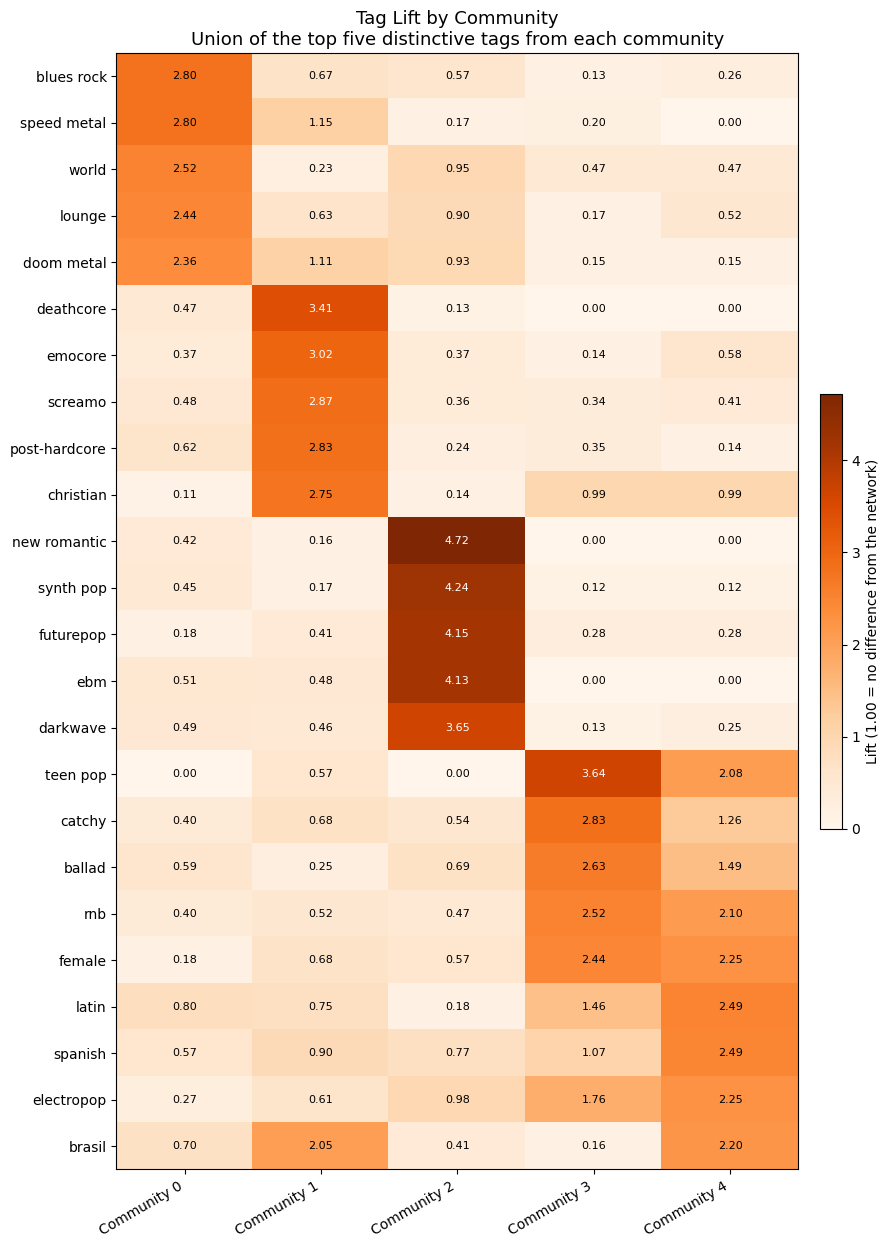


#### What the figure shows

- **Tags displayed:** 24 (union of the top
  5 distinctive tags from each community)
- **Highest lift in the grid:** 4.72
- **Tags overrepresented in exactly one community:** 13
  of 24

Most rows are dark in a single column and pale elsewhere. That pattern is the
visual form of the alignment result: the five friendship communities, which
were detected from friendships alone, are described by largely different sets
of tags.


In [ ]:
md("""
### 4.3.1 Tag Lift Across All Five Communities

The per-community tables show each community separately. This figure places
them on one grid so the communities can be compared directly.

- Each **row** is a tag.
- Each **column** is one of the five profiled communities.
- **Colour** is lift: how many times more common the tag is inside that
  community than across all 1,892 users.
- A value of **1.00** means the tag is equally common inside and outside.
- A value of **0.00** means no user in that community used the tag.

The tags included are the union of the top five distinctive tags from each
community, so every tag shown is distinctive somewhere. A tag that is dark in
one column and pale across the rest separates that community from the others.
""")

TAGS_PER_COMMUNITY_IN_HEATMAP = 5

heatmap_tag_labels = (
    top_distinctive_tags.loc[
        top_distinctive_tags["tag_lift_rank"] <= TAGS_PER_COMMUNITY_IN_HEATMAP,
        "canonical_tag",
    ]
    .drop_duplicates()
    .tolist()
)

tag_lift_grid = (
    community_tag_lift.loc[
        community_tag_lift["canonical_tag"].isin(heatmap_tag_labels)
        & community_tag_lift["community"].isin(profile_community_ids)
    ]
    .pivot_table(
        index="canonical_tag",
        columns="community",
        values="lift",
        aggfunc="max",
    )
    .reindex(index=heatmap_tag_labels, columns=profile_community_ids)
    .fillna(0.0)
)

assert not tag_lift_grid.empty, "The tag lift grid is empty."
assert tag_lift_grid.shape[1] == len(profile_community_ids), (
    "The tag lift grid does not contain all profiled communities."
)

fig, ax = plt.subplots(
    figsize=(9, 0.42 * len(tag_lift_grid) + 2.5),
)

grid_image = ax.imshow(
    tag_lift_grid,
    aspect="auto",
    cmap="Oranges",
    vmin=0,
    vmax=tag_lift_grid.to_numpy().max(),
)

ax.set_xticks(range(len(profile_community_ids)))
ax.set_xticklabels(
    [f"Community {int(community_id)}" for community_id in profile_community_ids]
)
ax.set_yticks(range(len(tag_lift_grid)))
ax.set_yticklabels(tag_lift_grid.index)

plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

colour_threshold = tag_lift_grid.to_numpy().max() * 0.60

for row, column in np.ndindex(tag_lift_grid.shape):
    value = tag_lift_grid.iloc[row, column]
    ax.text(
        column,
        row,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=8,
        color="white" if value > colour_threshold else "black",
    )

ax.set_title(
    "Tag Lift by Community\n"
    "Union of the top five distinctive tags from each community",
    fontsize=13,
)

fig.colorbar(
    grid_image,
    ax=ax,
    fraction=0.030,
    pad=0.03,
    label="Lift (1.00 = no difference from the network)",
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "community_tag_lift_heatmap.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

single_community_tags = int(
    ((tag_lift_grid > 1.0).sum(axis=1) == 1).sum()
)

md(f"""
#### What the figure shows

- **Tags displayed:** {len(tag_lift_grid)} (union of the top
  {TAGS_PER_COMMUNITY_IN_HEATMAP} distinctive tags from each community)
- **Highest lift in the grid:** {tag_lift_grid.to_numpy().max():.2f}
- **Tags overrepresented in exactly one community:** {single_community_tags}
  of {len(tag_lift_grid)}

Most rows are dark in a single column and pale elsewhere. That pattern is the
visual form of the alignment result: the five friendship communities, which
were detected from friendships alone, are described by largely different sets
of tags.
""")

In [ ]:
md("""
### 4.4  Interpretation of the Tag-Based Community Profiles

Common-tag reach identifies labels used by many community members, while tag lift identifies labels that are unusually common compared with the
full network of 1,892 users.

The top-15 common and distinctive lists overlap by:

- **Community 0:** 0 tags
- **Community 1:** 4 tags
- **Community 2:** 5 tags
- **Community 3:** 7 tags
- **Community 4:** 7 tags

This limited overlap shows that widely used tags are not always the tags that best distinguish a community.

#### Community 0: Classic rock, metal and experimental listening

Common tags include rock, classic rock, hard rock, metal, progressive rock and heavy metal.

Distinctive tags strengthen the metal profile. Blues rock and speed metal both have a lift of **2.80**, while doom metal, power metal,
progressive metal and black metal are also overrepresented.

Lounge, downtempo, IDM, new age and avant-garde suggest an additional experimental and electronic component.
This supports a **classic-rock, metal and eclectic experimental** identity.

#### Community 1: Metalcore, post-hardcore and Brazilian rock

Common tags include hardcore, punk, metalcore, screamo and post-hardcore.

The distinctive results strengthen this pattern:

- deathcore: **3.41 lift**
- emocore: **3.02 lift**
- screamo: **2.87 lift**
- post-hardcore: **2.83 lift**
- metalcore: **2.58 lift**

Brazilian and MPB also support the regional pattern found in the artist results.
This supports a **metalcore, post-hardcore and Brazilian alternative-rock** identity.

#### Community 2: Synth-pop, new wave and dark electronic music

Common tags include new wave, 80s, synthpop, industrial and post-punk.

The distinctive tags produce a particularly coherent profile:

- new romantic: **4.72 lift**
- synth pop: **4.24 lift**
- futurepop: **4.15 lift**
- EBM: **4.13 lift**
- darkwave: **3.65 lift**
- goth: **3.56 lift** 

(Note that: Lift shows how much more common something is in a community than overall.)

Gothic, dream pop, shoegaze and German provide further support.

These tags closely match the distinctive-artist results and support a **synth-pop, new-wave, darkwave and industrial-electronic** identity.

#### Community 3: 2000s youth-oriented pop and R&B

Common tags include pop, dance, female vocalist, R&B and hip-hop.

Teen pop is the most distinctive tag, with a lift of **3.64**. Catchy, ballad, female, cute, 00s, pop rock and electropop also appear.

These results agree with the youth-entertainment, female-pop and R&B artists identified earlier.
This supports a **2000s youth-oriented pop, female-pop and R&B** identity.

Broad or subjective tags such as catchy, cute and female provide supporting evidence but should not define the community alone.

#### Community 4: Latin-American and Brazilian pop

The common-tag profile resembles Community 3, with pop, dance, female vocalist, R&B and pop rock.

Distinctive tags reveal a clearer regional pattern:

- Latin: **2.49 lift**
- Spanish: **2.49 lift**
- Brasil: **2.20 lift**
- Brazilian: **1.69 lift**

Electropop, disco, dance and R&B provide the wider musical context.

These results agree with the Latin-American and Brazilian artists found in the lift ranking.
This supports a **Latin-American and Brazilian pop community with dance and international teen-pop influences**.

### Tag-Profile Conclusion

The tag profiles broadly support the artist-based interpretations.

The strongest agreement appears in:

- **Community 1:** metalcore and post-hardcore
- **Community 2:** synth-pop, new wave and dark electronic music
- **Community 4:** Latin-American and Brazilian pop

Tag lift also clarifies the difference between Communities 3 and 4. 
Community 3 is associated with teen pop, 2000s pop and R&B, while
Community 4 is associated with Latin-American and Brazilian pop.

These identities describe broad tendencies rather than every individual member. User-generated tags may remain subjective or ambiguous, and each community contains internal musical variety.

---
""")


### 4.4  Interpretation of the Tag-Based Community Profiles

Common-tag reach identifies labels used by many community members, while tag lift identifies labels that are unusually common compared with the
full network of 1,892 users.

The top-15 common and distinctive lists overlap by:

- **Community 0:** 0 tags
- **Community 1:** 4 tags
- **Community 2:** 5 tags
- **Community 3:** 7 tags
- **Community 4:** 7 tags

This limited overlap shows that widely used tags are not always the tags that best distinguish a community.

#### Community 0: Classic rock, metal and experimental listening

Common tags include rock, classic rock, hard rock, metal, progressive rock and heavy metal.

Distinctive tags strengthen the metal profile. Blues rock and speed metal both have a lift of **2.80**, while doom metal, power metal,
progressive metal and black metal are also overrepresented.

Lounge, downtempo, IDM, new age and avant-garde suggest an additional experimental and electronic component.
This supports a **classic-rock, metal and eclectic experimental** identity.

#### Community 1: Metalcore, post-hardcore and Brazilian rock

Common tags include hardcore, punk, metalcore, screamo and post-hardcore.

The distinctive results strengthen this pattern:

- deathcore: **3.41 lift**
- emocore: **3.02 lift**
- screamo: **2.87 lift**
- post-hardcore: **2.83 lift**
- metalcore: **2.58 lift**

Brazilian and MPB also support the regional pattern found in the artist results.
This supports a **metalcore, post-hardcore and Brazilian alternative-rock** identity.

#### Community 2: Synth-pop, new wave and dark electronic music

Common tags include new wave, 80s, synthpop, industrial and post-punk.

The distinctive tags produce a particularly coherent profile:

- new romantic: **4.72 lift**
- synth pop: **4.24 lift**
- futurepop: **4.15 lift**
- EBM: **4.13 lift**
- darkwave: **3.65 lift**
- goth: **3.56 lift** 

(Note that: Lift shows how much more common something is in a community than overall.)

Gothic, dream pop, shoegaze and German provide further support.

These tags closely match the distinctive-artist results and support a **synth-pop, new-wave, darkwave and industrial-electronic** identity.

#### Community 3: 2000s youth-oriented pop and R&B

Common tags include pop, dance, female vocalist, R&B and hip-hop.

Teen pop is the most distinctive tag, with a lift of **3.64**. Catchy, ballad, female, cute, 00s, pop rock and electropop also appear.

These results agree with the youth-entertainment, female-pop and R&B artists identified earlier.
This supports a **2000s youth-oriented pop, female-pop and R&B** identity.

Broad or subjective tags such as catchy, cute and female provide supporting evidence but should not define the community alone.

#### Community 4: Latin-American and Brazilian pop

The common-tag profile resembles Community 3, with pop, dance, female vocalist, R&B and pop rock.

Distinctive tags reveal a clearer regional pattern:

- Latin: **2.49 lift**
- Spanish: **2.49 lift**
- Brasil: **2.20 lift**
- Brazilian: **1.69 lift**

Electropop, disco, dance and R&B provide the wider musical context.

These results agree with the Latin-American and Brazilian artists found in the lift ranking.
This supports a **Latin-American and Brazilian pop community with dance and international teen-pop influences**.

### Tag-Profile Conclusion

The tag profiles broadly support the artist-based interpretations.

The strongest agreement appears in:

- **Community 1:** metalcore and post-hardcore
- **Community 2:** synth-pop, new wave and dark electronic music
- **Community 4:** Latin-American and Brazilian pop

Tag lift also clarifies the difference between Communities 3 and 4. 
Community 3 is associated with teen pop, 2000s pop and R&B, while
Community 4 is associated with Latin-American and Brazilian pop.

These identities describe broad tendencies rather than every individual member. User-generated tags may remain subjective or ambiguous, and each community contains internal musical variety.

---


In [ ]:
md("""
## 5. Final Results and Interpretation

### 5.1 Combining the Artist and Tag Profiles

Each community is interpreted using four results:

1. artists with the widest community reach;
2. artists with the highest lift;
3. tags with the widest community reach;
4. tags with the highest lift.

Final identities are based on repeated patterns across several related
artists and tags, rather than one isolated result.

The labels describe broad listening tendencies and do not apply equally
to every community member.
""")

md("""
### Building the Integrated Community Profiles

Artist reach, artist lift, tag reach and tag lift are combined into one summary for each community.
The table records the leading result from each analysis and the five highest-ranked artists and tags, making the evidence easier to compare.
""")

def get_ranked_rows(dataframe,community_id,rank_column,number_to_show=5,):
    """Return the highest-ranked rows for one community."""
    return (dataframe.loc[dataframe["community"] == community_id].sort_values(rank_column).head(number_to_show))


def join_ranked_values(dataframe,community_id,rank_column,value_column,number_to_show=5,):
    """Join the highest-ranked values into readable text."""
    return ", ".join(get_ranked_rows(dataframe,community_id,rank_column,number_to_show,)[value_column].astype(str).tolist())


integrated_profile_rows = []

for community_id in profile_community_ids:
    community_size = (community_sizes.loc[community_sizes["community"] == community_id].iloc[0])
    reach_leader = get_ranked_rows(top_artist_reach,community_id,"reach_rank",1,).iloc[0]
    artist_lift_leader = get_ranked_rows(top_distinctive_artists,community_id,"lift_rank",1,).iloc[0]
    common_tag_leader = get_ranked_rows(top_common_tags,community_id,"tag_reach_rank",1,).iloc[0]
    tag_lift_leader = get_ranked_rows(top_distinctive_tags,community_id,"tag_lift_rank",1,).iloc[0]
    integrated_profile_rows.append({
        "community": community_id,
        "users": int(community_size["users"]),
        "user_share": float(community_size["user_share"]),
        "reach_leader": reach_leader["artist_name"],
        "reach_leader_percentage": float(
            reach_leader["community_reach"]),
        "highest_lift_artist": artist_lift_leader["artist_name"],
        "highest_artist_lift": float(artist_lift_leader["lift"]),
        "most_common_tag": common_tag_leader["canonical_tag"],
        "common_tag_reach": float(
            common_tag_leader["community_tag_reach"]),
        "highest_lift_tag": tag_lift_leader["canonical_tag"],
        "highest_tag_lift": float(tag_lift_leader["lift"]),
        "top_reach_artists": join_ranked_values(
            top_artist_reach,
            community_id,
            "reach_rank",
            "artist_name",),
        "top_distinctive_artists": join_ranked_values(
            top_distinctive_artists,
            community_id,
            "lift_rank",
            "artist_name",),
        "top_common_tags": join_ranked_values(
            top_common_tags,
            community_id,
            "tag_reach_rank",
            "canonical_tag",),
        "top_distinctive_tags": join_ranked_values(
            top_distinctive_tags,
            community_id,
            "tag_lift_rank",
            "canonical_tag",),})

integrated_community_profiles = pd.DataFrame(integrated_profile_rows)

assert len(integrated_community_profiles) == len(profile_community_ids), ("The integrated profile table has an unexpected number of communities.")
assert integrated_community_profiles["community"].tolist() == (profile_community_ids), ("The communities are not in the expected order.")
assert integrated_community_profiles[["reach_leader","highest_lift_artist","most_common_tag","highest_lift_tag",]].notna().all().all(), ("At least one community profile is missing its leading evidence.")


## 5. Final Results and Interpretation

### 5.1 Combining the Artist and Tag Profiles

Each community is interpreted using four results:

1. artists with the widest community reach;
2. artists with the highest lift;
3. tags with the widest community reach;
4. tags with the highest lift.

Final identities are based on repeated patterns across several related
artists and tags, rather than one isolated result.

The labels describe broad listening tendencies and do not apply equally
to every community member.



### Building the Integrated Community Profiles

Artist reach, artist lift, tag reach and tag lift are combined into one summary for each community.
The table records the leading result from each analysis and the five highest-ranked artists and tags, making the evidence easier to compare.


In [ ]:
md("""
### Assigning the Final Community Identities

The reviewed artist and tag evidence is used to assign a final identity to each community.
A supporting interpretation is also added to show how the artist and tag results reinforce the chosen label.
""")

reviewed_community_identities = {
    0: "Classic rock, metal and eclectic experimental listening",
    1: "Metalcore, post-hardcore and Brazilian alternative rock",
    2: "Synth-pop, new wave, darkwave and industrial electronic music",
    3: "2000s youth-oriented pop, female pop and R&B",
    4: ("Latin-American and Brazilian pop with dance and ""teen-pop influences"),}

reviewed_profile_evidence = {
    0: ("Hard-rock and metal artists are reinforced by blues-rock, "
        "speed-metal, doom-metal and progressive-metal tags. "
        "Electronic and experimental tags indicate additional variety."),
    1: ("Metalcore and post-hardcore artists align with deathcore, "
        "screamo, hardcore and metalcore tags. Brazilian and MPB tags "
        "support a regional and language-related component."),
    2: ("New-wave and synth-pop artists align closely with new romantic, "
        "futurepop, EBM, darkwave, goth, industrial and post-punk tags."),
    3: ("Youth-entertainment and female-pop artists align with teen-pop, "
        "00s, R&B, dance, electropop and pop-rock tags."),
    4: ("Latin-American and Brazilian artists align with Latin, Spanish, "
        "Brasil and Brazilian tags, together with dance and pop."),}

integrated_community_profiles["reviewed_identity"] = (integrated_community_profiles["community"].map(reviewed_community_identities))
integrated_community_profiles["supporting_interpretation"] = (integrated_community_profiles["community"].map(reviewed_profile_evidence))

assert integrated_community_profiles[["reviewed_identity", "supporting_interpretation"]].notna().all().all(), ("At least one community is missing its reviewed identity or evidence.")


### Assigning the Final Community Identities

The reviewed artist and tag evidence is used to assign a final identity to each community.
A supporting interpretation is also added to show how the artist and tag results reinforce the chosen label.


In [ ]:
md("""
### Displaying and Saving the Integrated Profiles

The final table summarises each community's size, leading artists and tags, highest lift results, and reviewed musical identity.

The complete profile data is then saved as a CSV file.
""")

integrated_profile_display_columns = ["community","users","user_share","reach_leader","reach_leader_percentage","highest_lift_artist","highest_artist_lift","most_common_tag","highest_lift_tag","highest_tag_lift","reviewed_identity",]
integrated_profile_format = {"users": "{:,.0f}","user_share": "{:.1%}","reach_leader_percentage": "{:.1%}","highest_artist_lift": "{:.2f}","highest_tag_lift": "{:.2f}",}

display(integrated_community_profiles[integrated_profile_display_columns].style.format(integrated_profile_format))
integrated_profile_path = (OUT_DIR / "integrated_community_profiles.csv")
integrated_community_profiles.to_csv(integrated_profile_path,index=False,)

profiled_users = integrated_community_profiles["users"].sum()
profiled_user_share = integrated_community_profiles["user_share"].sum()

assert len(integrated_community_profiles) == len(profile_community_ids), ("The integrated table does not contain all selected communities.")
assert integrated_community_profiles[["reviewed_identity", "supporting_interpretation"]].notna().all().all(), ("At least one final profile is incomplete.")

md(f"""
### Integrated Profiles Created

- **Communities profiled:** {len(integrated_community_profiles)}
- **Users covered:** {profiled_users:,}
- **Share of all users:** {profiled_user_share:.1%}

Each final identity is supported by both artist and tag evidence.

Saved to:`{integrated_profile_path}`
""")


### Displaying and Saving the Integrated Profiles

The final table summarises each community's size, leading artists and tags, highest lift results, and reviewed musical identity.

The complete profile data is then saved as a CSV file.


,community,users,user_share,reach_leader,reach_leader_percentage,highest_lift_artist,highest_artist_lift,most_common_tag,highest_lift_tag,highest_tag_lift,reviewed_identity
0,0,437,23.1%,The Beatles,34.1%,Rainbow,4.08,rock,blues rock,2.80,"Classic rock, metal and eclectic experimental listening"
1,1,386,20.4%,Paramore,35.8%,August Burns Red,4.31,rock,deathcore,3.41,"Metalcore, post-hardcore and Brazilian alternative rock"
2,2,323,17.1%,Depeche Mode,57.3%,De/Vision,5.86,alternative,new romantic,4.72,"Synth-pop, new wave, darkwave and industrial electronic music"
3,3,280,14.8%,Lady Gaga,78.2%,Miranda Cosgrove,4.33,pop,teen pop,3.64,"2000s youth-oriented pop, female pop and R&B"
4,4,280,14.8%,Britney Spears,76.1%,Ivete Sangalo,5.63,pop,latin,2.49,Latin-American and Brazilian pop with dance and teen-pop influences



### Integrated Profiles Created

- **Communities profiled:** 5
- **Users covered:** 1,706
- **Share of all users:** 90.2%

Each final identity is supported by both artist and tag evidence.

Saved to:`C:\Users\keno_\Downloads\BIDA\outputs_m12\integrated_community_profiles.csv`


In [ ]:
md("""
### Displaying the Final Community Profiles

Each community is presented with its size, leading artists and tags,
highest lift results, and final reviewed interpretation.

Reach shows what is widely popular, while lift highlights what is
especially distinctive to the community.
""")

profile_lookup = (integrated_community_profiles.set_index("community"))
for community_id in profile_community_ids:
    profile = profile_lookup.loc[community_id]

    md(f"""
#### Community {community_id} — {profile["reviewed_identity"]}

- **Users:** {profile["users"]:,}
  ({profile["user_share"]:.1%} of the complete network)
- **Highest-reach artist:** {profile["reach_leader"]}
  ({profile["reach_leader_percentage"]:.1%} community reach)
- **Highest-lift artist:** {profile["highest_lift_artist"]}
  ({profile["highest_artist_lift"]:.2f} lift)
- **Most common tag:** {profile["most_common_tag"]}
- **Highest-lift tag:** {profile["highest_lift_tag"]}
  ({profile["highest_tag_lift"]:.2f} lift)

**Leading reach artists:**  
{profile["top_reach_artists"]}

**Leading distinctive artists:**  
{profile["top_distinctive_artists"]}

**Leading common tags:**  
{profile["top_common_tags"]}

**Leading distinctive tags:**  
{profile["top_distinctive_tags"]}

**Integrated interpretation:**  
{profile["supporting_interpretation"]}
""")


### Displaying the Final Community Profiles

Each community is presented with its size, leading artists and tags,
highest lift results, and final reviewed interpretation.

Reach shows what is widely popular, while lift highlights what is
especially distinctive to the community.



#### Community 0 — Classic rock, metal and eclectic experimental listening

- **Users:** 437
  (23.1% of the complete network)
- **Highest-reach artist:** The Beatles
  (34.1% community reach)
- **Highest-lift artist:** Rainbow
  (4.08 lift)
- **Most common tag:** rock
- **Highest-lift tag:** blues rock
  (2.80 lift)

**Leading reach artists:**  
The Beatles, Pink Floyd, Led Zeppelin, Iron Maiden, Radiohead

**Leading distinctive artists:**  
Rainbow, W.A.S.P., Whitesnake, Alice Cooper, Dio

**Leading common tags:**  
rock, alternative, classic rock, indie, hard rock

**Leading distinctive tags:**  
blues rock, speed metal, world, lounge, doom metal

**Integrated interpretation:**  
Hard-rock and metal artists are reinforced by blues-rock, speed-metal, doom-metal and progressive-metal tags. Electronic and experimental tags indicate additional variety.



#### Community 1 — Metalcore, post-hardcore and Brazilian alternative rock

- **Users:** 386
  (20.4% of the complete network)
- **Highest-reach artist:** Paramore
  (35.8% community reach)
- **Highest-lift artist:** August Burns Red
  (4.31 lift)
- **Most common tag:** rock
- **Highest-lift tag:** deathcore
  (3.41 lift)

**Leading reach artists:**  
Paramore, The Beatles, Radiohead, Muse, Arctic Monkeys

**Leading distinctive artists:**  
August Burns Red, CPM 22, Matanza, Forfun, Gloria

**Leading common tags:**  
rock, alternative, indie, alternative rock, female vocalist

**Leading distinctive tags:**  
deathcore, emocore, screamo, post-hardcore, christian

**Integrated interpretation:**  
Metalcore and post-hardcore artists align with deathcore, screamo, hardcore and metalcore tags. Brazilian and MPB tags support a regional and language-related component.



#### Community 2 — Synth-pop, new wave, darkwave and industrial electronic music

- **Users:** 323
  (17.1% of the complete network)
- **Highest-reach artist:** Depeche Mode
  (57.3% community reach)
- **Highest-lift artist:** De/Vision
  (5.86 lift)
- **Most common tag:** alternative
- **Highest-lift tag:** new romantic
  (4.72 lift)

**Leading reach artists:**  
Depeche Mode, The Cure, Radiohead, Muse, The Beatles

**Leading distinctive artists:**  
De/Vision, Camouflage, Soft Cell, Mesh, Icehouse

**Leading common tags:**  
alternative, rock, new wave, indie, 80s

**Leading distinctive tags:**  
new romantic, synth pop, futurepop, ebm, darkwave

**Integrated interpretation:**  
New-wave and synth-pop artists align closely with new romantic, futurepop, EBM, darkwave, goth, industrial and post-punk tags.



#### Community 3 — 2000s youth-oriented pop, female pop and R&B

- **Users:** 280
  (14.8% of the complete network)
- **Highest-reach artist:** Lady Gaga
  (78.2% community reach)
- **Highest-lift artist:** Miranda Cosgrove
  (4.33 lift)
- **Most common tag:** pop
- **Highest-lift tag:** teen pop
  (3.64 lift)

**Leading reach artists:**  
Lady Gaga, Britney Spears, Rihanna, Katy Perry, Christina Aguilera

**Leading distinctive artists:**  
Miranda Cosgrove, Hannah Montana, Emily Osment, Jason Derülo, 소녀시대

**Leading common tags:**  
pop, dance, female vocalist, rock, rnb

**Leading distinctive tags:**  
teen pop, catchy, ballad, rnb, female

**Integrated interpretation:**  
Youth-entertainment and female-pop artists align with teen-pop, 00s, R&B, dance, electropop and pop-rock tags.



#### Community 4 — Latin-American and Brazilian pop with dance and teen-pop influences

- **Users:** 280
  (14.8% of the complete network)
- **Highest-reach artist:** Britney Spears
  (76.1% community reach)
- **Highest-lift artist:** Ivete Sangalo
  (5.63 lift)
- **Most common tag:** pop
- **Highest-lift tag:** latin
  (2.49 lift)

**Leading reach artists:**  
Britney Spears, Lady Gaga, Rihanna, Katy Perry, Beyoncé

**Leading distinctive artists:**  
Ivete Sangalo, Wanessa, Thalía, Sandy e Junior, Christian Chávez

**Leading common tags:**  
pop, dance, rock, female vocalist, alternative

**Leading distinctive tags:**  
latin, spanish, electropop, female, brasil

**Integrated interpretation:**  
Latin-American and Brazilian artists align with Latin, Spanish, Brasil and Brazilian tags, together with dance and pop.


In [ ]:
md("""
### 5.1.1 Final Integrated Community Profiles

The artist and tag results identify five recognisable listening communities. Each profile is supported by several related artists and tags rather than one isolated result.

#### Community 0 — Classic rock, metal and experimental listening

Community 0 is centred on classic rock, hard rock and heavy metal.

Its leading artists include The Beatles, Pink Floyd, Led Zeppelin, Metallica, Black Sabbath, Rainbow, Dio and Judas Priest. Distinctive tags such as blues rock, speed metal, doom metal and progressive metal
support this identity.

Lounge, downtempo, IDM and avant-garde also indicate an experimental and electronic element.

#### Community 1: Metalcore, post-hardcore and Brazilian rock

Community 1 combines metalcore, post-hardcore and pop-punk with a Brazilian or Portuguese-language component.

Artists such as August Burns Red, Asking Alexandria, A Day to Remember and The Devil Wears Prada align with deathcore, screamo, hardcore and
metalcore tags.

CPM 22, Raimundos and Los Hermanos, together with Brazilian and MPB tags, support the regional pattern.

#### Community 2: Synth-pop, new wave and dark electronic music

Community 2 shows the clearest agreement between artist and tag evidence.

Depeche Mode, The Cure, New Order, De/Vision, Camouflage and Gary Numan align closely with new romantic, synth pop, futurepop, EBM, darkwave,
post-punk and industrial tags.

This is the strongest example of a community associated with a coherent set of related musical styles.

#### Community 3: 2000s youth-oriented pop and R&B

Community 3 includes mainstream pop artists such as Lady Gaga, Britney Spears and Rihanna.

Its distinctive profile contains Miranda Cosgrove, Hannah Montana, Emily Osment, Nicki Minaj and other female pop or R&B performers.

Teen pop, 00s, R&B, dance and electropop support a youth-oriented 2000s-pop identity.

#### Community 4: Latin-American and Brazilian pop

Community 4 initially resembles Community 3 because both contain mainstream pop and dance music.

Lift separates it through artists such as Ivete Sangalo, Wanessa, Thalía, RBD, Belinda and Ricky Martin.

Latin, Spanish, Brasil and Brazilian tags confirm the regional pattern, while dance, electropop and teen pop provide the wider musical context.

### Integrated-Profile Conclusion

Artist and tag evidence generally supports the same community interpretations.

Community 2 has the most coherent profile. Communities 3 and 4 show why lift is important: their common tastes are similar, but their
distinctive results reveal different musical and regional tendencies.

These labels describe broad community patterns and do not apply equally to every member.
""")


### 5.1.1 Final Integrated Community Profiles

The artist and tag results identify five recognisable listening communities. Each profile is supported by several related artists and tags rather than one isolated result.

#### Community 0 — Classic rock, metal and experimental listening

Community 0 is centred on classic rock, hard rock and heavy metal.

Its leading artists include The Beatles, Pink Floyd, Led Zeppelin, Metallica, Black Sabbath, Rainbow, Dio and Judas Priest. Distinctive tags such as blues rock, speed metal, doom metal and progressive metal
support this identity.

Lounge, downtempo, IDM and avant-garde also indicate an experimental and electronic element.

#### Community 1: Metalcore, post-hardcore and Brazilian rock

Community 1 combines metalcore, post-hardcore and pop-punk with a Brazilian or Portuguese-language component.

Artists such as August Burns Red, Asking Alexandria, A Day to Remember and The Devil Wears Prada align with deathcore, screamo, hardcore and
metalcore tags.

CPM 22, Raimundos and Los Hermanos, together with Brazilian and MPB tags, support the regional pattern.

#### Community 2: Synth-pop, new wave and dark electronic music

Community 2 shows the clearest agreement between artist and tag evidence.

Depeche Mode, The Cure, New Order, De/Vision, Camouflage and Gary Numan align closely with new romantic, synth pop, futurepop, EBM, darkwave,
post-punk and industrial tags.

This is the strongest example of a community associated with a coherent set of related musical styles.

#### Community 3: 2000s youth-oriented pop and R&B

Community 3 includes mainstream pop artists such as Lady Gaga, Britney Spears and Rihanna.

Its distinctive profile contains Miranda Cosgrove, Hannah Montana, Emily Osment, Nicki Minaj and other female pop or R&B performers.

Teen pop, 00s, R&B, dance and electropop support a youth-oriented 2000s-pop identity.

#### Community 4: Latin-American and Brazilian pop

Community 4 initially resembles Community 3 because both contain mainstream pop and dance music.

Lift separates it through artists such as Ivete Sangalo, Wanessa, Thalía, RBD, Belinda and Ricky Martin.

Latin, Spanish, Brasil and Brazilian tags confirm the regional pattern, while dance, electropop and teen pop provide the wider musical context.

### Integrated-Profile Conclusion

Artist and tag evidence generally supports the same community interpretations.

Community 2 has the most coherent profile. Communities 3 and 4 show why lift is important: their common tastes are similar, but their
distinctive results reveal different musical and regional tendencies.

These labels describe broad community patterns and do not apply equally to every member.


In [ ]:
md("""
### 5.2 Do Friendship Communities Align with Musical Taste?

The communities were created using friendship links only. Listening and tag data were added afterwards.

This makes it possible to test whether socially connected users also show similar musical preferences.

Evidence of alignment includes:

- related artists appearing in the same community;
- tags supporting the artist patterns;
- different communities having different high-lift profiles;
- artist and tag results pointing to similar identities.

Alignment does not mean every member has the same taste. It means each community shows a meaningful overall listening pattern.
""")

md("""
### Summarising Evidence of Taste Alignment

The final community identities are combined with the artist and tag overlap results.

Replacement shares show how much each profile changes when moving from widely popular results to distinctive lift results. Higher replacement
suggests that lift reveals information hidden by broad popularity.
The alignment ratings are reviewed judgements based on agreement across several related artists and tags, not calculated scores.
""")

alignment_evidence = (
    integrated_community_profiles[
        ["community","users","user_share","reviewed_identity","supporting_interpretation",]]
    .merge(reach_lift_overlap[["community", "shared_artists", "artists_replaced"]],on="community",how="left",validate="one_to_one",)
    .merge(common_lift_overlap[["community", "shared_tags", "tags_replaced"]],on="community",how="left",validate="one_to_one",))

alignment_evidence["artist_list_replacement_share"] = (alignment_evidence["artists_replaced"] / TOP_K)
alignment_evidence["tag_list_replacement_share"] = (alignment_evidence["tags_replaced"] / TOP_K)

reviewed_alignment_strength = {
    0: "Strong",
    1: "Strong",
    2: "Very strong",
    3: "Moderate to strong",
    4: "Strong",
}

alignment_evidence["reviewed_alignment_strength"] = (alignment_evidence["community"].map(reviewed_alignment_strength))

assert len(alignment_evidence) == len(profile_community_ids), ("The alignment table does not contain all profiled communities.")
assert alignment_evidence[["shared_artists","artists_replaced","shared_tags","tags_replaced","reviewed_alignment_strength",]].notna().all().all(), ("At least one community is missing alignment evidence.")

display(
    alignment_evidence[
        ["community","users","user_share","reviewed_identity","shared_artists","artist_list_replacement_share","shared_tags","tag_list_replacement_share","reviewed_alignment_strength",]
    ].style.format({"users": "{:,.0f}","user_share": "{:.1%}","artist_list_replacement_share": "{:.1%}","tag_list_replacement_share": "{:.1%}",
    }))


### 5.2 Do Friendship Communities Align with Musical Taste?

The communities were created using friendship links only. Listening and tag data were added afterwards.

This makes it possible to test whether socially connected users also show similar musical preferences.

Evidence of alignment includes:

- related artists appearing in the same community;
- tags supporting the artist patterns;
- different communities having different high-lift profiles;
- artist and tag results pointing to similar identities.

Alignment does not mean every member has the same taste. It means each community shows a meaningful overall listening pattern.



### Summarising Evidence of Taste Alignment

The final community identities are combined with the artist and tag overlap results.

Replacement shares show how much each profile changes when moving from widely popular results to distinctive lift results. Higher replacement
suggests that lift reveals information hidden by broad popularity.
The alignment ratings are reviewed judgements based on agreement across several related artists and tags, not calculated scores.


,community,users,user_share,reviewed_identity,shared_artists,artist_list_replacement_share,shared_tags,tag_list_replacement_share,reviewed_alignment_strength
0,0,437,23.1%,"Classic rock, metal and eclectic experimental listening",2,86.7%,0,100.0%,Strong
1,1,386,20.4%,"Metalcore, post-hardcore and Brazilian alternative rock",1,93.3%,4,73.3%,Strong
2,2,323,17.1%,"Synth-pop, new wave, darkwave and industrial electronic music",0,100.0%,5,66.7%,Very strong
3,3,280,14.8%,"2000s youth-oriented pop, female pop and R&B",0,100.0%,7,53.3%,Moderate to strong
4,4,280,14.8%,Latin-American and Brazilian pop with dance and teen-pop influences,0,100.0%,7,53.3%,Strong


In [ ]:
md("""
### Summarising the Evidence for Taste Alignment

The main findings are brought together to assess whether friendship communities also show meaningful musical differences.
The summary covers network structure, seed sensitivity, population coverage, changes introduced by lift, and agreement between artist and tag profiles.
""")

profiled_users = integrated_community_profiles["users"].sum()
profiled_share = integrated_community_profiles["user_share"].sum()
artist_positions_replaced = reach_lift_overlap["artists_replaced"].sum()
tag_positions_replaced = common_lift_overlap["tags_replaced"].sum()
total_ranked_positions = len(profile_community_ids) * TOP_K
alignment_summary = pd.DataFrame([
    {"evidence_area": "Friendship community structure",
        "result": (f"{community_count} communities; "f"modularity {modularity_score:.4f}"),
        "interpretation": ("The friendship graph contains meaningful modular structure."),
    },
    {"evidence_area": "Seed sensitivity",
        "result": (f"Modularity {lowest_modularity:.4f}–"f"{best_modularity:.4f}"),
        "interpretation": ("Community quality was broadly stable, although exact ""memberships and sizes remained sensitive to the seed."),
    },
    {"evidence_area": "Population profiled",
        "result": (f"{profiled_users:,} users "f"({profiled_share:.1%})"),
        "interpretation": ("The five profiles cover most of the complete network."),
    },
    {"evidence_area": "Artist profiles",
        "result": (f"{artist_positions_replaced} of "f"{total_ranked_positions} reach-list positions ""replaced by lift"),
        "interpretation": ("Distinctive artists reveal community-specific patterns ""that broad popularity obscures."),
    },
    {"evidence_area": "Tag profiles",
        "result": (f"{tag_positions_replaced} of "f"{total_ranked_positions} common-tag positions ""replaced by lift"),
        "interpretation": ("Distinctive tags provide more specialised descriptions ""than common tags alone."),
    },
    {"evidence_area": "Artist–tag agreement",
        "result": "Agreement across all five reviewed communities",
        "interpretation": ("Related high-lift artists are generally supported by ""related high-lift tags."),
    },])

assert len(alignment_summary) == 6, ("The alignment summary is missing an evidence area.")
display(alignment_summary)


### Summarising the Evidence for Taste Alignment

The main findings are brought together to assess whether friendship communities also show meaningful musical differences.
The summary covers network structure, seed sensitivity, population coverage, changes introduced by lift, and agreement between artist and tag profiles.


,evidence_area,result,interpretation
0,Friendship community structure,31 communities; modularity 0.4640,The friendship graph contains meaningful modular structure.
1,Seed sensitivity,Modularity 0.4423–0.4640,"Community quality was broadly stable, although exact memberships and sizes r..."
2,Population profiled,"1,706 users (90.2%)",The five profiles cover most of the complete network.
3,Artist profiles,72 of 75 reach-list positions replaced by lift,Distinctive artists reveal community-specific patterns that broad popularity...
4,Tag profiles,52 of 75 common-tag positions replaced by lift,Distinctive tags provide more specialised descriptions than common tags alone.
5,Artist–tag agreement,Agreement across all five reviewed communities,Related high-lift artists are generally supported by related high-lift tags.


In [ ]:
md("""
### Validating the Musical-Alignment Evidence

The checks confirm that all five communities are included, the expected 1,706 users are covered, and the artist, tag and reviewed identity
evidence is complete.
""")

profiled_users = int(alignment_evidence["users"].sum())
profiled_share = round(alignment_evidence["user_share"].sum(), 3)

artist_comparisons_complete = (alignment_evidence["shared_artists"].notna())
tag_comparisons_complete = (alignment_evidence["shared_tags"].notna())
identities_complete = (alignment_evidence["reviewed_identity"].notna())

alignment_validation = pd.DataFrame([
    {"check": "Five integrated communities assessed","result": len(alignment_evidence),"expected": 5,"passed": len(alignment_evidence) == 5,},
    {"check": "Profiled users","result": profiled_users,"expected": 1_706,"passed": profiled_users == 1_706,},
    {"check": "Profiled population share","result": profiled_share,"expected": 0.902,"passed": profiled_share == 0.902,},
    {"check": "Artist comparison rows complete","result": artist_comparisons_complete.sum(),"expected": 5,"passed": artist_comparisons_complete.all(),},
    {"check": "Tag comparison rows complete","result": tag_comparisons_complete.sum(),"expected": 5,"passed": tag_comparisons_complete.all(),},
    {"check": "Reviewed identities complete","result": identities_complete.sum(),"expected": 5,"passed": identities_complete.all(),},])

display(alignment_validation)
assert alignment_validation["passed"].all(), ("The musical-alignment evidence failed validation.")

md("""
### Alignment Evidence Validated

All five integrated profiles are complete and cover **1,706 users** or **90.2% of the network**.
""")


### Validating the Musical-Alignment Evidence

The checks confirm that all five communities are included, the expected 1,706 users are covered, and the artist, tag and reviewed identity
evidence is complete.


,check,result,expected,passed
0,Five integrated communities assessed,5.000,5.000,True
1,Profiled users,1706.000,1706.000,True
2,Profiled population share,0.902,0.902,True
3,Artist comparison rows complete,5.000,5.000,True
4,Tag comparison rows complete,5.000,5.000,True
5,Reviewed identities complete,5.000,5.000,True



### Alignment Evidence Validated

All five integrated profiles are complete and cover **1,706 users** or **90.2% of the network**.


In [ ]:
md(f"""
### 5.2.1 Do Social Communities Align with Musical Taste?

The results show a **meaningful but incomplete relationship** between friendship communities and musical taste.

The friendship graph was divided into **{community_count} communities** with a selected modularity of **{modularity_score:.4f}**. The five
largest communities contain **1,706 users**, representing **90.2% of the network**.

Because the communities were detected using friendship links only, the later agreement with artist and tag profiles provides evidence that
social structure is associated with listening behaviour.

The five communities show the following broad tendencies:

- **Community 0:** classic rock, metal and experimental listening
- **Community 1:** metalcore, post-hardcore and Brazilian alternative rock
- **Community 2:** synth-pop, new wave and dark electronic music
- **Community 3:** 2000s youth-oriented pop and R&B
- **Community 4:** Latin-American and Brazilian pop

Artist and tag evidence generally supports the same interpretations.
For example, Community 2 combines related synth-pop and new-wave artists with tags such as new romantic, futurepop, EBM and darkwave. Communities
1 and 4 also show agreement between their distinctive artists and genre, language or regional tags.

The relationship is not perfect. Popular artists and broad tags appear in several communities, and each community contains internal variety.
Communities 3 and 4 become clearly different only after lift reduces the influence of general popularity.

Some profiles may also reflect language, geography or shared cultural background rather than musical genre alone.

> **Friendship communities in this network are associated with
> recognisable musical preferences, but social structure and musical
> taste do not correspond perfectly.**

The results show association, not causation. They cannot determine whether friendship influences taste, shared taste encourages friendship,
or both are shaped by other social factors.
""")


### 5.2.1 Do Social Communities Align with Musical Taste?

The results show a **meaningful but incomplete relationship** between friendship communities and musical taste.

The friendship graph was divided into **31 communities** with a selected modularity of **0.4640**. The five
largest communities contain **1,706 users**, representing **90.2% of the network**.

Because the communities were detected using friendship links only, the later agreement with artist and tag profiles provides evidence that
social structure is associated with listening behaviour.

The five communities show the following broad tendencies:

- **Community 0:** classic rock, metal and experimental listening
- **Community 1:** metalcore, post-hardcore and Brazilian alternative rock
- **Community 2:** synth-pop, new wave and dark electronic music
- **Community 3:** 2000s youth-oriented pop and R&B
- **Community 4:** Latin-American and Brazilian pop

Artist and tag evidence generally supports the same interpretations.
For example, Community 2 combines related synth-pop and new-wave artists with tags such as new romantic, futurepop, EBM and darkwave. Communities
1 and 4 also show agreement between their distinctive artists and genre, language or regional tags.

The relationship is not perfect. Popular artists and broad tags appear in several communities, and each community contains internal variety.
Communities 3 and 4 become clearly different only after lift reduces the influence of general popularity.

Some profiles may also reflect language, geography or shared cultural background rather than musical genre alone.

> **Friendship communities in this network are associated with
> recognisable musical preferences, but social structure and musical
> taste do not correspond perfectly.**

The results show association, not causation. They cannot determine whether friendship influences taste, shared taste encourages friendship,
or both are shaped by other social factors.


In [ ]:
md("""
### 5.3 Limitations and Final Conclusion

The results suggest that friendship communities are associated with recognisable musical preferences.

However, the findings depend on the available data, the graph design, the Louvain method and the profiling approach. These limitations define
what conclusions can reasonably be drawn.
""")


### 5.3 Limitations and Final Conclusion

The results suggest that friendship communities are associated with recognisable musical preferences.

However, the findings depend on the available data, the graph design, the Louvain method and the profiling approach. These limitations define
what conclusions can reasonably be drawn.


In [ ]:
md("""
### Recording the Main Limitations

The limitations explain how the dataset, network design, Louvain algorithm, tag cleaning and lift calculations affect the conclusions.

They also clarify that the results describe associations in this historical dataset rather than causal or universal relationships.
""")

module_2_limitations = pd.DataFrame([
    {
        "area": "Historical and sampled dataset",
        "limitation": (
            "The analysis uses one historical Last.fm dataset containing "
            "1,892 users rather than the complete or current network."
        ),
        "effect_on_interpretation": (
            "The findings should not automatically be generalised to all "
            "Last.fm users or current listening habits."
        ),
    },
    {
        "area": "Static network snapshot",
        "limitation": (
            "Friendships and listening behaviour are analysed as one static "
            "snapshot without changes over time."
        ),
        "effect_on_interpretation": (
            "The analysis cannot establish whether friendship preceded shared "
            "taste or shared taste preceded friendship."
        ),
    },
    {
        "area": "Unweighted friendship graph",
        "limitation": (
            "Every friendship is treated equally because friendship strength, "
            "interaction frequency and direction are unavailable."
        ),
        "effect_on_interpretation": (
            "A weak acquaintance and a close relationship have the same effect "
            "on community detection."
        ),
    },
    {
        "area": "Louvain stochasticity",
        "limitation": (
            "Louvain can produce different partitions from different random "
            "starting points."
        ),
        "effect_on_interpretation": (
            "The selected seed had the highest tested modularity, but the "
            "partition is not uniquely correct or guaranteed to be optimal."
        ),
    },
    {
        "area": "Resolution and modularity limits",
        "limitation": (
            "The analysis uses a resolution of 1.0, while other values could "
            "merge or divide communities differently."
        ),
        "effect_on_interpretation": (
            "The 31-community result represents one scale of social structure, "
            "not the only possible scale."
        ),
    },
    {
        "area": "Community-ID instability",
        "limitation": (
            "Community IDs were assigned by descending size after selecting "
            "the partition."
        ),
        "effect_on_interpretation": (
            "The numerical IDs are meaningful only within the selected run and "
            "are not permanent identities."
        ),
    },
    {
        "area": "Five-community focus",
        "limitation": (
            "Detailed profiles were created only for the five largest "
            "communities."
        ),
        "effect_on_interpretation": (
            "The profiles cover 90.2% of users but exclude the remaining 9.8% "
            "across 26 smaller communities."
        ),
    },
    {
        "area": "User-generated tags",
        "limitation": (
            "Tags are subjective and may describe genre, era, language, "
            "geography, mood or personal opinion."
        ),
        "effect_on_interpretation": (
            "Tags should not be treated as objective or universally agreed "
            "artist classifications."
        ),
    },
    {
        "area": "Tag coverage",
        "limitation": (
            "Thirty users in the five profiled communities did not contribute "
            "an approved tag."
        ),
        "effect_on_interpretation": (
            "Tag coverage is high but incomplete, ranging from 96.1% to 99.2% "
            "across the five communities."
        ),
    },
    {
        "area": "Cleaning and human judgement",
        "limitation": (
            "The approved tag set depends partly on the cleaning and review "
            "decisions made in Module 0."
        ),
        "effect_on_interpretation": (
            "Other reasonable cleaning rules could retain different labels and "
            "slightly change the profiles."
        ),
    },
    {
        "area": "Lift sensitivity",
        "limitation": (
            "Lift can become large when an artist or tag has low global reach."
        ),
        "effect_on_interpretation": (
            "A 5% community-reach threshold was applied, and identities were "
            "based on several related results rather than one high lift."
        ),
    },
    {
        "area": "Language and geography",
        "limitation": (
            "Some profiles contain Brazilian, Portuguese-language, Latin and "
            "Spanish patterns."
        ),
        "effect_on_interpretation": (
            "Community structure may reflect culture, geography or language "
            "as well as musical genre."
        ),
    },
    {
        "area": "Association rather than causation",
        "limitation": (
            "The analysis is observational rather than experimental or "
            "longitudinal."
        ),
        "effect_on_interpretation": (
            "It cannot determine whether friendship causes shared taste, "
            "shared taste causes friendship, or both reflect other factors."
        ),
    },
])

assert len(module_2_limitations) == 13, (
    "The expected limitation categories were not retained."
)

assert module_2_limitations[
    ["area", "limitation", "effect_on_interpretation"]
].notna().all().all(), (
    "At least one limitation entry is incomplete."
)

assert not module_2_limitations["area"].duplicated().any(), (
    "A limitation category appears more than once."
)

limitations_style = (
    module_2_limitations.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "left",
            "vertical-align": "top",
            "white-space": "normal",
            "overflow-wrap": "break-word",
        }
    )
    .set_properties(
        subset=["area"],
        **{
            "width": "18%",
            "font-weight": "bold",
        }
    )
    .set_properties(
        subset=["limitation", "effect_on_interpretation"],
        **{
            "width": "41%",
        }
    )
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("width", "100%"),
                ("table-layout", "fixed"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("vertical-align", "top"),
                ("white-space", "normal"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px"),
                ("line-height", "1.4"),
            ],
        },
    ])
)

with pd.option_context("display.max_colwidth", None):
    display(limitations_style)

limitations_path = OUT_DIR / "module_2_limitations.csv"

module_2_limitations.to_csv(
    limitations_path,
    index=False,
)

md(f"""
### Limitations Recorded

- **Limitation categories:** {len(module_2_limitations)}
- **Incomplete entries:** {
    module_2_limitations.isna().any(axis=1).sum()
}
- **Duplicate categories:** {
    module_2_limitations["area"].duplicated().sum()
}

Saved to:`{limitations_path}`
""")


### Recording the Main Limitations

The limitations explain how the dataset, network design, Louvain algorithm, tag cleaning and lift calculations affect the conclusions.

They also clarify that the results describe associations in this historical dataset rather than causal or universal relationships.


area,limitation,effect_on_interpretation
Historical and sampled dataset,"The analysis uses one historical Last.fm dataset containing 1,892 users rather than the complete or current network.",The findings should not automatically be generalised to all Last.fm users or current listening habits.
Static network snapshot,Friendships and listening behaviour are analysed as one static snapshot without changes over time.,The analysis cannot establish whether friendship preceded shared taste or shared taste preceded friendship.
Unweighted friendship graph,"Every friendship is treated equally because friendship strength, interaction frequency and direction are unavailable.",A weak acquaintance and a close relationship have the same effect on community detection.
Louvain stochasticity,Louvain can produce different partitions from different random starting points.,"The selected seed had the highest tested modularity, but the partition is not uniquely correct or guaranteed to be optimal."
Resolution and modularity limits,"The analysis uses a resolution of 1.0, while other values could merge or divide communities differently.","The 31-community result represents one scale of social structure, not the only possible scale."
Community-ID instability,Community IDs were assigned by descending size after selecting the partition.,The numerical IDs are meaningful only within the selected run and are not permanent identities.
Five-community focus,Detailed profiles were created only for the five largest communities.,The profiles cover 90.2% of users but exclude the remaining 9.8% across 26 smaller communities.
User-generated tags,"Tags are subjective and may describe genre, era, language, geography, mood or personal opinion.",Tags should not be treated as objective or universally agreed artist classifications.
Tag coverage,Thirty users in the five profiled communities did not contribute an approved tag.,"Tag coverage is high but incomplete, ranging from 96.1% to 99.2% across the five communities."
Cleaning and human judgement,The approved tag set depends partly on the cleaning and review decisions made in Module 0.,Other reasonable cleaning rules could retain different labels and slightly change the profiles.



### Limitations Recorded

- **Limitation categories:** 13
- **Incomplete entries:** 0
- **Duplicate categories:** 0

Saved to:`C:\Users\keno_\Downloads\BIDA\outputs_m12\module_2_limitations.csv`


In [ ]:
md("""
### Running the Final Module 2 Checks

The final checks confirm that the selected Louvain partition, community coverage, reviewed identities and documented limitations remain
consistent with the completed analysis.
""")

selected_modularity = round(modularity_score, 4)
profiled_users = int(integrated_community_profiles["users"].sum())
profiled_share = round(integrated_community_profiles["user_share"].sum(),3,)
completed_identities = (integrated_community_profiles["reviewed_identity"].notna().sum())
module_2_final_checks = pd.DataFrame([
    {"check": "Selected seed retained","result": SELECTED_LOUVAIN_SEED,"expected": 11,"passed": SELECTED_LOUVAIN_SEED == 11,},
    {"check": "Selected modularity retained","result": selected_modularity,"expected": 0.4640,"passed": selected_modularity == 0.4640,},
    {"check": "Community count retained","result": community_count,"expected": 31,"passed": community_count == 31,},
    {"check": "Five communities profiled","result": len(integrated_community_profiles),"expected": 5,"passed": len(integrated_community_profiles) == 5,},
    {"check": "Profiled users retained","result": profiled_users,"expected": 1_706,"passed": profiled_users == 1_706,},
    {"check": "Profiled share retained","result": profiled_share,"expected": 0.902,"passed": profiled_share == 0.902,},
    {"check": "All integrated identities complete","result": completed_identities,"expected": 5,"passed": completed_identities == 5,},
    {"check": "Limitations documented","result": len(module_2_limitations),"expected": 13,"passed": len(module_2_limitations) == 13,},])

display(module_2_final_checks.style.hide(axis="index").set_properties(**{"text-align": "left","vertical-align": "top",}))
assert module_2_final_checks["passed"].all(), ("The final Module 2 validation failed.")

md(f"""
### Final Module 2 Checks Passed

All **{len(module_2_final_checks)} validation checks** passed.

The selected partition, five community profiles, coverage of
**{profiled_users:,} users**, reviewed identities and documented limitations have been retained correctly.
""")


### Running the Final Module 2 Checks

The final checks confirm that the selected Louvain partition, community coverage, reviewed identities and documented limitations remain
consistent with the completed analysis.


check,result,expected,passed
Selected seed retained,11.000000,11.000000,True
Selected modularity retained,0.464000,0.464000,True
Community count retained,31.000000,31.000000,True
Five communities profiled,5.000000,5.000000,True
Profiled users retained,1706.000000,1706.000000,True
Profiled share retained,0.902000,0.902000,True
All integrated identities complete,5.000000,5.000000,True
Limitations documented,13.000000,13.000000,True



### Final Module 2 Checks Passed

All **8 validation checks** passed.

The selected partition, five community profiles, coverage of
**1,706 users**, reviewed identities and documented limitations have been retained correctly.


In [ ]:
md(f"""
### 5.3.1 Final Module 2 Conclusion

The friendship graph contains meaningful but non-unique community structure.

Across the tested random seeds, modularity ranged from
**{lowest_modularity:.4f} to {best_modularity:.4f}**. Seed
**{SELECTED_LOUVAIN_SEED}** achieved the highest tested modularity and was selected for the final analysis.

The selected partition contains:

- **Modularity:** {modularity_score:.4f}
- **Communities:** {community_count}
- **Five largest community sizes:** {", ".join(map(str, selected_community_sizes[:5]))}
- **Profiled users:** 1,706
- **Network coverage:** 90.2%

The five largest friendship communities show the following musical tendencies:

1. **Community 0:** classic rock, metal and experimental listening
2. **Community 1:** metalcore, post-hardcore and Brazilian alternative
   rock
3. **Community 2:** synth-pop, new wave, darkwave and industrial
   electronic music
4. **Community 3:** 2000s youth-oriented pop, female pop and R&B
5. **Community 4:** Latin-American and Brazilian pop with dance and
   teen-pop influences

Lift revealed patterns hidden by general popularity. Artist lift replaced **{int(reach_lift_overlap["artists_replaced"].sum())} of
{5 * TOP_K}** raw-reach positions, while tag lift replaced **{int(common_lift_overlap["tags_replaced"].sum())} of {5 * TOP_K}** common-tag positions.

The strongest profiles are supported by several related artists and tags. 
Community 2 provides the clearest example, with new-wave, synth-pop and dark-electronic artists reinforced by new romantic, futurepop, EBM, darkwave, post-punk and industrial tags.

Lift also separates Communities 3 and 4. Their common profiles both contain mainstream pop and dance, but their distinctive results reveal different youth-pop, R&B and regional tendencies.

> **Friendship communities in this dataset are associated with
> recognisable musical preferences, but social structure and musical
> taste do not correspond perfectly.**

The relationship remains incomplete because communities contain internal variety, some artists and tags occur across several groups, and language, geography or culture may also influence the results.

The selected Louvain partition is stochastic and resolution-dependent, so other seeds, software versions or resolution settings may produce different memberships.
These findings show association rather than causation. They cannot determine whether friendship influences taste, shared taste encourages friendship, or both reflect other social and cultural factors.
""")


### 5.3.1 Final Module 2 Conclusion

The friendship graph contains meaningful but non-unique community structure.

Across the tested random seeds, modularity ranged from
**0.4423 to 0.4640**. Seed
**11** achieved the highest tested modularity and was selected for the final analysis.

The selected partition contains:

- **Modularity:** 0.4640
- **Communities:** 31
- **Five largest community sizes:** 437, 386, 323, 280, 280
- **Profiled users:** 1,706
- **Network coverage:** 90.2%

The five largest friendship communities show the following musical tendencies:

1. **Community 0:** classic rock, metal and experimental listening
2. **Community 1:** metalcore, post-hardcore and Brazilian alternative
   rock
3. **Community 2:** synth-pop, new wave, darkwave and industrial
   electronic music
4. **Community 3:** 2000s youth-oriented pop, female pop and R&B
5. **Community 4:** Latin-American and Brazilian pop with dance and
   teen-pop influences

Lift revealed patterns hidden by general popularity. Artist lift replaced **72 of
75** raw-reach positions, while tag lift replaced **52 of 75** common-tag positions.

The strongest profiles are supported by several related artists and tags. 
Community 2 provides the clearest example, with new-wave, synth-pop and dark-electronic artists reinforced by new romantic, futurepop, EBM, darkwave, post-punk and industrial tags.

Lift also separates Communities 3 and 4. Their common profiles both contain mainstream pop and dance, but their distinctive results reveal different youth-pop, R&B and regional tendencies.

> **Friendship communities in this dataset are associated with
> recognisable musical preferences, but social structure and musical
> taste do not correspond perfectly.**

The relationship remains incomplete because communities contain internal variety, some artists and tags occur across several groups, and language, geography or culture may also influence the results.

The selected Louvain partition is stochastic and resolution-dependent, so other seeds, software versions or resolution settings may produce different memberships.
These findings show association rather than causation. They cannot determine whether friendship influences taste, shared taste encourages friendship, or both reflect other social and cultural factors.
